# Invisible Dogs: preparación de datos y análisis exploratorio inicial

Este notebook forma parte del Trabajo Fin de Máster **“Invisible Dogs: modelo predictivo e interpretable para identificar perros con riesgo de larga estancia en refugios animales”**.

El objetivo de este primer notebook es construir el dataset base que se utilizará posteriormente para el análisis exploratorio, la modelización predictiva y la generación del **Invisible Dog Score**.

En este notebook se realizarán las siguientes tareas:

1. Carga de los datasets públicos de Austin Animal Center.
2. Revisión inicial de las variables disponibles.
3. Filtrado de registros correspondientes a perros.
4. Limpieza inicial de fechas, edades y categorías.
5. Unión de datos de entrada y salida.
6. Cálculo del tiempo de estancia en el refugio.
7. Creación de una primera variable relacionada con larga estancia.
8. Análisis exploratorio inicial.

## 1. Objetivos del notebook

Este notebook constituye la primera fase técnica del proyecto **Invisible Dogs** y tiene como finalidad construir una base de datos analítica sólida, trazable y preparada para las fases posteriores de modelización predictiva, interpretabilidad y construcción del **Invisible Dog Score**.

Los objetivos específicos son:

- Cargar y revisar los datasets públicos de entradas y salidas del **Austin Animal Center**.
- Analizar la estructura, granularidad y calidad inicial de los datos disponibles.
- Filtrar los registros correspondientes a perros, de acuerdo con el alcance definido para el proyecto.
- Preparar las variables necesarias para reconstruir el recorrido de cada animal dentro del refugio.
- Unir de forma controlada los registros de entrada y salida, evitando asociaciones temporales inconsistentes.
- Calcular el tiempo de estancia en el refugio como variable clave del análisis.
- Definir la variable objetivo asociada al riesgo de larga estancia.
- Crear variables predictoras disponibles en el momento de entrada del perro.
- Incorporar variables históricas y de contexto temporal calculadas exclusivamente con información anterior a la entrada.
- Añadir controles explícitos para reducir el riesgo de fuga temporal de información.
- Realizar un análisis exploratorio inicial que permita identificar patrones relevantes y orientar la fase de modelización.

El resultado esperado será un dataset preparado y documentado, que servirá como punto de partida para el entrenamiento de modelos de machine learning, el análisis de factores explicativos y la construcción del **Invisible Dog Score**.


In [1]:
# Importación de librerías y configuración inicial

import os
import sys
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración general de las gráficas
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### Módulo propio de funciones auxiliares

Para mejorar la organización, mantenibilidad y reutilización del código, se utiliza un módulo propio de funciones auxiliares denominado `invisible_dogs_utils.py`.

Este módulo agrupa funciones empleadas durante la preparación y el análisis exploratorio del dataset, incluyendo tareas de visualización, revisión de valores nulos, conversión de edad, creación de grupos de edad y simplificación de variables como sexo, estado reproductivo, raza y color.

A continuación, el notebook importa explícitamente varias funciones del módulo y las utiliza en distintas fases del análisis, evitando duplicar lógica en celdas independientes.

In [2]:
# Montaje opcional de Google Drive

try:
    from google.colab import drive
    drive.mount("/content/drive")
    EN_COLAB = True
    print("Entorno detectado: Google Colab.")
except ModuleNotFoundError:
    EN_COLAB = False
    print("Entorno detectado: ejecución local. No es necesario montar Google Drive.")


Entorno detectado: ejecución local. No es necesario montar Google Drive.


In [3]:
# Definición centralizada de rutas del proyecto

if EN_COLAB:
    project_path = Path("/content/drive/MyDrive/TFM/invisible-dogs-tfm")
else:
    project_path = Path.cwd()
    if project_path.name == "notebooks":
        project_path = project_path.parent

data_path = project_path / "data"
processed_data_path = data_path / "processed"
raw_snapshots_path = data_path / "raw_snapshots"
notebooks_path = project_path / "notebooks"
src_path = project_path / "src"
outputs_path = project_path / "outputs"
figures_path = outputs_path / "figures"
models_path = outputs_path / "models"

for ruta in [
    data_path,
    processed_data_path,
    raw_snapshots_path,
    notebooks_path,
    src_path,
    outputs_path,
    figures_path,
    models_path
]:
    ruta.mkdir(parents=True, exist_ok=True)

print("Ruta del proyecto:", project_path)
print("Existe la carpeta del proyecto:", project_path.exists())

if project_path.exists():
    print("Contenido de la carpeta del proyecto:", os.listdir(project_path))


Ruta del proyecto: g:\Mi unidad\TFM\invisible-dogs-tfm
Existe la carpeta del proyecto: True
Contenido de la carpeta del proyecto: ['data', 'src', 'outputs', 'notebooks', '.vscode', 'desktop.ini']


In [4]:
# Comprobación de las subcarpetas del proyecto

subcarpetas_proyecto = {
    "data/processed": processed_data_path,
    "data/raw_snapshots": raw_snapshots_path,
    "notebooks": notebooks_path,
    "src": src_path,
    "outputs/figures": figures_path,
    "outputs/models": models_path
}

for nombre_carpeta, ruta_carpeta in subcarpetas_proyecto.items():
    print(f"Existe {nombre_carpeta}:", os.path.exists(ruta_carpeta))

print("\nContenido de src:")
print(os.listdir(src_path) if os.path.exists(src_path) else "Carpeta src no encontrada")

Existe data/processed: True
Existe data/raw_snapshots: True
Existe notebooks: True
Existe src: True
Existe outputs/figures: True
Existe outputs/models: True

Contenido de src:
['invisible_dogs_utils.py', '__pycache__', 'desktop.ini']


In [5]:
# Importación del módulo propio

import importlib

src_path_str = str(src_path)

if src_path_str not in sys.path:
    sys.path.insert(0, src_path_str)

importlib.invalidate_caches()

from invisible_dogs_utils import (
    plot_barh_estilo_invisible_dogs,
    resumen_nulos,
    convertir_edad_a_meses,
    asignar_grupo_edad,
    extraer_sexo,
    extraer_estado_reproductivo,
    identificar_raza_mixta,
    extraer_raza_principal,
    extraer_color_principal
)

print("Módulo 'invisible_dogs_utils' importado correctamente.")


Módulo 'invisible_dogs_utils' importado correctamente.


El módulo `invisible_dogs_utils.py` queda disponible durante el resto de la ejecución del notebook. A partir de aquí, cada vez que se utilice una de estas funciones auxiliares —por ejemplo, en la construcción de `age_months_intake`, `age_group`, `sex`, `sterilized_intake`, `is_mixed_breed`, `main_breed` o `main_color`, así como en las visualizaciones de tasas de larga estancia— la función procede de este módulo y no de una definición local, lo que centraliza su mantenimiento y evita duplicaciones.

### Nota técnica: función auxiliar de visualización

El módulo propio incluye una función auxiliar de visualización que permite construir gráficos de barras horizontales con un estilo homogéneo.

Esta función se utiliza en distintas representaciones del EDA para mantener una línea visual coherente y reducir la duplicación de código en el notebook.

In [6]:
# Función auxiliar de visualización

print("Función auxiliar 'plot_barh_estilo_invisible_dogs' cargada correctamente.")

Función auxiliar 'plot_barh_estilo_invisible_dogs' cargada correctamente.


## 2. Fuente de datos

Para el desarrollo del modelo principal se utilizarán los datos abiertos del **Austin Animal Center**, un refugio de animales que publica información histórica sobre entradas y salidas de animales.

En este notebook se trabajará con dos conjuntos de datos:

- **Intakes**: recoge los registros de entrada de animales en el refugio.
- **Outcomes**: recoge los registros de salida o resultado posterior de los animales.

La combinación de ambos datasets permitirá reconstruir el recorrido de los perros dentro del refugio y calcular una variable clave para el proyecto: el **tiempo de estancia**. Esta variable será la base para definir posteriormente el riesgo de larga estancia o adopción lenta.

In [7]:
# Carga de los datasets de Austin Animal Center

intakes_url = "https://data.austintexas.gov/resource/wter-evkm.csv?$limit=500000"
outcomes_url = "https://data.austintexas.gov/resource/9t4d-g238.csv?$limit=500000"

intakes_raw = pd.read_csv(intakes_url)
outcomes_raw = pd.read_csv(outcomes_url)

print("Dimensiones del dataset de entradas:", intakes_raw.shape)
print("Dimensiones del dataset de salidas:", outcomes_raw.shape)

Dimensiones del dataset de entradas: (173812, 12)
Dimensiones del dataset de salidas: (173775, 12)


### 2.1. Comprobación inicial de carga

Los datasets se han cargado correctamente desde las URLs públicas del Austin Animal Center.

El conjunto de **entradas** contiene 173.812 registros y 12 variables, mientras que el conjunto de **salidas** contiene 173.775 registros y 12 variables. Este volumen de datos resulta adecuado para el desarrollo del TFM, ya que permite trabajar con un conjunto amplio de observaciones y abordar problemas habituales en proyectos reales de ciencia de datos, como limpieza, transformación, unión de fuentes, creación de variables y modelización predictiva.

### 2.2. Snapshot de los datos utilizados

Dado que los datos se cargan desde una fuente pública que puede actualizarse con el tiempo, se registra una referencia del momento de extracción y de las dimensiones iniciales de los datasets utilizados.

Esta comprobación permite mejorar la trazabilidad del análisis y facilita la reproducción del notebook en futuras ejecuciones.

In [8]:
# Registro de trazabilidad y snapshot de los datos crudos

fecha_extraccion = datetime.now().strftime("%Y-%m-%d_%H%M")

snapshot_intakes_path = f"intakes_raw_snapshot_{fecha_extraccion}.csv"
snapshot_outcomes_path = f"outcomes_raw_snapshot_{fecha_extraccion}.csv"

intakes_raw.to_csv(snapshot_intakes_path, index=False)
outcomes_raw.to_csv(snapshot_outcomes_path, index=False)

print(f"Fecha y hora de extracción de los datos: {fecha_extraccion}")
print(f"Snapshot de entradas guardado en: {snapshot_intakes_path}")
print(f"Snapshot de salidas guardado en: {snapshot_outcomes_path}")
print("\nEstos archivos permiten reproducir el análisis exactamente sobre los datos utilizados en esta ejecución del notebook.")

Fecha y hora de extracción de los datos: 2026-08-10_1101
Snapshot de entradas guardado en: intakes_raw_snapshot_2026-08-10_1101.csv
Snapshot de salidas guardado en: outcomes_raw_snapshot_2026-08-10_1101.csv

Estos archivos permiten reproducir el análisis exactamente sobre los datos utilizados en esta ejecución del notebook.


El snapshot registrado en el apartado 2.2 documenta la fecha de extracción y las dimensiones de los datasets utilizados en esta ejecución del notebook. Sin embargo, al guardarse en el sistema de archivos temporal del entorno de ejecución, esta copia se pierde una vez finaliza la sesión, lo que limita la posibilidad de auditar en el futuro la versión exacta de los datos empleada.

Para reforzar la reproducibilidad del análisis frente a una fuente de datos que se actualiza de forma continua, a continuación se guarda una copia adicional del mismo snapshot en un almacenamiento duradero (Google Drive), conservando la misma marca temporal utilizada en el apartado anterior.

In [9]:
# Persistencia del snapshot de datos crudos en almacenamiento duradero

os.makedirs(raw_snapshots_path, exist_ok=True)

snapshot_intakes_drive_path = f"{raw_snapshots_path}/{snapshot_intakes_path}"
snapshot_outcomes_drive_path = f"{raw_snapshots_path}/{snapshot_outcomes_path}"

intakes_raw.to_csv(snapshot_intakes_drive_path, index=False)
outcomes_raw.to_csv(snapshot_outcomes_drive_path, index=False)

print(f"Snapshot persistente de entradas guardado en: {snapshot_intakes_drive_path}")
print(f"Snapshot persistente de salidas guardado en: {snapshot_outcomes_drive_path}")

Snapshot persistente de entradas guardado en: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_snapshots/intakes_raw_snapshot_2026-08-10_1101.csv
Snapshot persistente de salidas guardado en: g:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_snapshots/outcomes_raw_snapshot_2026-08-10_1101.csv


El snapshot de los datos crudos queda ahora almacenado de forma duradera en Google Drive, identificado con la misma marca temporal (`fecha_extraccion`) generada en el apartado 2.2. De este modo, la versión concreta de `intakes_raw` y `outcomes_raw` utilizada en esta ejecución del notebook puede recuperarse en el futuro aunque la sesión de ejecución finalice, lo que refuerza la trazabilidad y la reproducibilidad del análisis frente al carácter dinámico de la fuente de datos original.

Esta copia debe entenderse como complementaria a la registrada en el apartado 2.2, y no como su sustituto.

In [10]:
# Revisión inicial de los datasets

display(intakes_raw.head())
display(outcomes_raw.head())

,animal_id,name,datetime,datetime2,found_location,intake_type,intake_condition,animal_type,sex_upon_intake,age_upon_intake,breed,color
0,A521520,Nina,2013-10-01T07:51:00.000,2013-10-01T07:51:00.000,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,A664237,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,A664233,Stevie,2013-10-01T08:53:00.000,2013-10-01T08:53:00.000,7405 Springtime in Austin (TX),Stray,Injured,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White


,animal_id,date_of_birth,name,datetime,monthyear,outcome_type,outcome_subtype,animal_type,sex_upon_outcome,age_upon_outcome,breed,color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


## 3. Revisión inicial de los datasets

Una vez cargados los datos, se realiza una primera revisión de la estructura de ambos datasets. Esta revisión permite identificar las variables disponibles, comprobar el contenido inicial de los registros y detectar posibles necesidades de transformación antes de avanzar con la preparación del dataset analítico.

### 3.1. Observaciones iniciales

La revisión de las primeras filas permite comprobar que ambos datasets comparten variables relevantes, especialmente el identificador del animal (`animal_id`), el tipo de animal, la fecha del evento, la raza y el color.

El dataset de entradas aporta información sobre las circunstancias en las que el animal llega al refugio, como el tipo de entrada y la condición inicial. Por su parte, el dataset de salidas recoge el resultado posterior del animal, incluyendo el tipo de salida y el subtipo asociado.

Esta estructura permite plantear una unión entre ambos conjuntos de datos con el objetivo de reconstruir el recorrido de cada perro dentro del refugio y calcular el tiempo transcurrido entre su entrada y su salida.

In [11]:
# Revisión de tipos de animales disponibles

print("Tipos de animales en el dataset de entradas:")
display(intakes_raw["animal_type"].value_counts(dropna=False))

print("\nTipos de animales en el dataset de salidas:")
display(outcomes_raw["animal_type"].value_counts(dropna=False))

Tipos de animales en el dataset de entradas:


animal_type
Dog          94608
Cat          69324
Other         8968
Bird           878
Livestock       34
Name: count, dtype: int64


Tipos de animales en el dataset de salidas:


animal_type
Dog          94505
Cat          69399
Other         8960
Bird           877
Livestock       34
Name: count, dtype: int64

## 4. Selección de la población de análisis

Antes de construir el dataset final, se revisa la distribución de tipos de animales disponibles en las fuentes originales. Esta comprobación permite justificar la selección de perros como población principal del proyecto.

### 4.1. Selección del tipo de animal

La revisión de la variable `animal_type` confirma que los perros constituyen el grupo más representado en ambos datasets. En el conjunto de entradas se identifican 94.608 registros correspondientes a perros, mientras que en el conjunto de salidas se identifican 94.505 registros.

Este volumen de datos resulta especialmente adecuado para el proyecto, ya que permite trabajar con una muestra amplia y abordar el problema desde una perspectiva predictiva robusta. A partir de este punto, el análisis se limitará exclusivamente a los registros de perros, de acuerdo con el objetivo del TFM.

### 4.2. Distribución visual por tipo de animal

Para reforzar la justificación del alcance del proyecto, se representa la distribución de registros por tipo de animal en los datasets de entrada y salida. Esta visualización permite comprobar de forma directa que los perros constituyen el grupo con mayor volumen de observaciones, lo que respalda su selección como población de análisis principal.

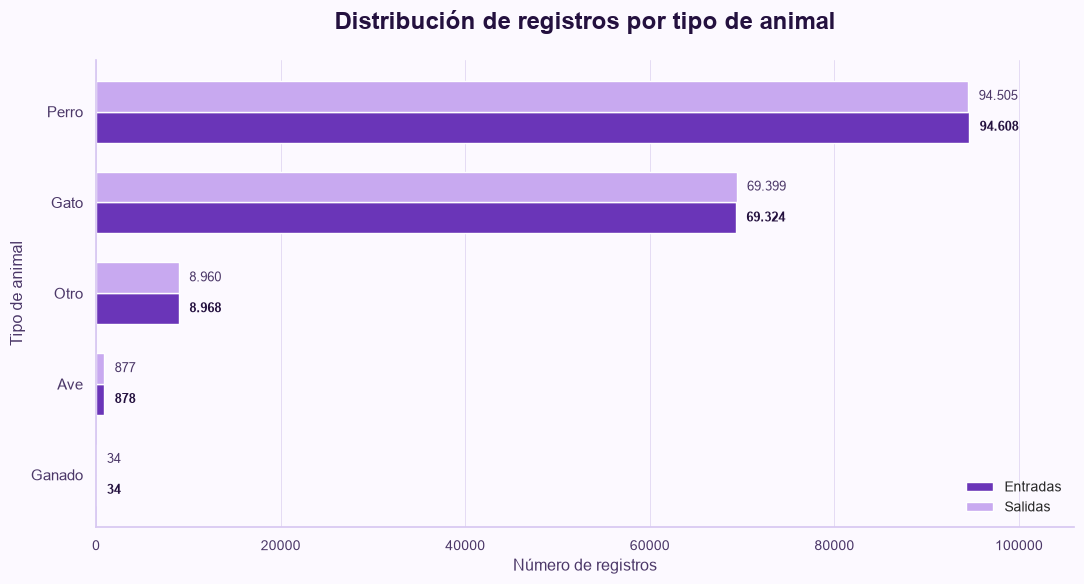

In [12]:
# Distribución visual por tipo de animal

traduccion_animales = {
    "Dog": "Perro",
    "Cat": "Gato",
    "Other": "Otro",
    "Bird": "Ave",
    "Livestock": "Ganado"
}

animal_counts = pd.DataFrame({
    "tipo_animal": intakes_raw["animal_type"].value_counts().index,
    "entradas": intakes_raw["animal_type"].value_counts().values,
    "salidas": outcomes_raw["animal_type"].value_counts().reindex(
        intakes_raw["animal_type"].value_counts().index
    ).values
})

animal_counts["tipo_animal_es"] = animal_counts["tipo_animal"].map(traduccion_animales)
animal_counts = animal_counts.sort_values("entradas", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

bar_height = 0.34
y_pos = np.arange(len(animal_counts))

color_entradas = "#6A35B8"
color_salidas = "#C8A9F0"
title_color = "#24113F"
text_color = "#4B3768"
grid_color = "#D8C8F2"

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.barh(
    y_pos - bar_height / 2,
    animal_counts["entradas"],
    height=bar_height,
    color=color_entradas,
    label="Entradas"
)

ax.barh(
    y_pos + bar_height / 2,
    animal_counts["salidas"],
    height=bar_height,
    color=color_salidas,
    label="Salidas"
)

ax.set_title(
    "Distribución de registros por tipo de animal",
    fontsize=17,
    fontweight="bold",
    color=title_color,
    pad=22
)

ax.set_xlabel("Número de registros", fontsize=11.5, color=text_color)
ax.set_ylabel("Tipo de animal", fontsize=11.5, color=text_color)

ax.set_yticks(y_pos)
ax.set_yticklabels(animal_counts["tipo_animal_es"], fontsize=11, color=text_color)

max_value = animal_counts[["entradas", "salidas"]].max().max()
ax.set_xlim(0, max_value * 1.12)

for i, row in enumerate(animal_counts.itertuples()):
    ax.text(
        row.entradas + max_value * 0.012,
        i - bar_height / 2,
        f"{row.entradas:,.0f}".replace(",", "."),
        va="center",
        fontsize=9.5,
        color=title_color,
        fontweight="bold"
    )

    ax.text(
        row.salidas + max_value * 0.012,
        i + bar_height / 2,
        f"{row.salidas:,.0f}".replace(",", "."),
        va="center",
        fontsize=9.5,
        color=text_color
    )

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(grid_color)
ax.spines["bottom"].set_color(grid_color)

ax.tick_params(axis="x", colors=text_color, labelsize=10)
ax.tick_params(axis="y", colors=text_color)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.grid(axis="y", visible=False)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución visual confirma que los perros constituyen el grupo con mayor volumen de registros tanto en entradas como en salidas. Esta diferencia respecto al resto de tipos de animales respalda la decisión de acotar el análisis a perros, ya que permite trabajar con una muestra amplia y suficiente para construir modelos predictivos de forma robusta.

In [13]:
# Filtrado de registros correspondientes a perros

intakes_dogs = intakes_raw[intakes_raw["animal_type"] == "Dog"].copy()
outcomes_dogs = outcomes_raw[outcomes_raw["animal_type"] == "Dog"].copy()

print("Dimensiones del dataset de entradas de perros:", intakes_dogs.shape)
print("Dimensiones del dataset de salidas de perros:", outcomes_dogs.shape)

Dimensiones del dataset de entradas de perros: (94608, 12)
Dimensiones del dataset de salidas de perros: (94505, 12)


## 5. Revisión de estructura tras el filtrado

Una vez acotado el análisis a los registros correspondientes a perros, se revisa la estructura de los dos datasets de trabajo. Esta revisión permite identificar las variables disponibles, comprobar sus tipos de datos y detectar posibles transformaciones necesarias antes de construir el dataset analítico final.

In [14]:
# Revisión de columnas y tipos de datos

print("Columnas del dataset de entradas de perros:")
display(pd.DataFrame({
    "columna": intakes_dogs.columns,
    "tipo_dato": intakes_dogs.dtypes.astype(str).values
}))

print("\nColumnas del dataset de salidas de perros:")
display(pd.DataFrame({
    "columna": outcomes_dogs.columns,
    "tipo_dato": outcomes_dogs.dtypes.astype(str).values
}))

Columnas del dataset de entradas de perros:


,columna,tipo_dato
0,animal_id,str
1,name,str
2,datetime,str
3,datetime2,str
4,found_location,str
5,intake_type,str
6,intake_condition,str
7,animal_type,str
8,sex_upon_intake,str
9,age_upon_intake,str



Columnas del dataset de salidas de perros:


,columna,tipo_dato
0,animal_id,str
1,date_of_birth,str
2,name,str
3,datetime,str
4,monthyear,str
5,outcome_type,str
6,outcome_subtype,str
7,animal_type,str
8,sex_upon_outcome,str
9,age_upon_outcome,str


### 5.1. Observaciones sobre la estructura de los datos

La revisión de tipos de datos muestra que todas las variables se han cargado inicialmente como tipo `object`. Esto es habitual en una primera lectura de archivos CSV, especialmente cuando las columnas contienen fechas, textos o categorías.

Para el desarrollo del análisis será necesario transformar algunas variables clave:

- Las columnas de fecha deberán convertirse a formato temporal.
- Las variables de edad deberán transformarse a una escala numérica común.
- Las variables categóricas, como raza, color, tipo de entrada y tipo de salida, deberán revisarse y tratarse antes de la modelización.

Esta etapa es relevante porque la calidad de estas transformaciones condicionará directamente la construcción del tiempo de estancia y, posteriormente, la definición de la variable objetivo.

In [15]:
# Revisión inicial de valores nulos

print("Valores nulos en el dataset de entradas de perros:")
display(resumen_nulos(intakes_dogs))

print("\nValores nulos en el dataset de salidas de perros:")
display(resumen_nulos(outcomes_dogs))

Valores nulos en el dataset de entradas de perros:


,variable,nulos,porcentaje_nulos
1,name,14865,15.71
0,animal_id,0,0.00
2,datetime,0,0.00
3,datetime2,0,0.00
4,found_location,0,0.00
5,intake_type,0,0.00
6,intake_condition,0,0.00
7,animal_type,0,0.00
8,sex_upon_intake,1,0.00
9,age_upon_intake,0,0.00



Valores nulos en el dataset de salidas de perros:


,variable,nulos,porcentaje_nulos
6,outcome_subtype,63159,66.83
2,name,14833,15.70
5,outcome_type,30,0.03
0,animal_id,0,0.00
3,datetime,0,0.00
1,date_of_birth,0,0.00
4,monthyear,0,0.00
7,animal_type,0,0.00
8,sex_upon_outcome,1,0.00
9,age_upon_outcome,1,0.00


### 5.2. Observaciones sobre valores nulos

La revisión inicial de valores nulos muestra que las variables clave para construir el dataset analítico presentan una calidad elevada. En el dataset de entradas, únicamente la variable `name` presenta un porcentaje relevante de nulos, con un 15,71 %. Esta variable no será esencial para la modelización, ya que el nombre del animal no aporta información estructural necesaria para calcular el tiempo de estancia.

En el dataset de salidas, la variable con mayor porcentaje de nulos es `outcome_subtype`, con un 66,83 %. Este comportamiento es esperable, ya que el subtipo de salida solo se informa en determinados tipos de resultado. Por tanto, esta variable deberá tratarse con cautela y no se utilizará inicialmente como variable principal del modelo.

Las variables fundamentales para el proyecto, como `animal_id`, `datetime`, `animal_type`, `breed` y `color`, no presentan valores nulos. Esto permite continuar con la preparación de los datos y avanzar hacia la transformación de fechas y la unión de los registros de entrada y salida.

In [16]:
# Conversión de variables de fecha

intakes_dogs["intake_datetime"] = pd.to_datetime(
    intakes_dogs["datetime"],
    errors="coerce"
)

outcomes_dogs["outcome_datetime"] = pd.to_datetime(
    outcomes_dogs["datetime"],
    errors="coerce"
)

print("Rango de fechas en entradas:")
print(intakes_dogs["intake_datetime"].min(), "->", intakes_dogs["intake_datetime"].max())

print("\nRango de fechas en salidas:")
print(outcomes_dogs["outcome_datetime"].min(), "->", outcomes_dogs["outcome_datetime"].max())

Rango de fechas en entradas:
2013-10-01 07:51:00 -> 2025-05-04 22:55:00

Rango de fechas en salidas:
2014-07-11 00:00:00-05:00 -> 2025-04-19 00:00:00-05:00


### 5.3. Conversión inicial de fechas

Se realiza una primera conversión de las variables temporales a formato fecha con el objetivo de revisar los rangos disponibles y preparar la posterior unión de entradas y salidas.

En esta primera revisión se observa que el dataset de entradas cubre el periodo comprendido entre octubre de 2013 y mayo de 2025, mientras que el dataset de salidas muestra inicialmente un rango comprendido entre julio de 2014 y abril de 2025. Esta diferencia sugiere la necesidad de revisar con mayor detalle el formato de las fechas de salida antes de calcular el tiempo de estancia.

Por este motivo, en los apartados posteriores se realizará una corrección específica del formato temporal de las salidas, asegurando que la fecha de salida sea posterior a la fecha de entrada y seleccionando, cuando existan varias salidas posibles para un mismo animal, la salida temporalmente más cercana.

In [17]:
# Selección de columnas relevantes

intake_cols = [
    "animal_id",
    "name",
    "animal_type",
    "intake_datetime",
    "found_location",
    "intake_type",
    "intake_condition",
    "sex_upon_intake",
    "age_upon_intake",
    "breed",
    "color"
]

outcome_cols = [
    "animal_id",
    "name",
    "animal_type",
    "outcome_datetime",
    "outcome_type",
    "outcome_subtype",
    "sex_upon_outcome",
    "age_upon_outcome",
    "breed",
    "color"
]

intakes_dogs_sel = intakes_dogs[intake_cols].copy()
outcomes_dogs_sel = outcomes_dogs[outcome_cols].copy()

print("Dimensiones de entradas seleccionadas:", intakes_dogs_sel.shape)
print("Dimensiones de salidas seleccionadas:", outcomes_dogs_sel.shape)

Dimensiones de entradas seleccionadas: (94608, 11)
Dimensiones de salidas seleccionadas: (94505, 10)


### 5.4. Selección de variables relevantes

Tras la revisión inicial de la estructura de los datos, se han seleccionado las variables necesarias para reconstruir el recorrido de cada perro dentro del refugio.

En el dataset de entradas se conservan variables relacionadas con la identificación del animal, la fecha de entrada, la localización donde fue encontrado, el tipo y la condición de entrada, así como características básicas del perro como sexo, edad, raza y color.

En el dataset de salidas se conservan variables equivalentes de identificación y características del animal, junto con la fecha de salida y el tipo de resultado obtenido. Esta selección permite reducir el ruido del dataset original y centrar el análisis en las variables necesarias para calcular el tiempo de estancia y construir posteriormente la variable objetivo.

In [18]:
# Renombrado de variables antes de la unión

intakes_dogs_sel = intakes_dogs_sel.rename(columns={
    "name": "name_intake",
    "animal_type": "animal_type_intake",
    "breed": "breed_intake",
    "color": "color_intake"
})

outcomes_dogs_sel = outcomes_dogs_sel.rename(columns={
    "name": "name_outcome",
    "animal_type": "animal_type_outcome",
    "breed": "breed_outcome",
    "color": "color_outcome"
})

print("Columnas de entradas seleccionadas:")
print(intakes_dogs_sel.columns.tolist())

print("\nColumnas de salidas seleccionadas:")
print(outcomes_dogs_sel.columns.tolist())

Columnas de entradas seleccionadas:
['animal_id', 'name_intake', 'animal_type_intake', 'intake_datetime', 'found_location', 'intake_type', 'intake_condition', 'sex_upon_intake', 'age_upon_intake', 'breed_intake', 'color_intake']

Columnas de salidas seleccionadas:
['animal_id', 'name_outcome', 'animal_type_outcome', 'outcome_datetime', 'outcome_type', 'outcome_subtype', 'sex_upon_outcome', 'age_upon_outcome', 'breed_outcome', 'color_outcome']


## 6. Unión inicial de entradas y salidas

El siguiente paso consiste en unir los registros de entrada y salida a partir del identificador del animal (`animal_id`). Esta primera unión permite generar todas las combinaciones posibles entre entradas y salidas de un mismo perro.

Dado que un mismo animal puede haber pasado por el refugio más de una vez, esta unión inicial deberá depurarse posteriormente. Para construir correctamente el tiempo de estancia, solo se conservarán aquellas combinaciones en las que la salida sea posterior a la entrada y, en caso de existir varias salidas posibles para una misma entrada, se seleccionará la más cercana en el tiempo.

In [19]:
# Unión inicial por identificador del animal

dogs_merged_initial = pd.merge(
    intakes_dogs_sel,
    outcomes_dogs_sel,
    on="animal_id",
    how="inner"
)

print("Dimensiones del dataset tras la unión inicial:", dogs_merged_initial.shape)

display(dogs_merged_initial.head())

Dimensiones del dataset tras la unión inicial: (135472, 20)


,animal_id,name_intake,animal_type_intake,intake_datetime,found_location,intake_type,intake_condition,sex_upon_intake,age_upon_intake,breed_intake,color_intake,name_outcome,animal_type_outcome,outcome_datetime,outcome_type,outcome_subtype,sex_upon_outcome,age_upon_outcome,breed_outcome,color_outcome
0,A521520,Nina,Dog,2013-10-01 07:51:00,Norht Ec in Austin (TX),Stray,Normal,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan,Nina,Dog,NaT,Return to Owner,NaN,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664233,Stevie,Dog,2013-10-01 08:53:00,7405 Springtime in Austin (TX),Stray,Injured,Intact Female,3 years,Pit Bull Mix,Blue/White,Stevie,Dog,NaT,Euthanasia,Suffering,Intact Female,3 years,Pit Bull Mix,Blue/White
2,A664234,NaN,Dog,2013-10-01 10:37:00,5400 Jimmy Clay in Austin (TX),Stray,Injured,Intact Male,8 years,Border Collie Mix,Black/White,NaN,Dog,NaT,Euthanasia,Suffering,Intact Male,8 years,Border Collie Mix,Black/White
3,A664257,Pippin,Dog,2013-10-01 11:01:00,Burleson in Travis (TX),Stray,Normal,Intact Female,4 years,Podengo Pequeno Mix,Black,Pippin,Dog,NaT,Adoption,Foster,Spayed Female,4 years,Podengo Pequeno Mix,Black
4,A664266,NaN,Dog,2013-10-01 11:09:00,Payton And 183 in Austin (TX),Stray,Normal,Intact Female,1 year,Chihuahua Shorthair Mix,Buff,NaN,Dog,NaT,Transfer,Partner,Intact Female,1 year,Chihuahua Shorthair Mix,Buff


### 6.1. Comprobación de la unión inicial

La unión inicial por `animal_id` genera 135.472 combinaciones entre entradas y salidas de perros. Este número es superior al número de registros individuales de entrada porque un mismo animal puede aparecer varias veces en el refugio y, por tanto, puede tener múltiples registros asociados.

Antes de calcular el tiempo de estancia, es necesario comprobar que las fechas de entrada y salida se han convertido correctamente. En una primera revisión visual se observa que algunas fechas de salida aparecen como `NaT`, por lo que se analiza la magnitud de este problema antes de continuar.

In [20]:
# Comprobación de fechas no convertidas

print("Valores sin fecha de entrada:")
print(dogs_merged_initial["intake_datetime"].isna().sum())

print("\nValores sin fecha de salida:")
print(dogs_merged_initial["outcome_datetime"].isna().sum())

print("\nPorcentaje de valores sin fecha de salida:")
print(round(dogs_merged_initial["outcome_datetime"].isna().mean() * 100, 2), "%")

Valores sin fecha de entrada:
0

Valores sin fecha de salida:
133139

Porcentaje de valores sin fecha de salida:
98.28 %


### 6.2. Corrección del formato de fechas de salida

La comprobación anterior muestra que la mayoría de las fechas de salida no se han convertido correctamente. Esto se debe a que el dataset de salidas mezcla dos formatos de fecha: una parte de los registros, concentrada principalmente en los primeros años recogidos por el dataset, incluye una anotación explícita de huso horario (por ejemplo, un sufijo `-05:00`), mientras que el resto de registros no incluye ninguna información de huso horario, igual que ocurre en todo el dataset de entradas.

Para corregir la conversión sin perder registros es necesario admitir ambos formatos a la vez (`format="mixed"`). Sin embargo, activar además `utc=True` no resuelve correctamente la mezcla: esa opción convierte a UTC únicamente los registros que sí incluyen huso horario, desplazando su hora varias unidades, mientras que los registros sin huso horario se interpretan como si ya estuvieran en UTC y no se desplazan. El resultado sería una variable `outcome_datetime` con dos referencias horarias distintas conviviendo en la misma columna, y sistemáticamente descoordinada frente a `intake_datetime`, que permanece siempre en hora local sin ninguna conversión.

Por este motivo, la corrección adoptada descarta la anotación de huso horario cuando existe, conservando el valor de reloj tal y como aparece en la fuente. De esta forma, `outcome_datetime` queda expresada bajo la misma referencia horaria local que `intake_datetime` y que el resto de registros de salida, evitando introducir un desplazamiento artificial en el cálculo posterior del tiempo de estancia.

In [21]:
# Corrección de la conversión de fechas

intakes_dogs["intake_datetime"] = pd.to_datetime(
    intakes_dogs["datetime"],
    errors="coerce",
    format="mixed"
)

# Se descarta la anotación de huso horario (si existe) sin aplicar ninguna
# conversión de hora, de forma que outcome_datetime quede expresada en la
# misma referencia horaria local que intake_datetime.
outcomes_datetime_sin_huso = outcomes_dogs["datetime"].astype(str).str.replace(
    r"[+-]\d{2}:\d{2}$", "", regex=True
)

outcomes_dogs["outcome_datetime"] = pd.to_datetime(
    outcomes_datetime_sin_huso,
    errors="coerce",
    format="mixed"
)

registros_con_huso_horario = outcomes_dogs["datetime"].astype(str).str.contains(
    r"[+-]\d{2}:\d{2}$", regex=True
).sum()

print("Registros de salida con anotación explícita de huso horario:", registros_con_huso_horario)

print("\nValores sin fecha de entrada tras la corrección:")
print(intakes_dogs["intake_datetime"].isna().sum())

print("\nValores sin fecha de salida tras la corrección:")
print(outcomes_dogs["outcome_datetime"].isna().sum())

print("\nRango de fechas en entradas:")
print(intakes_dogs["intake_datetime"].min(), "->", intakes_dogs["intake_datetime"].max())

print("\nRango de fechas en salidas:")
print(outcomes_dogs["outcome_datetime"].min(), "->", outcomes_dogs["outcome_datetime"].max())

Registros de salida con anotación explícita de huso horario: 1770

Valores sin fecha de entrada tras la corrección:
0

Valores sin fecha de salida tras la corrección:
0

Rango de fechas en entradas:
2013-10-01 07:51:00 -> 2025-05-04 22:55:00

Rango de fechas en salidas:
2013-10-01 09:31:00 -> 2025-05-04 18:46:00


### 6.3. Reconstrucción de los datasets seleccionados

Una vez corregida la conversión de fechas, se reconstruyen los subconjuntos de entrada y salida que se utilizarán para la unión. Este paso asegura que las variables temporales incorporadas a los datasets seleccionados contienen fechas válidas y comparables entre sí.

In [22]:
# Reconstrucción de datasets seleccionados tras corregir fechas

intakes_dogs_sel = intakes_dogs[intake_cols].copy()
outcomes_dogs_sel = outcomes_dogs[outcome_cols].copy()

intakes_dogs_sel = intakes_dogs_sel.rename(columns={
    "name": "name_intake",
    "animal_type": "animal_type_intake",
    "breed": "breed_intake",
    "color": "color_intake"
})

outcomes_dogs_sel = outcomes_dogs_sel.rename(columns={
    "name": "name_outcome",
    "animal_type": "animal_type_outcome",
    "breed": "breed_outcome",
    "color": "color_outcome"
})

dogs_merged_initial = pd.merge(
    intakes_dogs_sel,
    outcomes_dogs_sel,
    on="animal_id",
    how="inner"
)

print("Dimensiones del dataset tras reconstruir la unión inicial:", dogs_merged_initial.shape)
print("Valores sin fecha de salida:", dogs_merged_initial["outcome_datetime"].isna().sum())

display(dogs_merged_initial.head())

Dimensiones del dataset tras reconstruir la unión inicial: (135472, 20)
Valores sin fecha de salida: 0


,animal_id,name_intake,animal_type_intake,intake_datetime,found_location,intake_type,intake_condition,sex_upon_intake,age_upon_intake,breed_intake,color_intake,name_outcome,animal_type_outcome,outcome_datetime,outcome_type,outcome_subtype,sex_upon_outcome,age_upon_outcome,breed_outcome,color_outcome
0,A521520,Nina,Dog,2013-10-01 07:51:00,Norht Ec in Austin (TX),Stray,Normal,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan,Nina,Dog,2013-10-01 15:39:00,Return to Owner,NaN,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664233,Stevie,Dog,2013-10-01 08:53:00,7405 Springtime in Austin (TX),Stray,Injured,Intact Female,3 years,Pit Bull Mix,Blue/White,Stevie,Dog,2013-10-01 15:33:00,Euthanasia,Suffering,Intact Female,3 years,Pit Bull Mix,Blue/White
2,A664234,NaN,Dog,2013-10-01 10:37:00,5400 Jimmy Clay in Austin (TX),Stray,Injured,Intact Male,8 years,Border Collie Mix,Black/White,NaN,Dog,2013-10-01 19:09:42,Euthanasia,Suffering,Intact Male,8 years,Border Collie Mix,Black/White
3,A664257,Pippin,Dog,2013-10-01 11:01:00,Burleson in Travis (TX),Stray,Normal,Intact Female,4 years,Podengo Pequeno Mix,Black,Pippin,Dog,2013-10-24 13:31:00,Adoption,Foster,Spayed Female,4 years,Podengo Pequeno Mix,Black
4,A664266,NaN,Dog,2013-10-01 11:09:00,Payton And 183 in Austin (TX),Stray,Normal,Intact Female,1 year,Chihuahua Shorthair Mix,Buff,NaN,Dog,2013-10-05 15:06:00,Transfer,Partner,Intact Female,1 year,Chihuahua Shorthair Mix,Buff


### 6.4. Cálculo inicial del tiempo de estancia

A partir de las fechas de entrada y salida se calcula el número de días transcurridos entre ambos eventos. Esta variable, denominada `stay_days`, será una de las variables centrales del proyecto, ya que permitirá identificar perros con estancias prolongadas y construir posteriormente la variable objetivo.

En esta primera aproximación pueden aparecer combinaciones no válidas, especialmente cuando un mismo perro tiene múltiples entradas y salidas registradas. Por ello, tras calcular el tiempo de estancia, se eliminarán las combinaciones en las que la salida sea anterior a la entrada.

In [23]:
# Cálculo inicial del tiempo de estancia

dogs_merged_initial["stay_days"] = (
    dogs_merged_initial["outcome_datetime"] - dogs_merged_initial["intake_datetime"]
).dt.total_seconds() / (60 * 60 * 24)

print("Resumen inicial del tiempo de estancia:")
display(dogs_merged_initial["stay_days"].describe())

print("\nNúmero de combinaciones con estancia negativa:")
print((dogs_merged_initial["stay_days"] < 0).sum())

Resumen inicial del tiempo de estancia:


count    135472.000000
mean         20.518177
std         355.804190
min       -3880.437500
25%           0.986806
50%           5.954167
75%          28.058507
max        3883.748611
Name: stay_days, dtype: float64


Número de combinaciones con estancia negativa:
21014


### 6.5. Depuración de combinaciones temporales no válidas

La unión inicial genera combinaciones entre todas las entradas y salidas asociadas a un mismo `animal_id`. Como consecuencia, aparecen casos en los que la fecha de salida es anterior a la fecha de entrada, lo que da lugar a valores negativos en `stay_days`.

Estas combinaciones no representan estancias reales en el refugio y deben eliminarse antes de construir el dataset analítico final. Tras este filtrado, se conservarán únicamente las combinaciones en las que la salida sea posterior o igual a la entrada.

In [24]:
# Eliminación de combinaciones con estancia negativa

dogs_merged_valid = dogs_merged_initial[
    dogs_merged_initial["stay_days"] >= 0
].copy()

print("Registros antes de eliminar estancias negativas:", dogs_merged_initial.shape[0])
print("Registros después de eliminar estancias negativas:", dogs_merged_valid.shape[0])
print("Registros eliminados:", dogs_merged_initial.shape[0] - dogs_merged_valid.shape[0])

print("\nResumen del tiempo de estancia tras eliminar valores negativos:")
display(dogs_merged_valid["stay_days"].describe())

Registros antes de eliminar estancias negativas: 135472
Registros después de eliminar estancias negativas: 114458
Registros eliminados: 21014

Resumen del tiempo de estancia tras eliminar valores negativos:


count    114458.000000
mean         88.381432
std         267.486518
min           0.000000
25%           3.877083
50%           8.129167
75%          40.085938
max        3883.748611
Name: stay_days, dtype: float64

### 6.6. Emparejamiento único entre entradas y salidas

Tras eliminar las combinaciones con fechas incoherentes, todavía pueden existir varias entradas y varias salidas asociadas a un mismo perro, ya que algunos animales aparecen varias veces en el refugio a lo largo del periodo analizado. Emparejar simplemente cada entrada con su salida posterior más cercana, sin ninguna restricción adicional, puede hacer que una misma salida quede asociada a más de una entrada cuando dos entradas de un mismo perro comparten la salida disponible más próxima en el tiempo.

Para evitar esta reutilización, el emparejamiento se realiza directamente sobre las secuencias de entradas y salidas de cada perro (`intakes_dogs_sel` y `outcomes_dogs_sel`), ordenadas cronológicamente, aplicando el siguiente criterio: se recorren los eventos de cada animal en orden temporal y cada salida se empareja con la entrada más antigua que todavía esté pendiente de salida. Este criterio equivale a asociar cada entrada con la primera salida posterior que no haya sido utilizada previamente, y garantiza por construcción que ninguna entrada ni ninguna salida se emplea en más de una estancia, y que ninguna salida puede quedar emparejada con una entrada posterior a ella.

Antes de aplicar este criterio se ha detectado, además, que las fuentes originales contienen un número reducido de registros de entrada y de salida completamente duplicados (mismo `animal_id`, misma fecha y el resto de columnas idénticas), así como algún caso adicional en el que dos registros comparten `animal_id` y fecha exacta pero difieren en algún detalle menor (por ejemplo, una variación de formato en la ubicación). Estos registros no representan eventos distintos, sino duplicados de un mismo evento en la fuente de datos, por lo que se eliminan (conservando un único registro por combinación de `animal_id` y fecha) antes de construir el dataset base; en caso contrario, dos eventos idénticos o casi idénticos podrían emparejarse con salidas distintas y aparecer como si fueran dos estancias diferentes.

In [25]:
# Emparejamiento único de entradas y salidas por perro

def emparejar_entradas_salidas(instantes_entrada, instantes_salida):
    """
    A partir de los instantes de entrada y salida de un mismo animal_id,
    devuelve la lista de pares (posición de entrada, posición de salida)
    que resulta de recorrer cronológicamente todos los eventos y emparejar
    cada salida con la entrada más antigua todavía sin salida asociada.

    Este criterio garantiza que cada entrada y cada salida se utilizan como
    máximo una vez, y que ninguna salida se empareja con una entrada
    posterior a ella (una salida solo puede emparejarse con entradas ya
    procesadas en el recorrido cronológico).
    """
    eventos = sorted(
        [(instante, 0, posicion) for posicion, instante in enumerate(instantes_entrada)] +
        [(instante, 1, posicion) for posicion, instante in enumerate(instantes_salida)]
    )

    cola_entradas_pendientes = []
    pares_entrada_salida = []

    for _, tipo_evento, posicion in eventos:
        if tipo_evento == 0:
            cola_entradas_pendientes.append(posicion)
        elif cola_entradas_pendientes:
            posicion_entrada = cola_entradas_pendientes.pop(0)
            pares_entrada_salida.append((posicion_entrada, posicion))

    return pares_entrada_salida


# Se eliminan registros sin fecha válida y duplicados exactos de la fuente
# original (mismo evento registrado más de una vez, ver apartado anterior),
# conservando un único registro por combinación de animal_id y fecha.
intakes_dogs_sel_validas = (
    intakes_dogs_sel
    .dropna(subset=["intake_datetime"])
    .drop_duplicates()
    .drop_duplicates(subset=["animal_id", "intake_datetime"], keep="first")
)

outcomes_dogs_sel_validas = (
    outcomes_dogs_sel
    .dropna(subset=["outcome_datetime"])
    .drop_duplicates()
    .drop_duplicates(subset=["animal_id", "outcome_datetime"], keep="first")
)

print("Entradas de perros antes de eliminar duplicados exactos:", intakes_dogs_sel.dropna(subset=["intake_datetime"]).shape[0])
print("Entradas de perros tras eliminar duplicados exactos:", intakes_dogs_sel_validas.shape[0])
print("Salidas de perros antes de eliminar duplicados exactos:", outcomes_dogs_sel.dropna(subset=["outcome_datetime"]).shape[0])
print("Salidas de perros tras eliminar duplicados exactos:", outcomes_dogs_sel_validas.shape[0])

outcomes_por_animal = {
    animal_id: grupo.reset_index(drop=True)
    for animal_id, grupo in outcomes_dogs_sel_validas.groupby("animal_id", sort=False)
}

filas_entrada_emparejadas = []
filas_salida_emparejadas = []

for animal_id, intakes_animal in intakes_dogs_sel_validas.groupby("animal_id", sort=False):
    outcomes_animal = outcomes_por_animal.get(animal_id)

    if outcomes_animal is None:
        continue

    intakes_animal = intakes_animal.reset_index(drop=True)

    pares = emparejar_entradas_salidas(
        intakes_animal["intake_datetime"].to_numpy(),
        outcomes_animal["outcome_datetime"].to_numpy()
    )

    for posicion_entrada, posicion_salida in pares:
        filas_entrada_emparejadas.append(intakes_animal.iloc[posicion_entrada])
        filas_salida_emparejadas.append(outcomes_animal.iloc[posicion_salida])

dogs_base_entradas = pd.DataFrame(filas_entrada_emparejadas).reset_index(drop=True)
dogs_base_salidas = (
    pd.DataFrame(filas_salida_emparejadas)
    .reset_index(drop=True)
    .drop(columns="animal_id")
)

dogs_base = pd.concat([dogs_base_entradas, dogs_base_salidas], axis=1)

dogs_base["stay_days"] = (
    dogs_base["outcome_datetime"] - dogs_base["intake_datetime"]
).dt.total_seconds() / (60 * 60 * 24)

print("Registros en el dataset base tras el emparejamiento único:", dogs_base.shape[0])
print("Número de perros únicos:", dogs_base["animal_id"].nunique())

print("\nResumen del tiempo de estancia en el dataset base:")
display(dogs_base["stay_days"].describe())

display(dogs_base.head())

Entradas de perros antes de eliminar duplicados exactos: 94608
Entradas de perros tras eliminar duplicados exactos: 94586
Salidas de perros antes de eliminar duplicados exactos: 94505
Salidas de perros tras eliminar duplicados exactos: 94492
Registros en el dataset base tras el emparejamiento único: 93803
Número de perros únicos: 79555

Resumen del tiempo de estancia en el dataset base:


count    93803.000000
mean        21.029849
std         53.697420
min          0.000000
25%          2.791319
50%          5.997222
75%         15.258681
max       1912.938194
Name: stay_days, dtype: float64

,animal_id,name_intake,animal_type_intake,intake_datetime,found_location,intake_type,intake_condition,sex_upon_intake,age_upon_intake,breed_intake,color_intake,name_outcome,animal_type_outcome,outcome_datetime,outcome_type,outcome_subtype,sex_upon_outcome,age_upon_outcome,breed_outcome,color_outcome,stay_days
0,A521520,Nina,Dog,2013-10-01 07:51:00,Norht Ec in Austin (TX),Stray,Normal,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan,Nina,Dog,2013-10-01 15:39:00,Return to Owner,NaN,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan,0.325000
1,A664233,Stevie,Dog,2013-10-01 08:53:00,7405 Springtime in Austin (TX),Stray,Injured,Intact Female,3 years,Pit Bull Mix,Blue/White,Stevie,Dog,2013-10-01 15:33:00,Euthanasia,Suffering,Intact Female,3 years,Pit Bull Mix,Blue/White,0.277778
2,A664234,NaN,Dog,2013-10-01 10:37:00,5400 Jimmy Clay in Austin (TX),Stray,Injured,Intact Male,8 years,Border Collie Mix,Black/White,NaN,Dog,2013-10-01 19:09:42,Euthanasia,Suffering,Intact Male,8 years,Border Collie Mix,Black/White,0.356042
3,A664257,Pippin,Dog,2013-10-01 11:01:00,Burleson in Travis (TX),Stray,Normal,Intact Female,4 years,Podengo Pequeno Mix,Black,Pippin,Dog,2013-10-24 13:31:00,Adoption,Foster,Spayed Female,4 years,Podengo Pequeno Mix,Black,23.104167
4,A664266,NaN,Dog,2013-10-01 11:09:00,Payton And 183 in Austin (TX),Stray,Normal,Intact Female,1 year,Chihuahua Shorthair Mix,Buff,NaN,Dog,2013-10-05 15:06:00,Transfer,Partner,Intact Female,1 year,Chihuahua Shorthair Mix,Buff,4.164583


### 6.7. Dataset base de estancias

Tras aplicar el criterio de emparejamiento único descrito en el apartado 6.6, se obtiene el dataset base de estancias, con un registro por cada entrada emparejada correctamente con su salida correspondiente (las dimensiones exactas se muestran en la celda anterior).

La distribución del tiempo de estancia muestra una mediana claramente inferior a la media, lo que ya anticipa una distribución asimétrica: una parte importante de los perros permanece poco tiempo en el refugio, pero la cola de valores máximos se extiende considerablemente más allá de la mediana.

Esta asimetría confirma la relevancia del problema abordado en el proyecto: aunque muchos perros tienen una salida rápida, existe un subconjunto de animales que permanece durante periodos significativamente más largos y que podría beneficiarse de estrategias específicas de visibilidad o intervención.

### Nota metodológica sobre la unión de entradas y salidas

La unión entre los registros de entrada y salida se realiza con especial cuidado, ya que un mismo perro puede aparecer varias veces en el refugio a lo largo del periodo analizado.

Por este motivo, no basta con unir únicamente por `animal_id`: es necesario asegurar además que la salida asociada a cada entrada sea posterior a la fecha de entrada y que ninguna entrada ni ninguna salida se reutilice en más de una estancia.

El criterio de emparejamiento descrito en el apartado 6.6 asegura, por construcción, que cada entrada y cada salida se utilizan como máximo una vez: al procesar los eventos de cada perro en orden cronológico y emparejar cada salida con la entrada más antigua todavía pendiente, ninguna salida puede quedar asociada simultáneamente a dos entradas distintas, y ninguna salida puede emparejarse con una entrada posterior a ella. La auditoría del apartado siguiente verifica explícitamente esta propiedad sobre el dataset base resultante.

In [26]:
# Auditoría del emparejamiento entre entradas y salidas

total_entradas_perros = intakes_dogs_sel_validas.shape[0]
total_salidas_perros = outcomes_dogs_sel_validas.shape[0]
total_estancias_validas = dogs_base.shape[0]

entradas_emparejadas = set(zip(dogs_base["animal_id"], dogs_base["intake_datetime"]))
salidas_emparejadas = set(zip(dogs_base["animal_id"], dogs_base["outcome_datetime"]))

entradas_sin_salida_asociada = total_entradas_perros - len(entradas_emparejadas)
salidas_no_utilizadas = total_salidas_perros - len(salidas_emparejadas)

estancias_con_duracion_negativa = (dogs_base["stay_days"] < 0).sum()

entradas_utilizadas_mas_de_una_vez = dogs_base.duplicated(subset=["animal_id", "intake_datetime"]).sum()
salidas_utilizadas_mas_de_una_vez = dogs_base.duplicated(subset=["animal_id", "outcome_datetime"]).sum()

resumen_auditoria_emparejamiento = pd.DataFrame({
    "indicador": [
        "Entradas de perros disponibles",
        "Salidas de perros disponibles",
        "Estancias válidas construidas (dataset base)",
        "Entradas sin salida posterior disponible",
        "Salidas no utilizadas en ninguna estancia",
        "Estancias con duración negativa",
        "Entradas utilizadas en más de una estancia",
        "Salidas utilizadas en más de una estancia"
    ],
    "valor": [
        total_entradas_perros,
        total_salidas_perros,
        total_estancias_validas,
        entradas_sin_salida_asociada,
        salidas_no_utilizadas,
        estancias_con_duracion_negativa,
        entradas_utilizadas_mas_de_una_vez,
        salidas_utilizadas_mas_de_una_vez
    ]
})

display(resumen_auditoria_emparejamiento)

assert entradas_utilizadas_mas_de_una_vez == 0, "Una misma entrada se ha utilizado en más de una estancia."
assert salidas_utilizadas_mas_de_una_vez == 0, "Una misma salida se ha utilizado en más de una estancia."
assert estancias_con_duracion_negativa == 0, "Existen estancias con duración negativa en el dataset base."

print("\nEl emparejamiento garantiza que cada entrada y cada salida se utilizan como máximo una vez.")

,indicador,valor
0,Entradas de perros disponibles,94586
1,Salidas de perros disponibles,94492
2,Estancias válidas construidas (dataset base),93803
3,Entradas sin salida posterior disponible,783
4,Salidas no utilizadas en ninguna estancia,689
5,Estancias con duración negativa,0
6,Entradas utilizadas en más de una estancia,0
7,Salidas utilizadas en más de una estancia,0



El emparejamiento garantiza que cada entrada y cada salida se utilizan como máximo una vez.


La auditoría confirma que el criterio de emparejamiento cronológico garantiza, por construcción, que ninguna entrada ni ninguna salida se utiliza en más de una estancia: el número de entradas y de salidas duplicadas en el dataset base es igual a cero en ambos casos, y no existen estancias con duración negativa.

Las entradas sin una salida posterior disponible quedan excluidas del dataset base y, por tanto, no reciben ningún valor de la variable objetivo: no se asume que se trate de casos de larga estancia, sino de estancias cuyo desenlace todavía no puede determinarse a partir de los datos disponibles (por ejemplo, animales que continúan en el refugio en el momento de la extracción). Las salidas no utilizadas por ninguna entrada corresponden en buena parte a animales cuya entrada no aparece en el periodo cubierto por el dataset, es decir, estancias que ya estaban en curso al comienzo de la ventana temporal analizada.

Este resultado sustituye la aproximación utilizada anteriormente, que emparejaba cada entrada con la salida posterior más cercana sin garantizar unicidad. La corrección introducida en este apartado asegura que cada fila del dataset base representa una estancia completa y no compartida con ninguna otra entrada o salida del mismo perro.

In [27]:
# Creación de variable de estancia en días completos

dogs_base["stay_days_rounded"] = np.ceil(dogs_base["stay_days"]).astype(int)

display(dogs_base[[
    "animal_id",
    "intake_datetime",
    "outcome_datetime",
    "stay_days",
    "stay_days_rounded"
]].head())

print("Resumen de estancia en días completos:")
display(dogs_base["stay_days_rounded"].describe())

,animal_id,intake_datetime,outcome_datetime,stay_days,stay_days_rounded
0,A521520,2013-10-01 07:51:00,2013-10-01 15:39:00,0.325000,1
1,A664233,2013-10-01 08:53:00,2013-10-01 15:33:00,0.277778,1
2,A664234,2013-10-01 10:37:00,2013-10-01 19:09:42,0.356042,1
3,A664257,2013-10-01 11:01:00,2013-10-24 13:31:00,23.104167,24
4,A664266,2013-10-01 11:09:00,2013-10-05 15:06:00,4.164583,5


Resumen de estancia en días completos:


count    93803.000000
mean        21.630129
std         53.671792
min          0.000000
25%          3.000000
50%          6.000000
75%         16.000000
max       1913.000000
Name: stay_days_rounded, dtype: float64

### 6.8. Variable de estancia en días completos

Para facilitar la interpretación de los resultados, se ha creado la variable `stay_days_rounded`, que representa el tiempo de estancia redondeado a días completos.

La distribución confirma que la mayoría de perros presenta estancias relativamente cortas, con una mediana y un tercer cuartil claramente por debajo del valor máximo observado. La diferencia entre la media y la mediana, junto con la existencia de valores máximos muy elevados, evidencia una distribución claramente asimétrica.

Este comportamiento justifica el planteamiento del proyecto, ya que permite diferenciar entre perros con salida rápida y perros con estancias inusualmente prolongadas.

In [28]:
# Creación preliminar de variables de larga estancia

dogs_base["long_stay_30"] = (dogs_base["stay_days_rounded"] > 30).astype(int)
dogs_base["long_stay_60"] = (dogs_base["stay_days_rounded"] > 60).astype(int)
dogs_base["long_stay_90"] = (dogs_base["stay_days_rounded"] > 90).astype(int)

long_stay_summary = pd.DataFrame({
    "umbral": ["Más de 30 días", "Más de 60 días", "Más de 90 días"],
    "registros_larga_estancia": [
        dogs_base["long_stay_30"].sum(),
        dogs_base["long_stay_60"].sum(),
        dogs_base["long_stay_90"].sum()
    ],
    "porcentaje_larga_estancia": [
        dogs_base["long_stay_30"].mean() * 100,
        dogs_base["long_stay_60"].mean() * 100,
        dogs_base["long_stay_90"].mean() * 100
    ]
})

long_stay_summary["porcentaje_larga_estancia"] = long_stay_summary["porcentaje_larga_estancia"].round(2)

display(long_stay_summary)

,umbral,registros_larga_estancia,porcentaje_larga_estancia
0,Más de 30 días,15089,16.09
1,Más de 60 días,7677,8.18
2,Más de 90 días,4553,4.85


### 6.9. Distribución del tiempo de estancia

Una vez calculada la variable de estancia en días completos, resulta conveniente analizar su distribución visual. Esta representación permite comprobar si la mayor parte de los perros presenta estancias cortas o, por el contrario, si existe una proporción relevante de casos con permanencias prolongadas.

Dado que el dataset contiene algunos valores extremos, se representa en primer lugar la distribución del tiempo de estancia acotada a 200 días. Esta limitación facilita la interpretación de la parte central de la distribución, donde se concentra la mayoría de observaciones, sin que los casos muy extremos distorsionen la visualización.

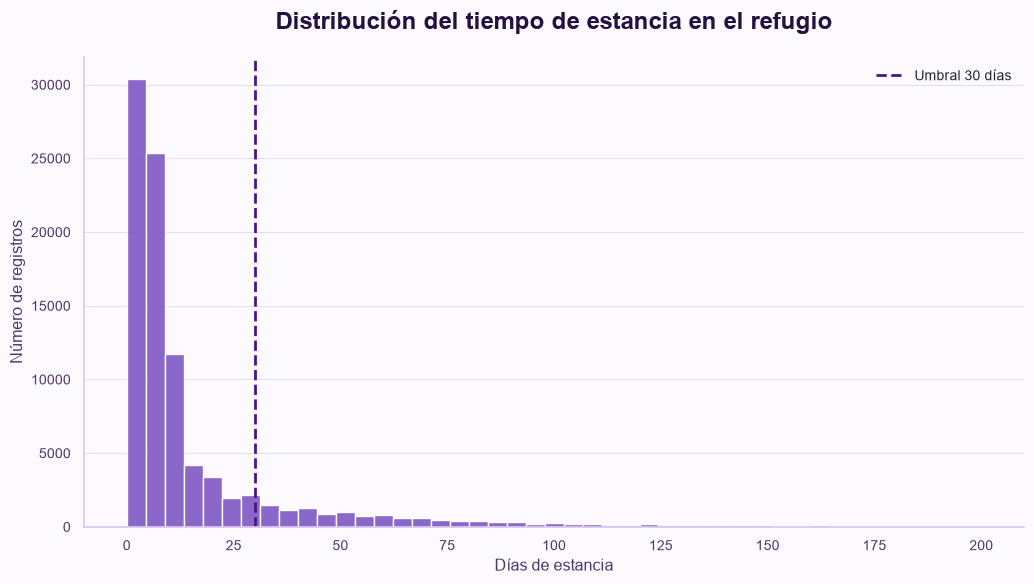

In [29]:
# Distribución del tiempo de estancia

stay_days_plot = dogs_base[dogs_base["stay_days_rounded"] <= 200].copy()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

sns.histplot(
    data=stay_days_plot,
    x="stay_days_rounded",
    bins=45,
    color="#7E57C2",
    edgecolor="white",
    alpha=0.9,
    ax=ax
)

ax.axvline(
    x=30,
    color="#4A148C",
    linestyle="--",
    linewidth=2,
    label="Umbral 30 días"
)

ax.set_title(
    "Distribución del tiempo de estancia en el refugio",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Días de estancia", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Número de registros", fontsize=11.5, color="#4B3768")

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(False)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución del tiempo de estancia muestra una clara concentración de registros en los primeros días tras la entrada al refugio. Esto indica que una parte importante de los perros obtiene una salida relativamente rápida.

Sin embargo, la distribución presenta una asimetría positiva evidente, con una cola prolongada hacia valores altos de estancia. Este comportamiento confirma que, aunque la mayoría de los perros permanece poco tiempo en el refugio, existe un subconjunto de animales con estancias significativamente más largas.

La línea vertical situada en 30 días permite visualizar el umbral preliminar que se utilizará en el análisis posterior para identificar perros con riesgo de larga estancia.

### 6.10. Definición preliminar de larga estancia

Se han construido tres variables preliminares de larga estancia utilizando distintos umbrales temporales: más de 30 días, más de 60 días y más de 90 días.

El umbral de 30 días es el que ofrece un mejor equilibrio entre relevancia práctica y volumen suficiente de casos positivos para la modelización, tal como muestra la tabla del apartado anterior. Los umbrales de 60 y 90 días representan situaciones más prolongadas, pero reducen notablemente el número de casos positivos, lo que podría incrementar el desbalance de clases y dificultar el entrenamiento de modelos predictivos robustos.

Por este motivo, en las siguientes fases se analizará con mayor detalle la distribución del tiempo de estancia y se valorará el uso del umbral de 30 días como variable objetivo principal del modelo.

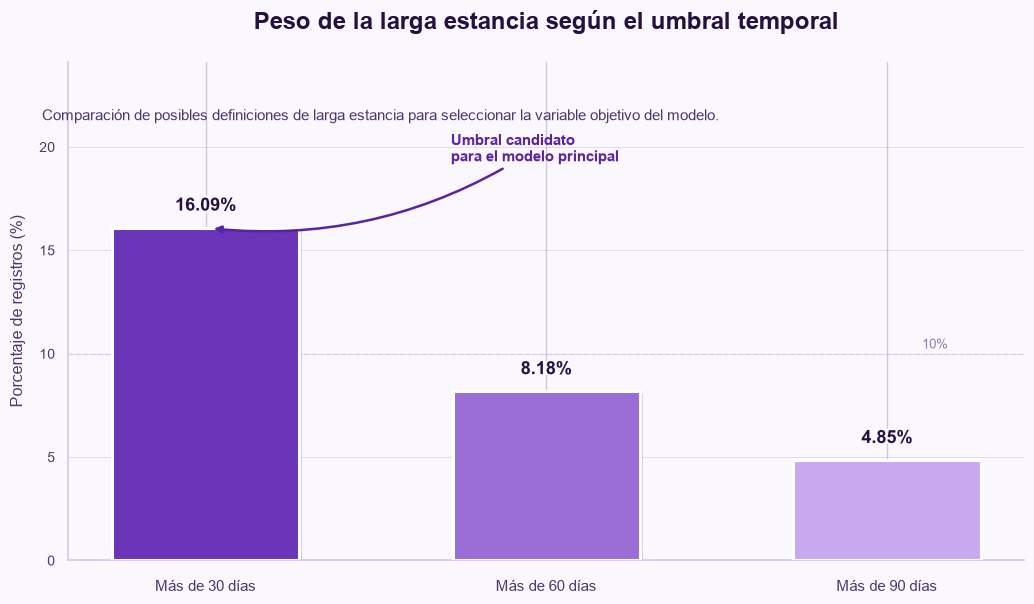

In [30]:
# Visualización de los umbrales preliminares de larga estancia

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects

fig, ax = plt.subplots(figsize=(10.5, 6.2))

umbrales = long_stay_summary["umbral"]
porcentajes = long_stay_summary["porcentaje_larga_estancia"]

bar_colors = ["#6A35B8", "#9A6DD7", "#C8A9F0"]
edge_color = "#FFFFFF"
title_color = "#24113F"
text_color = "#4B3768"
accent_color = "#5B239D"

fig.patch.set_facecolor("#FBF7FF")
ax.set_facecolor("#FBF7FF")

bars = ax.bar(
    umbrales,
    porcentajes,
    width=0.55,
    color=bar_colors,
    edgecolor=edge_color,
    linewidth=2.2,
    zorder=3
)

# Efecto de sombra suave en las barras
for bar in bars:
    bar.set_path_effects([
        path_effects.SimplePatchShadow(offset=(2, -2), alpha=0.18),
        path_effects.Normal()
    ])

ax.set_title(
    "Peso de la larga estancia según el umbral temporal",
    fontsize=17,
    fontweight="bold",
    color=title_color,
    pad=24
)

ax.text(
    -0.48,
    porcentajes.max() + 5.2,
    "Comparación de posibles definiciones de larga estancia para seleccionar la variable objetivo del modelo.",
    fontsize=10.5,
    color=text_color
)

ax.set_ylabel(
    "Porcentaje de registros (%)",
    fontsize=11.5,
    color=text_color,
    labelpad=10
)

ax.set_xlabel("")

ax.set_ylim(0, porcentajes.max() + 8)

# Etiquetas sobre las barras
for bar, value in zip(bars, porcentajes):
    label = ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.65,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=title_color
    )
    label.set_path_effects([
        path_effects.withStroke(linewidth=3, foreground="#FBF7FF")
    ])

# Anotación del umbral candidato
ax.annotate(
    "Umbral candidato\npara el modelo principal",
    xy=(0, porcentajes.iloc[0]),
    xytext=(0.72, porcentajes.iloc[0] + 3.8),
    arrowprops=dict(
        arrowstyle="-|>",
        color=accent_color,
        lw=1.8,
        shrinkA=0,
        shrinkB=6,
        connectionstyle="arc3,rad=-0.18"
    ),
    fontsize=10.5,
    fontweight="bold",
    color=accent_color,
    ha="left",
    va="center"
)

# Línea de referencia suave
ax.axhline(
    y=10,
    color="#D8C8F2",
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    zorder=1
)

ax.text(
    2.18,
    10.25,
    "10%",
    fontsize=9.5,
    color="#8E77B5",
    ha="right"
)

# Estética de ejes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", labelsize=10.5, colors=text_color, pad=8)
ax.tick_params(axis="y", labelsize=10, colors=text_color)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2",
    zorder=0
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La comparación de umbrales muestra que la definición de larga estancia a partir de más de 30 días es la que ofrece una proporción de registros más adecuada para disponer de una clase positiva suficientemente representativa, sin dejar de reflejar un fenómeno minoritario dentro del conjunto de perros analizados.

Los umbrales de 60 y 90 días representan situaciones de estancia más prolongada, pero reducen notablemente el número de casos positivos. Por ello, se mantendrán como referencias complementarias, mientras que el umbral de 30 días se considera el candidato principal para construir la variable objetivo del modelo.

## 7. Comprobaciones finales del dataset base
Antes de avanzar hacia la creación de variables predictoras, se realizan varias comprobaciones finales sobre el dataset base. El objetivo es asegurar que cada registro representa una estancia válida, que no existen duplicados relevantes y que las variables principales necesarias para el análisis posterior presentan una calidad suficiente.

In [31]:
# Comprobaciones finales del dataset base

comprobaciones_base = pd.DataFrame({
    "comprobacion": [
        "Registros totales",
        "Perros únicos",
        "Entradas duplicadas por animal y fecha",
        "Valores nulos en estancia redondeada",
        "Estancias negativas",
        "Estancias iguales a 0 días",
        "Estancias superiores a 365 días"
    ],
    "valor": [
        dogs_base.shape[0],
        dogs_base["animal_id"].nunique(),
        dogs_base.duplicated(subset=["animal_id", "intake_datetime"]).sum(),
        dogs_base["stay_days_rounded"].isna().sum(),
        (dogs_base["stay_days_rounded"] < 0).sum(),
        (dogs_base["stay_days_rounded"] == 0).sum(),
        (dogs_base["stay_days_rounded"] > 365).sum()
    ]
})

display(comprobaciones_base)

,comprobacion,valor
0,Registros totales,93803
1,Perros únicos,79555
2,Entradas duplicadas por animal y fecha,0
3,Valores nulos en estancia redondeada,0
4,Estancias negativas,0
5,Estancias iguales a 0 días,4
6,Estancias superiores a 365 días,450


Las comprobaciones finales muestran que el dataset base presenta una estructura consistente para continuar con el análisis. No se identifican duplicados por combinación de animal y fecha de entrada, no existen valores nulos en la variable de estancia redondeada y tampoco se observan estancias negativas, en línea con las garantías establecidas por el criterio de emparejamiento del apartado 6.6.

Se identifica un número reducido de registros con estancia igual a 0 días, correspondientes a perros cuya entrada y salida se producen en el mismo día, así como un conjunto de registros con estancias superiores a un año. Estos casos se consideran valores extremos, pero no se eliminan en esta fase, ya que pueden representar precisamente situaciones de larga estancia relevantes para el objetivo del proyecto.

Por tanto, el dataset base se considera válido para avanzar hacia la preparación de variables predictoras.

### 7.1. Revisión de valores extremos u outliers

Además de comprobar la ausencia de estancias negativas y valores nulos en la variable de estancia, se revisan los posibles valores extremos u *outliers* asociados al tiempo de permanencia en el refugio.

En este proyecto, los valores extremos positivos no se eliminan de forma automática, ya que las estancias muy prolongadas forman parte del fenómeno que se desea estudiar. Es decir, un perro con una permanencia excepcionalmente larga no representa necesariamente un error, sino que puede constituir precisamente un caso relevante dentro del análisis de larga estancia.

Por este motivo, el tratamiento aplicado se centra en eliminar únicamente combinaciones temporalmente incoherentes, como aquellas en las que la fecha de salida es anterior a la fecha de entrada. Las estancias positivas muy elevadas se conservan en el dataset y se tendrán en cuenta tanto en el análisis exploratorio como en la posterior fase de modelización.

In [32]:
# Revisión de valores extremos u outliers en el tiempo de estancia

q1 = dogs_base["stay_days_rounded"].quantile(0.25)
q3 = dogs_base["stay_days_rounded"].quantile(0.75)
iqr = q3 - q1

limite_superior_outlier = q3 + 1.5 * iqr

outliers_estancia = dogs_base[
    dogs_base["stay_days_rounded"] > limite_superior_outlier
].copy()

resumen_outliers_estancia = pd.DataFrame({
    "indicador": [
        "Primer cuartil (Q1)",
        "Tercer cuartil (Q3)",
        "Rango intercuartílico (IQR)",
        "Límite superior para detección de outliers",
        "Número de estancias consideradas outliers",
        "Porcentaje de outliers sobre el dataset base",
        "Máxima estancia registrada"
    ],
    "valor": [
        q1,
        q3,
        iqr,
        limite_superior_outlier,
        outliers_estancia.shape[0],
        round(outliers_estancia.shape[0] / dogs_base.shape[0] * 100, 2),
        dogs_base["stay_days_rounded"].max()
    ]
})

display(resumen_outliers_estancia)

print("Ejemplos de estancias prolongadas detectadas como outliers:")
display(
    outliers_estancia[[
        "animal_id",
        "intake_datetime",
        "outcome_datetime",
        "stay_days_rounded",
        "intake_type",
        "intake_condition",
        "age_upon_intake",
        "breed_intake",
        "outcome_type"
    ]]
    .sort_values("stay_days_rounded", ascending=False)
    .head(10)
)

,indicador,valor
0,Primer cuartil (Q1),3.00
1,Tercer cuartil (Q3),16.00
2,Rango intercuartílico (IQR),13.00
3,Límite superior para detección de outliers,35.50
4,Número de estancias consideradas outliers,13198.00
5,Porcentaje de outliers sobre el dataset base,14.07
6,Máxima estancia registrada,1913.00


Ejemplos de estancias prolongadas detectadas como outliers:


,animal_id,intake_datetime,outcome_datetime,stay_days_rounded,intake_type,intake_condition,age_upon_intake,breed_intake,outcome_type
25681,A642712,2016-01-05 11:37:00,2021-04-01 10:08:00,1913,Stray,Injured,6 years,Pit Bull Mix,Adoption
27938,A722987,2016-03-24 16:59:00,2020-05-24 16:30:00,1522,Owner Surrender,Normal,1 year,Pit Bull,Adoption
64872,A810081,2020-01-21 12:36:00,2023-10-10 08:26:00,1358,Owner Surrender,Normal,1 year,Pit Bull,Adoption
34080,A737705,2016-11-02 20:15:00,2020-07-16 16:35:08,1352,Stray,Normal,3 years,Labrador Retriever Mix,Transfer
51466,A778611,2018-08-17 14:37:00,2021-11-24 14:43:00,1196,Owner Surrender,Normal,8 years,Pit Bull Mix,Adoption
74748,A843014,2021-09-25 08:19:00,2024-12-27 09:20:00,1190,Stray,Injured,2 years,Pit Bull,Adoption
37827,A745344,2021-04-14 15:10:00,2024-06-27 15:39:00,1171,Owner Surrender,Normal,6 years,Pit Bull Mix,Adoption
47937,A769485,2018-04-05 14:39:00,2021-06-16 10:34:00,1168,Stray,Normal,10 years,Staffordshire Mix,Adoption
47936,A769484,2018-04-05 14:39:00,2021-06-16 10:34:00,1168,Stray,Normal,10 years,Boxer Mix,Adoption
73913,A840685,2021-08-12 09:19:00,2024-10-22 13:13:00,1168,Stray,Normal,5 years,Pit Bull/Golden Retriever,Adoption


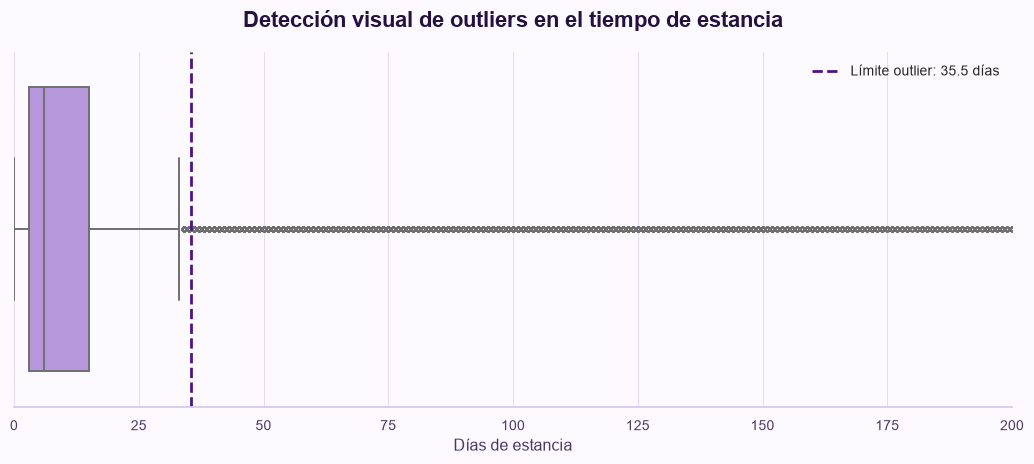

In [33]:
# Visualización de outliers en el tiempo de estancia

stay_days_boxplot = dogs_base[dogs_base["stay_days_rounded"] <= 200].copy()

fig, ax = plt.subplots(figsize=(10.5, 4.8))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

sns.boxplot(
    data=stay_days_boxplot,
    x="stay_days_rounded",
    color="#B68BE8",
    fliersize=3,
    linewidth=1.4,
    ax=ax
)

ax.axvline(
    limite_superior_outlier,
    color="#4A148C",
    linestyle="--",
    linewidth=2,
    label=f"Límite outlier: {limite_superior_outlier:.1f} días"
)

ax.set_title(
    "Detección visual de outliers en el tiempo de estancia",
    fontsize=16,
    fontweight="bold",
    color="#24113F",
    pad=18
)

ax.set_xlabel("Días de estancia", fontsize=11.5, color="#4B3768")
ax.set_ylabel("")

ax.set_xlim(0, 200)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", left=False, labelleft=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La revisión mediante el rango intercuartílico permite identificar estancias especialmente prolongadas respecto a la distribución general del dataset, tal como muestra el resumen anterior: el límite superior para la detección estadística de *outliers* resulta considerablemente inferior a la estancia máxima registrada, lo que confirma la existencia de una cola larga en la distribución del tiempo de permanencia.

La visualización mediante boxplot se ha acotado a 200 días para facilitar la lectura de la zona principal de la distribución. Esta representación permite observar con mayor claridad la concentración de registros en estancias cortas y la presencia de valores por encima del límite estadístico de outlier.

No obstante, en el contexto de este proyecto, estos valores no se consideran errores a eliminar de forma automática. Al contrario, representan casos especialmente relevantes, ya que el objetivo del trabajo es precisamente identificar perros con riesgo de larga estancia.

Por tanto, se conservan las estancias positivas extremas y únicamente se descartan registros temporalmente incoherentes, como aquellos en los que la fecha de salida es anterior a la fecha de entrada. Esta decisión permite mantener la información asociada a los casos más críticos y evita eliminar observaciones que podrían aportar señal predictiva al modelo.

El criterio de detección de outliers aplicado en el apartado anterior se basa en el rango intercuartílico (IQR) calculado directamente sobre `stay_days_rounded`. Sin embargo, este criterio asume implícitamente una distribución razonablemente simétrica, y `stay_days_rounded` presenta una asimetría muy pronunciada, con una mediana muy inferior a la cola de valores máximos observados. En distribuciones de este tipo, el IQR clásico tiende a señalar como outliers una proporción de registros inusualmente alta, lo que puede restar utilidad práctica al criterio. A continuación se comparan tres formas alternativas de identificar valores extremos —un criterio basado en percentiles altos (P95 y P99) y un IQR aplicado sobre la variable transformada logarítmicamente— frente al IQR clásico ya calculado, con el fin de valorar si este último es el más adecuado para este caso.

In [34]:
# Comparación de criterios de detección de valores extremos ante una distribución asimétrica

p95 = dogs_base["stay_days_rounded"].quantile(0.95)
p99 = dogs_base["stay_days_rounded"].quantile(0.99)

registros_p95 = (dogs_base["stay_days_rounded"] > p95).sum()
registros_p99 = (dogs_base["stay_days_rounded"] > p99).sum()

log_stay_days = np.log1p(dogs_base["stay_days_rounded"])
log_q1 = log_stay_days.quantile(0.25)
log_q3 = log_stay_days.quantile(0.75)
log_iqr = log_q3 - log_q1
limite_superior_log = log_q3 + 1.5 * log_iqr
limite_superior_log_dias = np.expm1(limite_superior_log)

registros_iqr_log = (log_stay_days > limite_superior_log).sum()

comparacion_criterios_outliers = pd.DataFrame({
    "criterio": [
        "IQR clásico sobre stay_days_rounded",
        "Percentil 95 (P95)",
        "Percentil 99 (P99)",
        "IQR sobre log1p(stay_days_rounded)"
    ],
    "limite_superior_dias": [
        round(limite_superior_outlier, 2),
        round(p95, 2),
        round(p99, 2),
        round(limite_superior_log_dias, 2)
    ],
    "registros_por_encima_del_limite": [
        outliers_estancia.shape[0],
        registros_p95,
        registros_p99,
        registros_iqr_log
    ],
    "porcentaje_del_dataset_base": [
        round(outliers_estancia.shape[0] / dogs_base.shape[0] * 100, 2),
        round(registros_p95 / dogs_base.shape[0] * 100, 2),
        round(registros_p99 / dogs_base.shape[0] * 100, 2),
        round(registros_iqr_log / dogs_base.shape[0] * 100, 2)
    ]
})

display(comparacion_criterios_outliers)

,criterio,limite_superior_dias,registros_por_encima_del_limite,porcentaje_del_dataset_base
0,IQR clásico sobre stay_days_rounded,35.50,13198,14.07
1,Percentil 95 (P95),88.00,4657,4.96
2,Percentil 99 (P99),256.98,939,1.00
3,IQR sobre log1p(stay_days_rounded),147.95,2315,2.47


La comparación confirma que el criterio elegido influye de forma notable en la proporción de registros señalados como extremos. El IQR clásico, aplicado directamente sobre `stay_days_rounded`, marca una proporción de registros elevada, coherente con la fuerte asimetría de la distribución, pero que difícilmente puede interpretarse como un conjunto de casos verdaderamente anómalos. Los criterios basados en percentiles altos, por construcción, identifican exactamente el 5 % y el 1 % más extremo de la distribución, con independencia de su forma. El IQR aplicado sobre la variable transformada logarítmicamente resulta el criterio más conservador de los cuatro: al calcular los cuartiles en una escala que atenúa la cola larga, señala un porcentaje de registros extremos notablemente inferior al del IQR clásico.

Esta comparación confirma la limitación señalada: el IQR clásico no es el criterio más adecuado para una variable tan asimétrica como `stay_days_rounded`, ya que su supuesto implícito de simetría infla artificialmente el número de outliers detectados. No obstante, esta observación no invalida la decisión metodológica adoptada en el apartado 7.1 de no eliminar los valores extremos positivos: dado que el objetivo del proyecto es precisamente identificar perros con estancias prolongadas, cualquiera de los cuatro criterios comparados confirmaría la existencia de una cola de casos relevantes que debe conservarse en el dataset. La elección del criterio afecta a cuántos registros se etiquetan como extremos, pero no a la decisión de conservarlos, que se mantiene inalterada.

Las cifras concretas que se citan en el resto de este notebook (recuentos, porcentajes, estadísticos de contraste, etc.) proceden de la ejecución sobre el dataset base construido con el criterio de emparejamiento corregido en el apartado 6.6. Dado que ese criterio coincidía ya con el anterior en la inmensa mayoría de los casos, cabe esperar que las cifras y los patrones descritos a continuación se mantengan prácticamente inalterados; aun así, los valores exactos son siempre los que resultan de la salida de cada celda de código en la última ejecución del notebook, que debe prevalecer sobre cualquier cifra citada en el texto si llegara a producirse una discrepancia mínima.

### 7.2. Revisión de tipos de salida

Antes de avanzar hacia la creación de variables predictoras, se revisa la distribución de los tipos de salida registrados en el dataset base. Esta variable permite entender los principales desenlaces de los perros tras su paso por el refugio y puede aportar contexto relevante para interpretar el tiempo de estancia.

In [35]:
# Revisión de tipos de salida

outcome_type_summary = (
    dogs_base["outcome_type"]
    .value_counts(dropna=False)
    .reset_index()
)

outcome_type_summary.columns = ["tipo_salida", "registros"]
outcome_type_summary["porcentaje"] = (
    outcome_type_summary["registros"] / outcome_type_summary["registros"].sum() * 100
).round(2)

display(outcome_type_summary)

,tipo_salida,registros,porcentaje
0,Adoption,47167,50.28
1,Return to Owner,22587,24.08
2,Transfer,20339,21.68
3,Euthanasia,2173,2.32
4,Rto-Adopt,987,1.05
5,Died,387,0.41
6,Disposal,95,0.10
7,Missing,33,0.04
8,NaN,27,0.03
9,Stolen,5,0.01


La revisión de `outcome_type` muestra que la adopción es el desenlace más frecuente, seguida de la devolución al propietario y la transferencia a otras entidades. Estas tres categorías concentran la mayor parte de los registros del dataset base.

Aunque el objetivo principal del proyecto no es predecir el tipo de salida, esta variable aporta contexto relevante sobre la dinámica del refugio y permite entender mejor los posibles desenlaces asociados al tiempo de estancia.

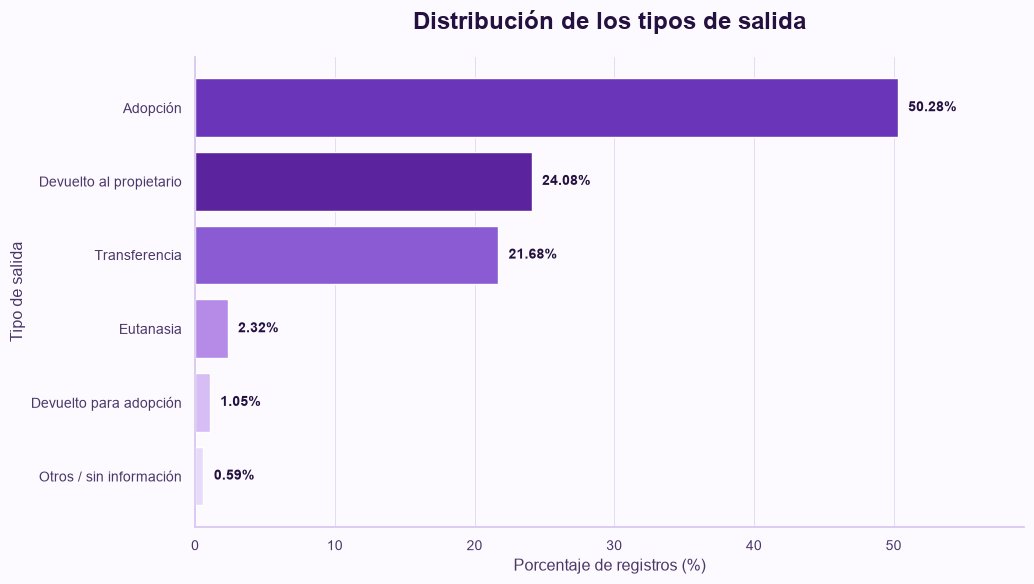

In [36]:
# Visualización de tipos de salida

traduccion_salidas = {
    "Adoption": "Adopción",
    "Return to Owner": "Devuelto al propietario",
    "Transfer": "Transferencia",
    "Euthanasia": "Eutanasia",
    "Rto-Adopt": "Devuelto para adopción",
    "Died": "Fallecimiento",
    "Disposal": "Retirada",
    "Missing": "Desaparecido",
    "Stolen": "Robado",
    "Relocate": "Reubicación",
    "Lost": "Perdido"
}

outcome_type_plot = outcome_type_summary.copy()
outcome_type_plot["tipo_salida_es"] = outcome_type_plot["tipo_salida"].map(traduccion_salidas)
outcome_type_plot["tipo_salida_es"] = outcome_type_plot["tipo_salida_es"].fillna("Sin información")

outcome_type_plot["tipo_salida_agrupada"] = np.where(
    outcome_type_plot["porcentaje"] < 1,
    "Otros / sin información",
    outcome_type_plot["tipo_salida_es"]
)

outcome_type_plot = (
    outcome_type_plot
    .groupby("tipo_salida_agrupada", as_index=False)
    .agg({
        "registros": "sum",
        "porcentaje": "sum"
    })
    .sort_values("porcentaje", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#5B239D", "#6A35B8"]

bars = ax.barh(
    outcome_type_plot["tipo_salida_agrupada"],
    outcome_type_plot["porcentaje"],
    color=colors[:len(outcome_type_plot)]
)

ax.set_title(
    "Distribución de los tipos de salida",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Tipo de salida", fontsize=11.5, color="#4B3768")

max_value = outcome_type_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, outcome_type_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución de los tipos de salida muestra que la adopción es el desenlace más frecuente, con el 50,28 % de los registros. A continuación aparecen la devolución al propietario, con el 24,08 %, y la transferencia a otras entidades, con el 21,68 %.

Estas tres categorías concentran la gran mayoría de salidas del dataset base. Este resultado aporta contexto sobre la dinámica del refugio y será relevante en fases posteriores para interpretar posibles diferencias en los tiempos de estancia según el tipo de desenlace.

### 7.3. Revisión de variables categóricas principales

Una vez revisado el tipo de salida, se analizan las principales variables categóricas disponibles en el momento de entrada del perro al refugio. Estas variables son especialmente relevantes porque estarán disponibles antes de conocer el desenlace final y, por tanto, podrán utilizarse como posibles variables predictoras en el modelo.

En esta revisión se incluyen variables como el tipo de entrada, la condición inicial, el sexo registrado en la entrada, la raza y el color del perro.

In [37]:
# Revisión de variables categóricas principales

variables_categoricas = [
    "intake_type",
    "intake_condition",
    "sex_upon_intake",
    "breed_intake",
    "color_intake"
]

resumen_categoricas = []

for variable in variables_categoricas:
    resumen_categoricas.append({
        "variable": variable,
        "categorias_unicas": dogs_base[variable].nunique(dropna=True),
        "valores_nulos": dogs_base[variable].isna().sum(),
        "porcentaje_nulos": round(dogs_base[variable].isna().mean() * 100, 2)
    })

resumen_categoricas = pd.DataFrame(resumen_categoricas)

display(resumen_categoricas)

,variable,categorias_unicas,valores_nulos,porcentaje_nulos
0,intake_type,6,0,0.0
1,intake_condition,18,0,0.0
2,sex_upon_intake,5,1,0.0
3,breed_intake,2650,0,0.0
4,color_intake,400,0,0.0


La revisión de variables categóricas muestra que las variables `intake_type`, `intake_condition` y `sex_upon_intake` presentan un número reducido o moderado de categorías, por lo que podrán incorporarse al modelo con un tratamiento relativamente directo.

En cambio, las variables `breed_intake` y `color_intake` presentan una cardinalidad elevada, especialmente la raza, con 2.650 categorías distintas. Esto indica que será necesario aplicar estrategias de agrupación o transformación antes de la modelización, para evitar generar un número excesivo de variables y reducir el riesgo de sobreajuste.

En las siguientes fases se analizará con mayor detalle la distribución de estas variables para decidir cómo tratarlas de forma adecuada.

### 7.4. Distribución del tipo de entrada

A continuación se analiza la distribución del tipo de entrada de los perros en el refugio. Esta variable resulta relevante porque describe la circunstancia inicial por la que el animal llega al centro y puede influir en su probabilidad de permanecer más o menos tiempo.

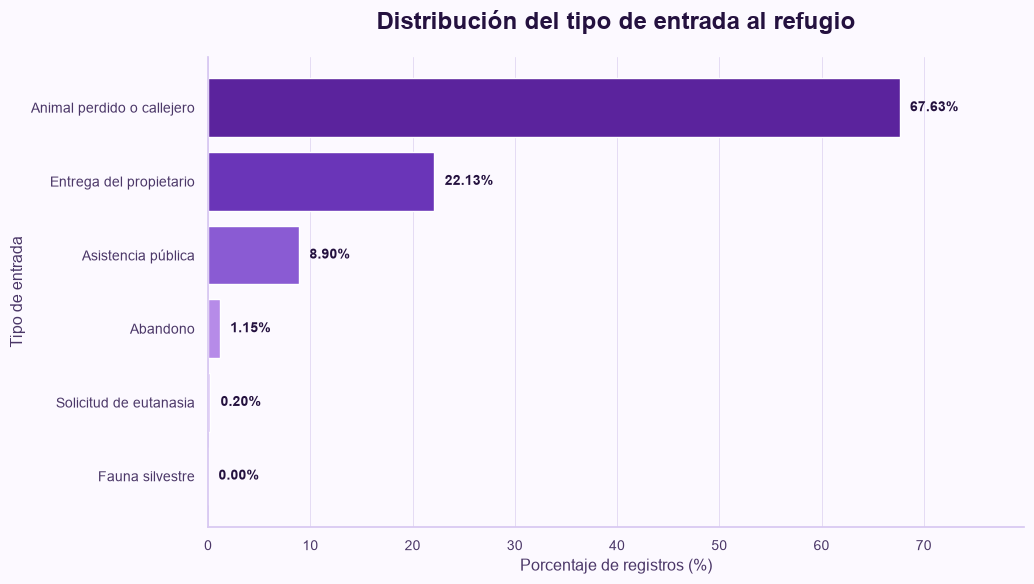

,tipo_entrada,registros,porcentaje,tipo_entrada_es
0,Stray,63439,67.63,Animal perdido o callejero
1,Owner Surrender,20754,22.13,Entrega del propietario
2,Public Assist,8345,8.90,Asistencia pública
3,Abandoned,1081,1.15,Abandono
4,Euthanasia Request,183,0.20,Solicitud de eutanasia
5,Wildlife,1,0.00,Fauna silvestre


In [38]:
# Distribución del tipo de entrada

intake_type_summary = (
    dogs_base["intake_type"]
    .value_counts(dropna=False)
    .reset_index()
)

intake_type_summary.columns = ["tipo_entrada", "registros"]
intake_type_summary["porcentaje"] = (
    intake_type_summary["registros"] / intake_type_summary["registros"].sum() * 100
).round(2)

traduccion_entradas = {
    "Stray": "Animal perdido o callejero",
    "Owner Surrender": "Entrega del propietario",
    "Public Assist": "Asistencia pública",
    "Wildlife": "Fauna silvestre",
    "Euthanasia Request": "Solicitud de eutanasia",
    "Abandoned": "Abandono"
}

intake_type_summary["tipo_entrada_es"] = (
    intake_type_summary["tipo_entrada"]
    .map(traduccion_entradas)
    .fillna("Sin información")
)

intake_type_plot = intake_type_summary.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#6A35B8", "#5B239D"]

bars = ax.barh(
    intake_type_plot["tipo_entrada_es"],
    intake_type_plot["porcentaje"],
    color=colors[:len(intake_type_plot)]
)

ax.set_title(
    "Distribución del tipo de entrada al refugio",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Tipo de entrada", fontsize=11.5, color="#4B3768")

max_value = intake_type_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, intake_type_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

display(intake_type_summary)

La distribución del tipo de entrada muestra que la mayoría de los perros llega al refugio como animal perdido o callejero, con el 67,63 % de los registros. La segunda categoría más frecuente es la entrega por parte del propietario, con el 22,13 %, seguida de la asistencia pública, con el 8,89 %.

Este resultado indica que el contexto de entrada al refugio está muy concentrado en unas pocas categorías. Esta variable puede ser relevante para el modelo predictivo, ya que las circunstancias de entrada pueden estar asociadas a distintos patrones de estancia y salida.

### 7.5. Distribución de la condición de entrada

A continuación se analiza la condición registrada en el momento de entrada del perro al refugio. Esta variable puede aportar información relevante sobre el estado inicial del animal y su posible relación con el tiempo de estancia.

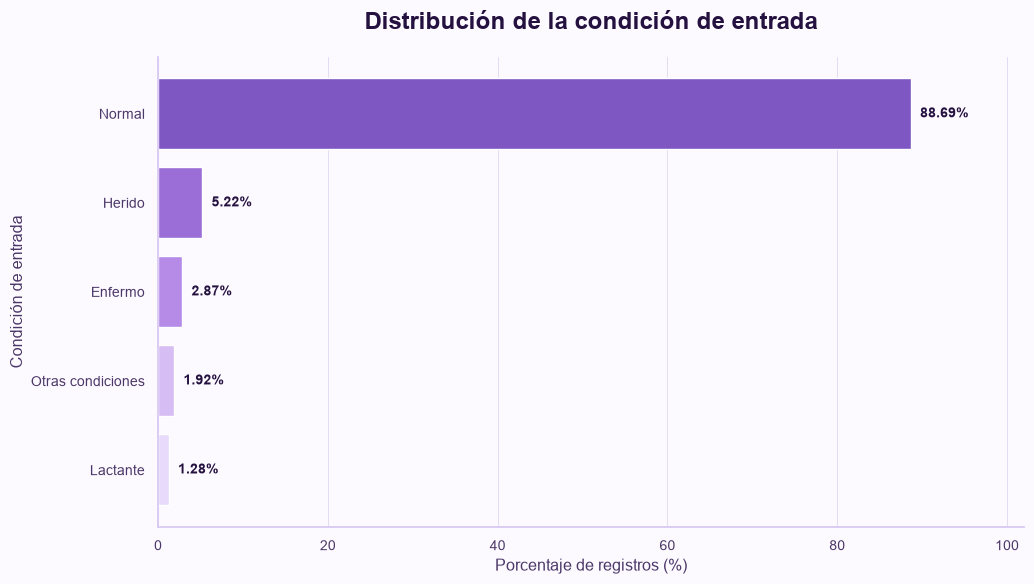

In [39]:
# Distribución de la condición de entrada

condition_summary = (
    dogs_base["intake_condition"]
    .value_counts(dropna=False)
    .reset_index()
)

condition_summary.columns = ["condicion_entrada", "registros"]
condition_summary["porcentaje"] = (
    condition_summary["registros"] / condition_summary["registros"].sum() * 100
).round(2)

traduccion_condiciones = {
    "Normal": "Normal",
    "Injured": "Herido",
    "Sick": "Enfermo",
    "Nursing": "Lactante",
    "Aged": "Edad avanzada",
    "Other": "Otra condición",
    "Medical": "Condición médica",
    "Neonatal": "Neonatal",
    "Pregnant": "Gestante",
    "Behavior": "Conducta",
    "Feral": "Ferales",
    "Space": "Falta de espacio",
    "Med Attn": "Atención médica",
    "Panleuk": "Panleucopenia",
    "Agonal": "Agónico",
    "At Vet": "En veterinario",
    "Med Urgent": "Urgencia médica",
    "Neurologic": "Neurológico"
}

condition_summary["condicion_entrada_es"] = (
    condition_summary["condicion_entrada"]
    .map(traduccion_condiciones)
    .fillna("Sin información")
)

# Agrupamos categorías muy minoritarias para mejorar la legibilidad
condition_summary["condicion_entrada_agrupada"] = np.where(
    condition_summary["porcentaje"] < 1,
    "Otras condiciones",
    condition_summary["condicion_entrada_es"]
)

condition_plot = (
    condition_summary
    .groupby("condicion_entrada_agrupada", as_index=False)
    .agg({
        "registros": "sum",
        "porcentaje": "sum"
    })
    .sort_values("porcentaje", ascending=True)
)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#9A6DD7", "#7E57C2", "#6A35B8", "#5B239D"]

bars = ax.barh(
    condition_plot["condicion_entrada_agrupada"],
    condition_plot["porcentaje"],
    color=colors[:len(condition_plot)]
)

ax.set_title(
    "Distribución de la condición de entrada",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Condición de entrada", fontsize=11.5, color="#4B3768")

max_value = condition_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.15)

for bar, value in zip(bars, condition_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución de la condición de entrada muestra una fuerte concentración en la categoría normal, que representa el 88,69 % de los registros. A mayor distancia aparecen perros heridos, enfermos, lactantes y otras condiciones minoritarias.

Este resultado indica que la mayoría de perros llega al refugio sin una condición especial registrada. No obstante, las categorías asociadas a estados de salud o vulnerabilidad pueden ser relevantes para el modelo, ya que podrían estar relacionadas con tiempos de estancia diferentes.

### 7.6. Distribución del sexo registrado en la entrada

A continuación se analiza la distribución del sexo y estado reproductivo registrado en el momento de entrada. Esta variable puede aportar información relevante sobre el perfil del perro y será una de las candidatas a incorporarse en la fase de modelización.

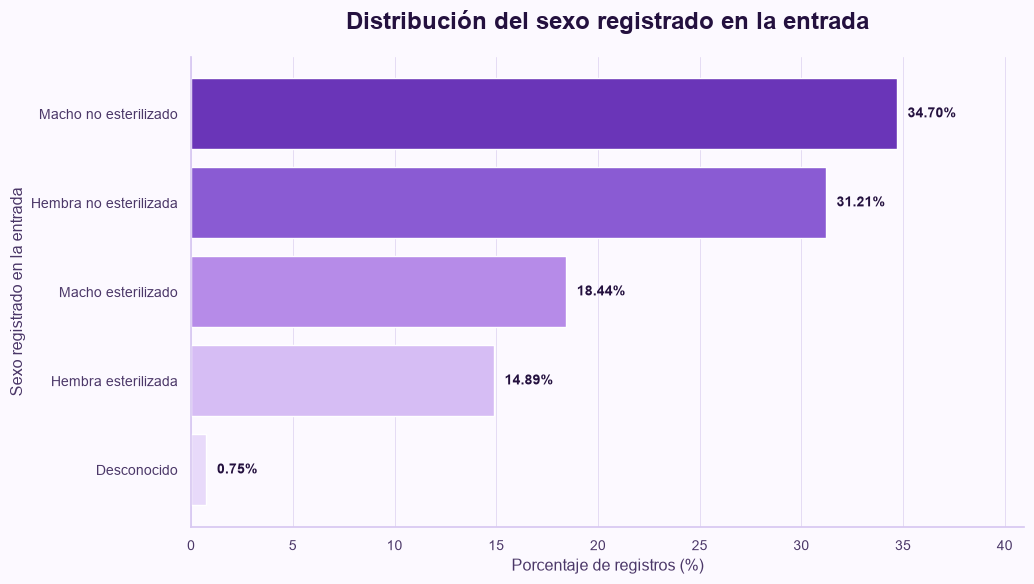

In [40]:
# Distribución del sexo registrado en la entrada

sex_summary = (
    dogs_base["sex_upon_intake"]
    .value_counts(dropna=False)
    .reset_index()
)

sex_summary.columns = ["sexo_entrada", "registros"]
sex_summary["porcentaje"] = (
    sex_summary["registros"] / sex_summary["registros"].sum() * 100
).round(2)

traduccion_sexo = {
    "Intact Male": "Macho no esterilizado",
    "Intact Female": "Hembra no esterilizada",
    "Neutered Male": "Macho esterilizado",
    "Spayed Female": "Hembra esterilizada",
    "Unknown": "Desconocido"
}

sex_summary["sexo_entrada_es"] = (
    sex_summary["sexo_entrada"]
    .map(traduccion_sexo)
    .fillna("Sin información")
)

# Se eliminan de la visualización las categorías con porcentaje 0,00 %
sex_plot = sex_summary[sex_summary["porcentaje"] > 0].copy()
sex_plot = sex_plot.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#6A35B8", "#5B239D"]

bars = ax.barh(
    sex_plot["sexo_entrada_es"],
    sex_plot["porcentaje"],
    color=colors[:len(sex_plot)]
)

ax.set_title(
    "Distribución del sexo registrado en la entrada",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Sexo registrado en la entrada", fontsize=11.5, color="#4B3768")

max_value = sex_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, sex_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución del sexo registrado en la entrada muestra que las categorías más frecuentes son macho no esterilizado y hembra no esterilizada, con el 34,70 % y el 31,21 % de los registros, respectivamente. A continuación aparecen los machos esterilizados, con el 18,44 %, y las hembras esterilizadas, con el 14,90 %.

Este resultado indica que una parte importante de los perros llega al refugio sin estar esterilizada. Esta variable puede ser relevante en la fase de modelización, ya que combina información sobre sexo y estado reproductivo del animal en el momento de entrada.

### 7.7. Revisión de las razas más frecuentes

La variable de raza presenta una cardinalidad elevada, con un gran número de categorías diferentes. Por este motivo, antes de decidir su tratamiento para la modelización, se revisan las razas más frecuentes del dataset.

Este análisis permite identificar si existen razas o cruces especialmente representados y valorar si será necesario aplicar estrategias de agrupación para reducir la complejidad de la variable.

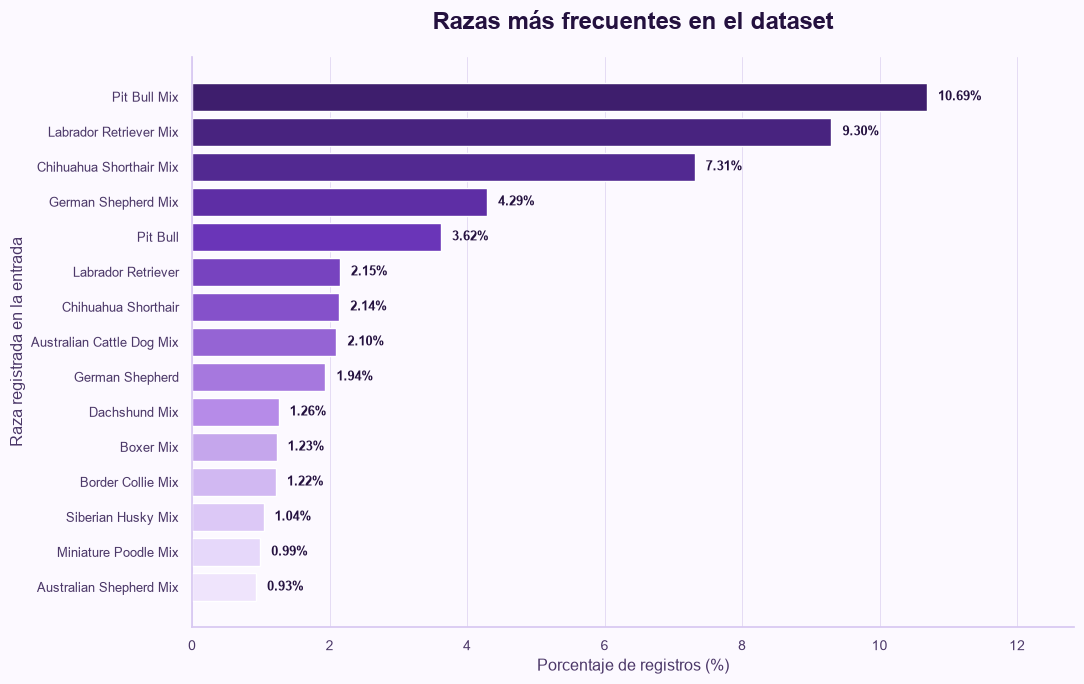

In [41]:
# Visualización de las razas más frecuentes

breed_summary = (
    dogs_base["breed_intake"]
    .value_counts(dropna=False)
    .reset_index()
)

breed_summary.columns = ["raza", "registros"]
breed_summary["porcentaje"] = (
    breed_summary["registros"] / breed_summary["registros"].sum() * 100
).round(2)

top_breeds = breed_summary.head(15).copy()
top_breeds = top_breeds.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = [
    "#EFE4FC", "#E6D8FA", "#DCC8F6", "#D1B8F2", "#C5A6EC",
    "#B68BE8", "#A678DE", "#9564D4", "#8551CA", "#7743BF",
    "#6A35B8", "#5E2EA5", "#522991", "#48237F", "#3E1E6D"
]

bars = ax.barh(
    top_breeds["raza"],
    top_breeds["porcentaje"],
    color=colors[:len(top_breeds)]
)

ax.set_title(
    "Razas más frecuentes en el dataset",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Raza registrada en la entrada", fontsize=11.5, color="#4B3768")

max_value = top_breeds["porcentaje"].max()
ax.set_xlim(0, max_value * 1.20)

for bar, value in zip(bars, top_breeds["porcentaje"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=9.5)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

El análisis de las razas más frecuentes muestra que los cruces de Pit Bull, Labrador Retriever y Chihuahua Shorthair son los más representados en el dataset. Sin embargo, incluso la categoría más frecuente representa únicamente el 10,69 % de los registros, lo que confirma que la variable de raza está muy fragmentada.

Esta elevada dispersión refuerza la necesidad de aplicar un tratamiento específico antes de la modelización. En lugar de utilizar directamente todas las categorías originales, será conveniente valorar estrategias como agrupar razas minoritarias, identificar si el perro es de raza mixta o crear variables simplificadas a partir de la información disponible.

### 7.8. Revisión de los colores más frecuentes

La variable de color también presenta una cardinalidad elevada, aunque menor que la variable de raza. Antes de decidir su tratamiento para la modelización, se revisan los colores más frecuentes registrados en el momento de entrada.

Este análisis permite identificar si existen colores o combinaciones de colores especialmente habituales y valorar si será necesario simplificar esta variable antes de incorporarla al modelo.

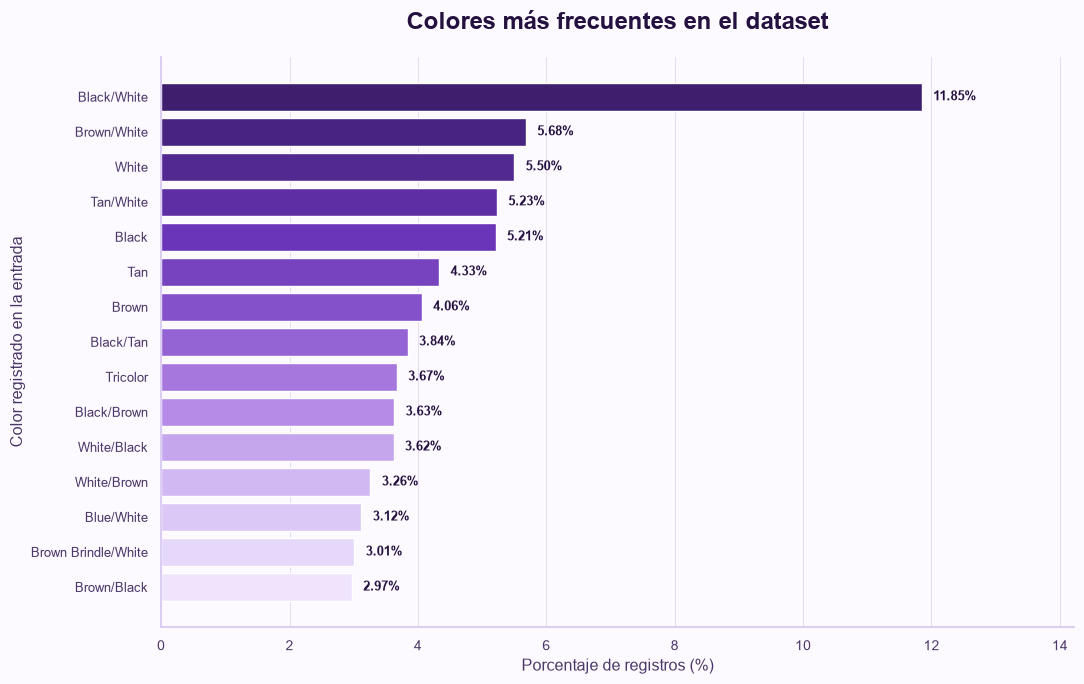

In [42]:
# Visualización de los colores más frecuentes

color_summary = (
    dogs_base["color_intake"]
    .value_counts(dropna=False)
    .reset_index()
)

color_summary.columns = ["color", "registros"]
color_summary["porcentaje"] = (
    color_summary["registros"] / color_summary["registros"].sum() * 100
).round(2)

top_colors = color_summary.head(15).copy()
top_colors = top_colors.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = [
    "#EFE4FC", "#E6D8FA", "#DCC8F6", "#D1B8F2", "#C5A6EC",
    "#B68BE8", "#A678DE", "#9564D4", "#8551CA", "#7743BF",
    "#6A35B8", "#5E2EA5", "#522991", "#48237F", "#3E1E6D"
]

bars = ax.barh(
    top_colors["color"],
    top_colors["porcentaje"],
    color=colors[:len(top_colors)]
)

ax.set_title(
    "Colores más frecuentes en el dataset",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Color registrado en la entrada", fontsize=11.5, color="#4B3768")

max_value = top_colors["porcentaje"].max()
ax.set_xlim(0, max_value * 1.20)

for bar, value in zip(bars, top_colors["porcentaje"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=9.5)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

El análisis de los colores más frecuentes muestra que la combinación `Black/White` es la más habitual, con el 11,85 % de los registros. A continuación aparecen otras combinaciones como `Brown/White`, `White`, `Tan/White` y `Black`, todas con porcentajes bastante inferiores.

Al igual que ocurre con la variable de raza, la variable de color presenta una distribución fragmentada, con múltiples combinaciones distintas. Esto indica que será conveniente simplificar esta variable antes de la modelización, por ejemplo agrupando colores minoritarios o extrayendo un color principal a partir del valor original.

### 7.9. Análisis de valores nulos en el dataset base

Antes de crear las variables predictoras (apartado 8), se revisa la presencia de valores nulos en el dataset base resultante de la unión y depuración de entradas y salidas. Esta revisión complementa la realizada en el apartado 5.2 sobre los datasets originales, ya que permite comprobar si el proceso de unión, filtrado y selección de la salida más cercana ha alterado la calidad de las variables disponibles.

,variable,nulos,porcentaje_nulos
15,outcome_subtype,62835,66.99
11,name_outcome,14698,15.67
1,name_intake,14698,15.67
14,outcome_type,27,0.03
0,animal_id,0,0.00
5,intake_type,0,0.00
2,animal_type_intake,0,0.00
3,intake_datetime,0,0.00
4,found_location,0,0.00
8,age_upon_intake,0,0.00


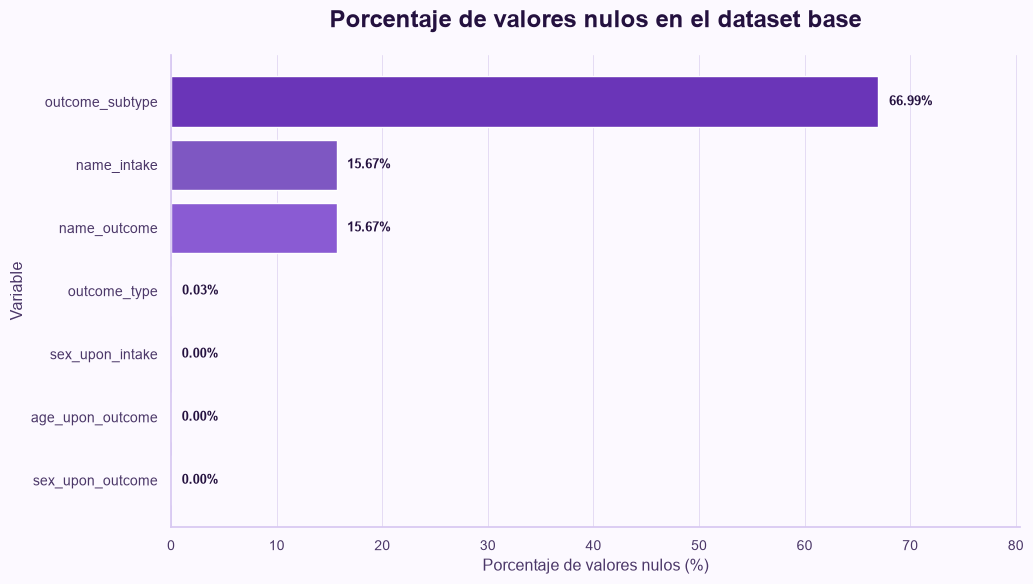

In [43]:
# Análisis de valores nulos en el dataset base

nulos_dogs_base = pd.DataFrame({
    "variable": dogs_base.columns,
    "nulos": dogs_base.isna().sum().values,
    "porcentaje_nulos": (dogs_base.isna().mean().values * 100).round(2)
}).sort_values("porcentaje_nulos", ascending=False)

display(nulos_dogs_base)

nulos_plot = nulos_dogs_base[nulos_dogs_base["nulos"] > 0].sort_values("porcentaje_nulos", ascending=True)

colors_nulos = ["#D6BDF4", "#C5A6EC", "#B68BE8", "#9A6DD7", "#8A5BD3", "#7E57C2", "#6A35B8"]

plot_barh_estilo_invisible_dogs(
    categorias=nulos_plot["variable"],
    valores=nulos_plot["porcentaje_nulos"],
    titulo="Porcentaje de valores nulos en el dataset base",
    xlabel="Porcentaje de valores nulos (%)",
    ylabel="Variable",
    colors=colors_nulos[:len(nulos_plot)],
    value_fmt="{:.2f}%"
)

El dataset base mantiene una calidad elevada tras el proceso de unión y depuración. La variable con mayor porcentaje de nulos es `outcome_subtype`, heredada directamente del dataset original de salidas y ya identificada como poco informativa en el apartado 5.2. Las variables `name_intake` y `name_outcome` presentan un porcentaje de nulos similar al observado antes de la unión, en torno al 15,7 %, y no son relevantes para la modelización.

El resto de variables clave para el cálculo del tiempo de estancia y para la construcción de variables predictoras (`intake_type`, `intake_condition`, `sex_upon_intake`, `age_upon_intake`, `breed_intake`, `color_intake`) presenta porcentajes de nulos prácticamente nulos, inferiores al 0,05 %. Este resultado confirma que el proceso de unión y selección de la salida más cercana descrito en el apartado 6 no ha degradado la calidad del dataset y respalda la limitación documentada en el apartado 6.7, dado el volumen marginal de registros afectados.

## 8. Creación de variables predictoras

Una vez revisada la estructura del dataset base y las principales variables categóricas, se procede a crear un conjunto inicial de variables predictoras. Estas variables se construirán utilizando únicamente información disponible en el momento de entrada del perro al refugio, evitando incorporar información posterior que pudiera generar fuga de información en la fase de modelización.

En esta fase se prepararán variables relacionadas con la edad, el sexo, el estado reproductivo, el tipo de entrada, la condición inicial, la raza y el color.

### 8.1. Transformación de la edad

La variable `age_upon_intake` recoge la edad del perro en formato textual, combinando distintas unidades como años, meses, semanas o días. Para poder utilizar esta información en el análisis y en la fase posterior de modelización, se transforma a una escala numérica común.

En este caso, se convierte la edad a meses, lo que permite comparar de forma homogénea perros de distintas edades y construir posteriormente variables derivadas por grupo de edad.

In [44]:
# Conversión de edad textual a meses

dogs_base["age_months_intake"] = dogs_base["age_upon_intake"].apply(convertir_edad_a_meses)

print("Valores nulos en edad original:")
print(dogs_base["age_upon_intake"].isna().sum())

print("\nValores nulos tras convertir edad a meses:")
print(dogs_base["age_months_intake"].isna().sum())

print("\nResumen de edad en meses:")
display(dogs_base["age_months_intake"].describe())

display(dogs_base[[
    "animal_id",
    "age_upon_intake",
    "age_months_intake"
]].head(10))

Valores nulos en edad original:
0

Valores nulos tras convertir edad a meses:
0

Resumen de edad en meses:


count    93803.000000
mean        29.730404
std         35.602653
min        -36.000000
25%          6.000000
50%         12.000000
75%         36.000000
max        288.000000
Name: age_months_intake, dtype: float64

,animal_id,age_upon_intake,age_months_intake
0,A521520,7 years,84.0
1,A664233,3 years,36.0
2,A664234,8 years,96.0
3,A664257,4 years,48.0
4,A664266,1 year,12.0
5,A664258,7 years,84.0
6,A648744,1 year,12.0
7,A651630,6 years,72.0
8,A664259,5 years,60.0
9,A664269,2 years,24.0


In [45]:
# Revisión de edades negativas

edades_negativas = dogs_base[dogs_base["age_months_intake"] < 0][[
    "animal_id",
    "age_upon_intake",
    "age_months_intake",
    "intake_datetime",
    "outcome_datetime",
    "stay_days_rounded"
]]

print("Número de registros con edad negativa:")
print(edades_negativas.shape[0])

display(edades_negativas)

Número de registros con edad negativa:
8


,animal_id,age_upon_intake,age_months_intake,intake_datetime,outcome_datetime,stay_days_rounded
20282,A753893,-1 years,-12.0,2015-06-26 16:30:00,2015-07-02 11:06:00,6
30334,A725472,-3 years,-36.0,2016-06-12 14:16:00,2016-07-24 15:54:00,43
30335,A725472,-1 years,-12.0,2018-07-10 16:25:00,2018-07-11 16:40:00,2
30336,A725472,-1 years,-12.0,2019-02-26 11:25:00,2019-02-26 14:34:00,1
42331,A757376,-2 years,-24.0,2017-09-01 16:49:00,2017-09-05 19:25:00,5
42332,A757376,-1 years,-12.0,2018-10-13 13:42:00,2018-10-21 19:01:00,9
59924,A797495,-1 years,-12.0,2019-06-14 11:34:00,2019-06-15 12:44:00,2
93329,A922017,-3 years,-36.0,2025-03-05 09:08:00,2025-03-05 13:00:00,1


In [46]:
# Tratamiento de edades negativas

dogs_base.loc[dogs_base["age_months_intake"] < 0, "age_months_intake"] = np.nan

print("Valores nulos en edad en meses tras tratar edades negativas:")
print(dogs_base["age_months_intake"].isna().sum())

print("\nResumen de edad en meses tras el tratamiento:")
display(dogs_base["age_months_intake"].describe())

Valores nulos en edad en meses tras tratar edades negativas:
8

Resumen de edad en meses tras el tratamiento:


count    93795.000000
mean        29.734603
std         35.601141
min          0.000000
25%          6.000000
50%         12.000000
75%         36.000000
max        288.000000
Name: age_months_intake, dtype: float64

La revisión de la variable de edad permitió identificar 8 registros con edades negativas, valores que no son coherentes desde el punto de vista del dominio. Dado que se trata de un número muy reducido de casos y no existe información suficiente para corregirlos de forma fiable, se han tratado como valores no informados en la variable numérica `age_months_intake`.

Este tratamiento permite mantener los registros en el dataset base sin introducir una corrección artificial de la edad. En fases posteriores, estos valores podrán ser gestionados mediante imputación o mediante una categoría específica, según la estrategia de modelización adoptada.

### 8.2. Distribución de la edad

Una vez transformada la edad a meses y tratados los valores no válidos, se analiza su distribución. Esta revisión permite conocer el perfil de edad de los perros en el momento de entrada al refugio y detectar si predominan animales jóvenes, adultos o de edad avanzada.

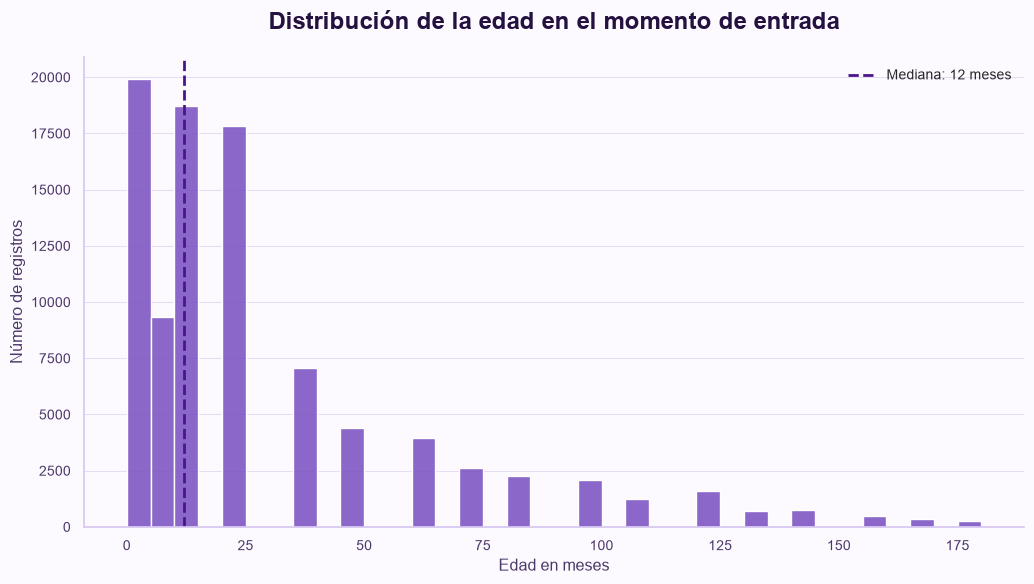

In [47]:
# Distribución de la edad en meses

age_plot = dogs_base[
    (dogs_base["age_months_intake"].notna()) &
    (dogs_base["age_months_intake"] <= 180)
].copy()

mediana_edad = dogs_base["age_months_intake"].median()

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

sns.histplot(
    data=age_plot,
    x="age_months_intake",
    bins=36,
    color="#7E57C2",
    edgecolor="white",
    alpha=0.9,
    ax=ax
)

ax.axvline(
    mediana_edad,
    color="#4A148C",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {mediana_edad:.0f} meses"
)

ax.set_title(
    "Distribución de la edad en el momento de entrada",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Edad en meses", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Número de registros", fontsize=11.5, color="#4B3768")

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(axis="y", linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.grid(axis="x", visible=False)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución de la edad en el momento de entrada muestra una clara concentración en perros jóvenes. La mediana se sitúa en 12 meses, lo que indica que la mitad de los registros corresponde a perros de un año o menos.

A partir de edades más avanzadas, la frecuencia disminuye progresivamente, generando una distribución asimétrica hacia la derecha. Este patrón sugiere que la edad puede ser una variable relevante para el modelo predictivo, ya que el perfil de edad podría estar relacionado con distintos tiempos de estancia en el refugio.

### 8.3. Creación de grupos de edad

Además de conservar la edad en meses como variable numérica, se crea una variable categórica de grupo de edad. Esta transformación facilita la interpretación de los perfiles de perros y permite analizar si determinados grupos, como cachorros, adultos o perros senior, presentan diferencias en el tiempo de estancia.

Los grupos definidos son:

- Cachorro: hasta 6 meses.
- Joven: más de 6 meses y hasta 24 meses.
- Adulto: más de 24 meses y hasta 84 meses.
- Senior: más de 84 meses.

In [48]:
# Creación de grupos de edad

dogs_base["age_group"] = dogs_base["age_months_intake"].apply(asignar_grupo_edad)

age_group_summary = (
    dogs_base["age_group"]
    .value_counts()
    .reset_index()
)

age_group_summary.columns = ["grupo_edad", "registros"]
age_group_summary["porcentaje"] = (
    age_group_summary["registros"] / age_group_summary["registros"].sum() * 100
).round(2)

display(age_group_summary)

,grupo_edad,registros,porcentaje
0,Joven,41581,44.33
1,Cachorro,24195,25.79
2,Adulto,20286,21.63
3,Senior,7733,8.24
4,Sin información,8,0.01


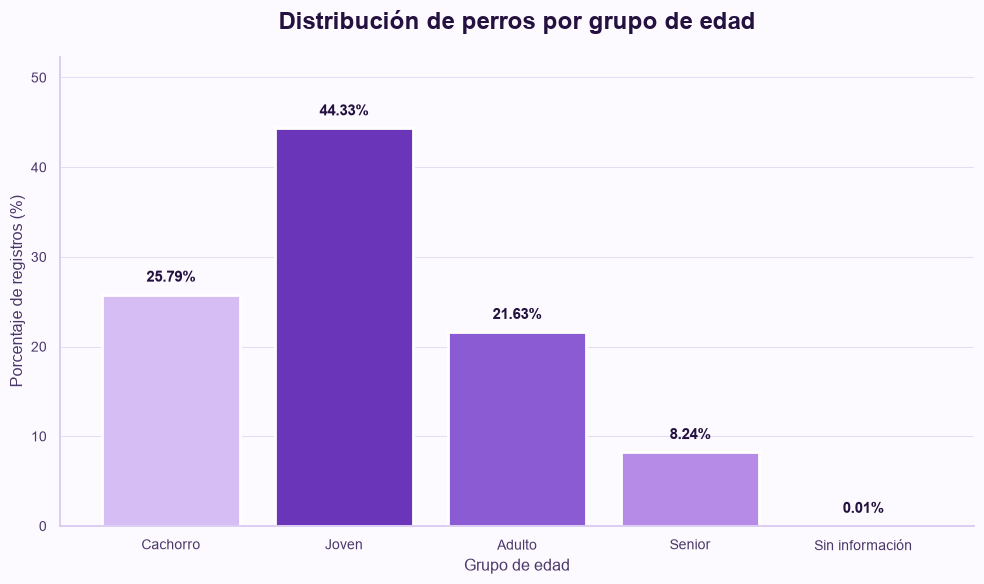

In [49]:
# Visualización de grupos de edad

orden_grupos = ["Cachorro", "Joven", "Adulto", "Senior", "Sin información"]

age_group_plot = age_group_summary.copy()
age_group_plot["grupo_edad"] = pd.Categorical(
    age_group_plot["grupo_edad"],
    categories=orden_grupos,
    ordered=True
)

age_group_plot = age_group_plot.sort_values("grupo_edad")

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#D6BDF4", "#6A35B8", "#8A5BD3", "#B68BE8", "#E8DAFA"]

bars = ax.bar(
    age_group_plot["grupo_edad"],
    age_group_plot["porcentaje"],
    color=colors[:len(age_group_plot)],
    edgecolor="white",
    linewidth=2
)

ax.set_title(
    "Distribución de perros por grupo de edad",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Grupo de edad", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")

max_value = age_group_plot["porcentaje"].max()
ax.set_ylim(0, max_value * 1.18)

for bar, value in zip(bars, age_group_plot["porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.025,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La distribución por grupos de edad muestra que el grupo más frecuente es el de perros jóvenes, con el 44,33 % de los registros, seguido de los cachorros, con el 25,79 %. Los perros adultos representan el 21,63 %, mientras que los perros senior suponen el 8,24 %.

Este resultado confirma que el dataset está compuesto mayoritariamente por perros de corta edad. La creación de grupos de edad permitirá incorporar esta información al modelo de una forma más interpretable que la edad numérica original.

### 8.4. Separación de sexo y estado reproductivo

La variable `sex_upon_intake` combina dos tipos de información: el sexo del perro y su estado reproductivo en el momento de entrada. Para facilitar la interpretación y preparar mejor los datos para la modelización, se separa esta variable en dos nuevas variables:

- `sex`: sexo del perro.
- `sterilized_intake`: estado reproductivo en el momento de entrada.

Esta transformación permite conservar la información original, pero representarla de una forma más estructurada y útil para el análisis posterior.

In [50]:
# Separación de sexo y estado reproductivo

dogs_base["sex"] = dogs_base["sex_upon_intake"].apply(extraer_sexo)
dogs_base["sterilized_intake"] = dogs_base["sex_upon_intake"].apply(extraer_estado_reproductivo)

sex_reproductive_summary = pd.DataFrame({
    "variable": ["sex", "sterilized_intake"],
    "categorias_unicas": [
        dogs_base["sex"].nunique(),
        dogs_base["sterilized_intake"].nunique()
    ],
    "valores_nulos": [
        dogs_base["sex"].isna().sum(),
        dogs_base["sterilized_intake"].isna().sum()
    ]
})

display(sex_reproductive_summary)

print("Distribución de sex:")
display(dogs_base["sex"].value_counts(normalize=True).mul(100).round(2))

print("\nDistribución de sterilized_intake:")
display(dogs_base["sterilized_intake"].value_counts(normalize=True).mul(100).round(2))

,variable,categorias_unicas,valores_nulos
0,sex,3,0
1,sterilized_intake,3,0


Distribución de sex:


sex
Macho          53.14
Hembra         46.10
Desconocido     0.75
Name: proportion, dtype: float64


Distribución de sterilized_intake:


sterilized_intake
No esterilizado    65.91
Esterilizado       33.33
Desconocido         0.75
Name: proportion, dtype: float64

La variable original `sex_upon_intake` se ha separado correctamente en dos variables nuevas: `sex` y `sterilized_intake`. Esta transformación permite distinguir entre el sexo del perro y su estado reproductivo en el momento de entrada.

La distribución resultante muestra una proporción ligeramente superior de machos, con el 53,14 % de los registros, frente al 46,11 % de hembras. Asimismo, el 65,91 % de los perros figura como no esterilizado en el momento de entrada, frente al 33,34 % que aparece como esterilizado.

Esta separación facilita la interpretación de las variables y permitirá evaluar de forma más clara si el sexo o el estado reproductivo están relacionados con el riesgo de larga estancia.

### 8.5. Simplificación de la variable raza

La variable `breed_intake` contiene un número muy elevado de categorías, lo que dificulta su uso directo en modelos predictivos. Para reducir esta complejidad y conservar información relevante, se crean variables simplificadas relacionadas con la raza.

En primer lugar, se identifica si el perro aparece registrado como raza mixta o cruce. Posteriormente, se extrae una raza principal a partir del valor original, lo que permitirá agrupar categorías minoritarias y mejorar la interpretabilidad del modelo.

In [51]:
# Simplificación inicial de la variable raza

dogs_base["is_mixed_breed"] = dogs_base["breed_intake"].apply(identificar_raza_mixta)
dogs_base["main_breed"] = dogs_base["breed_intake"].apply(extraer_raza_principal)

breed_features_summary = pd.DataFrame({
    "variable": ["is_mixed_breed", "main_breed"],
    "categorias_unicas": [
        dogs_base["is_mixed_breed"].nunique(),
        dogs_base["main_breed"].nunique()
    ],
    "valores_nulos": [
        dogs_base["is_mixed_breed"].isna().sum(),
        dogs_base["main_breed"].isna().sum()
    ]
})

display(breed_features_summary)

print("Distribución de raza mixta:")
display(dogs_base["is_mixed_breed"].value_counts(normalize=True).mul(100).round(2))

print("\nRazas principales más frecuentes:")
display(dogs_base["main_breed"].value_counts().head(15))

,variable,categorias_unicas,valores_nulos
0,is_mixed_breed,2,0
1,main_breed,211,0


Distribución de raza mixta:


is_mixed_breed
Raza mixta       79.4
Raza no mixta    20.6
Name: proportion, dtype: float64


Razas principales más frecuentes:


main_breed
Pit Bull                 14344
Labrador Retriever       13404
Chihuahua Shorthair      10045
German Shepherd           6952
Australian Cattle Dog     3134
Siberian Husky            2112
Dachshund                 2098
Boxer                     1851
Border Collie             1779
Great Pyrenees            1561
Miniature Poodle          1381
Australian Shepherd       1279
Catahoula                 1254
Beagle                    1214
Yorkshire Terrier         1159
Name: count, dtype: int64

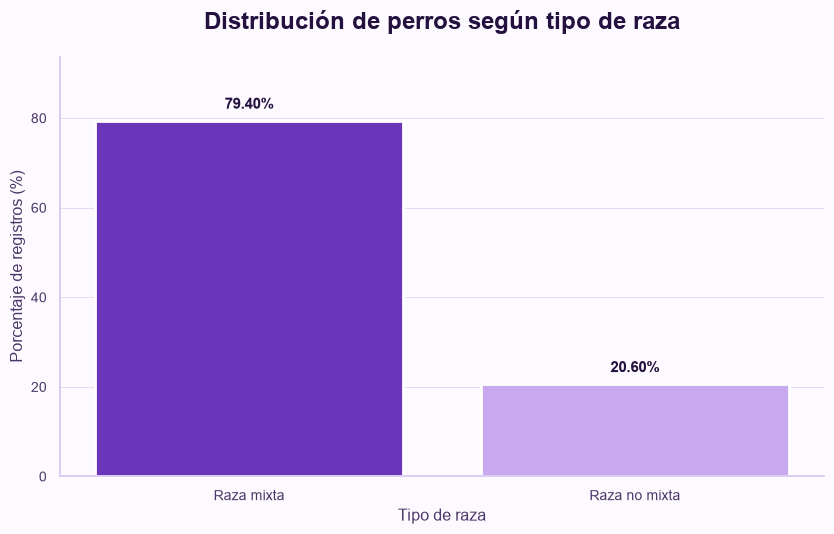

In [52]:
# Visualización de perros de raza mixta y no mixta

mixed_breed_summary = (
    dogs_base["is_mixed_breed"]
    .value_counts()
    .reset_index()
)

mixed_breed_summary.columns = ["tipo_raza", "registros"]
mixed_breed_summary["porcentaje"] = (
    mixed_breed_summary["registros"] / mixed_breed_summary["registros"].sum() * 100
).round(2)

mixed_breed_plot = mixed_breed_summary.sort_values("porcentaje", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#6A35B8", "#C8A9F0"]

bars = ax.bar(
    mixed_breed_plot["tipo_raza"],
    mixed_breed_plot["porcentaje"],
    color=colors,
    edgecolor="white",
    linewidth=2
)

ax.set_title(
    "Distribución de perros según tipo de raza",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Tipo de raza", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")

max_value = mixed_breed_plot["porcentaje"].max()
ax.set_ylim(0, max_value * 1.18)

for bar, value in zip(bars, mixed_breed_plot["porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.025,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La simplificación de la variable de raza muestra que el 79,40 % de los perros aparece registrado como raza mixta o cruce, frente al 20,60 % que figura como raza no mixta.

Este resultado es relevante para la modelización, ya que permite transformar una variable originalmente muy fragmentada en una característica sencilla e interpretable. Además, la variable `main_breed` reduce la cardinalidad de la raza original, pasando de 2.650 categorías a 211 razas principales.

### 8.6. Agrupación de razas principales

Aunque la extracción de `main_breed` reduce considerablemente la cardinalidad de la variable original de raza, todavía existen 211 razas principales diferentes. Para preparar esta variable de cara a la modelización, se crea una versión agrupada que conserva las razas más frecuentes y agrupa el resto bajo la categoría `Otras razas`.

Esta estrategia permite mantener información relevante sobre las razas más representadas, reduciendo al mismo tiempo la complejidad del dataset y el riesgo de sobreajuste.

In [53]:
# Agrupación de razas principales frecuentes

top_main_breeds = (
    dogs_base["main_breed"]
    .value_counts()
    .head(15)
    .index
)

dogs_base["main_breed_grouped"] = np.where(
    dogs_base["main_breed"].isin(top_main_breeds),
    dogs_base["main_breed"],
    "Otras razas"
)

main_breed_grouped_summary = (
    dogs_base["main_breed_grouped"]
    .value_counts()
    .reset_index()
)

main_breed_grouped_summary.columns = ["raza_agrupada", "registros"]
main_breed_grouped_summary["porcentaje"] = (
    main_breed_grouped_summary["registros"] / main_breed_grouped_summary["registros"].sum() * 100
).round(2)

display(main_breed_grouped_summary)

,raza_agrupada,registros,porcentaje
0,Otras razas,30236,32.23
1,Pit Bull,14344,15.29
2,Labrador Retriever,13404,14.29
3,Chihuahua Shorthair,10045,10.71
4,German Shepherd,6952,7.41
5,Australian Cattle Dog,3134,3.34
6,Siberian Husky,2112,2.25
7,Dachshund,2098,2.24
8,Boxer,1851,1.97
9,Border Collie,1779,1.90


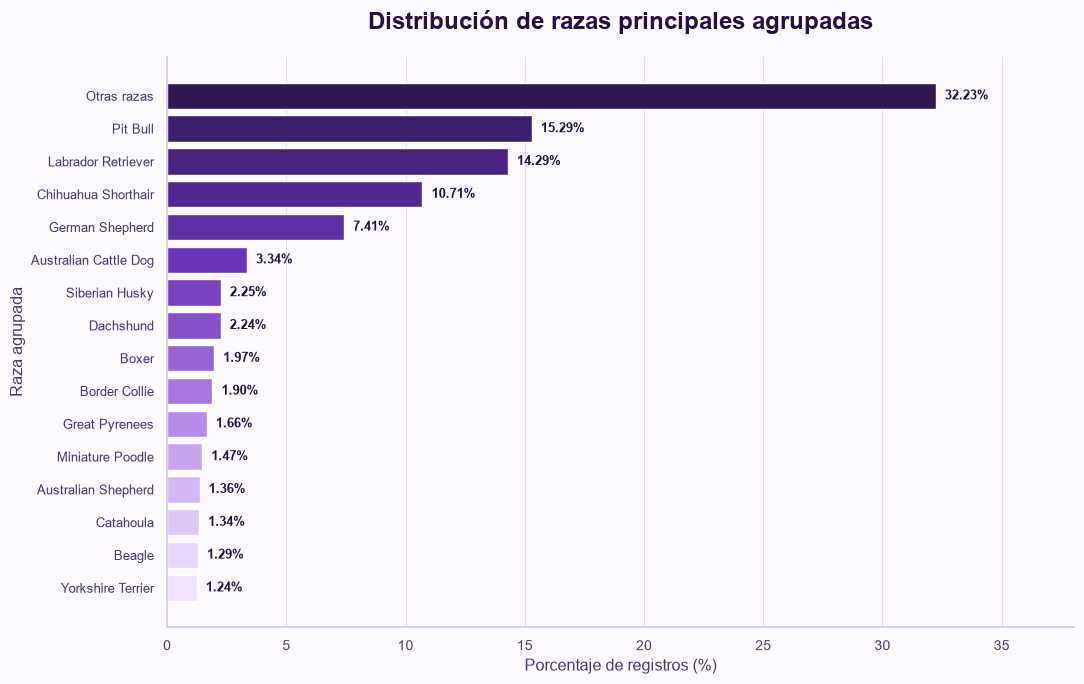

In [54]:
# Visualización de razas principales agrupadas

main_breed_grouped_plot = main_breed_grouped_summary.copy()
main_breed_grouped_plot = main_breed_grouped_plot.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = [
    "#EFE4FC", "#E6D8FA", "#DCC8F6", "#D1B8F2", "#C5A6EC",
    "#B68BE8", "#A678DE", "#9564D4", "#8551CA", "#7743BF",
    "#6A35B8", "#5E2EA5", "#522991", "#48237F", "#3E1E6D",
    "#2F174F"
]

bars = ax.barh(
    main_breed_grouped_plot["raza_agrupada"],
    main_breed_grouped_plot["porcentaje"],
    color=colors[:len(main_breed_grouped_plot)]
)

ax.set_title(
    "Distribución de razas principales agrupadas",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Raza agrupada", fontsize=11.5, color="#4B3768")

max_value = main_breed_grouped_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, main_breed_grouped_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=9.5)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La agrupación de razas principales permite reducir la complejidad de la variable manteniendo información relevante sobre las razas más representadas. La categoría `Otras razas` concentra el 32,23 % de los registros, lo que refleja la elevada diversidad de razas minoritarias presentes en el dataset.

Entre las razas conservadas individualmente destacan Pit Bull, Labrador Retriever y Chihuahua Shorthair, que representan el 15,29 %, 14,29 % y 10,71 % de los registros, respectivamente. Esta nueva variable agrupada será más adecuada para la fase de modelización que la variable original de raza, ya que reduce la cardinalidad y mejora la interpretabilidad.

### 8.7. Simplificación de la variable color

La variable `color_intake` también presenta una cardinalidad elevada, con múltiples combinaciones de colores registradas. Para reducir esta complejidad, se crea una variable simplificada que extrae el color principal a partir del valor original.

Esta transformación permite conservar parte de la información del color del perro, pero representándola de una forma más sencilla y adecuada para la modelización.

In [55]:
# Simplificación inicial de la variable color

dogs_base["main_color"] = dogs_base["color_intake"].apply(extraer_color_principal)

color_features_summary = pd.DataFrame({
    "variable": ["color_intake", "main_color"],
    "categorias_unicas": [
        dogs_base["color_intake"].nunique(),
        dogs_base["main_color"].nunique()
    ],
    "valores_nulos": [
        dogs_base["color_intake"].isna().sum(),
        dogs_base["main_color"].isna().sum()
    ]
})

display(color_features_summary)

print("Colores principales más frecuentes:")
display(dogs_base["main_color"].value_counts().head(15))

,variable,categorias_unicas,valores_nulos
0,color_intake,400,0
1,main_color,37,0


Colores principales más frecuentes:


main_color
Black            24496
White            16970
Brown            12964
Tan              11155
Brown Brindle     4471
Tricolor          3890
Blue              3755
Red               3734
Chocolate         2200
Cream             1399
Fawn              1241
Sable             1189
Gray              1097
Yellow             959
Buff               885
Name: count, dtype: int64

Las funciones `extraer_raza_principal` y `extraer_color_principal`, definidas en los apartados 8.5 y 8.7, obtienen `main_breed` y `main_color` conservando únicamente el primer término registrado antes de la barra (`/`). Esta simplificación es razonable para reducir la cardinalidad de ambas variables, pero descarta la segunda raza o el segundo color en los registros que combinan dos valores (por ejemplo, `Labrador Retriever/Pit Bull` se reduce a `Labrador Retriever`). A continuación se cuantifica cuántos registros del dataset base se ven afectados por esta simplificación, con el fin de dimensionar la pérdida de información y valorar posibles alternativas.

In [56]:
# Cuantificación de la información descartada al simplificar raza y color

n_registros = dogs_base.shape[0]

registros_raza_con_segundo_termino = dogs_base["breed_intake"].str.contains("/", na=False).sum()
registros_color_con_segundo_termino = dogs_base["color_intake"].str.contains("/", na=False).sum()

resumen_perdida_informacion = pd.DataFrame({
    "variable": ["breed_intake -> main_breed", "color_intake -> main_color"],
    "registros_totales": [n_registros, n_registros],
    "registros_con_segundo_termino_descartado": [
        registros_raza_con_segundo_termino,
        registros_color_con_segundo_termino
    ],
    "porcentaje_afectado": [
        round(registros_raza_con_segundo_termino / n_registros * 100, 2),
        round(registros_color_con_segundo_termino / n_registros * 100, 2)
    ]
})

display(resumen_perdida_informacion)

print("Ejemplos de raza con segundo término descartado por 'main_breed':")
display(
    dogs_base.loc[dogs_base["breed_intake"].str.contains("/", na=False), ["breed_intake", "main_breed"]]
    .drop_duplicates(subset="breed_intake")
    .head(5)
)

print("\nEjemplos de color con segundo término descartado por 'main_color':")
display(
    dogs_base.loc[dogs_base["color_intake"].str.contains("/", na=False), ["color_intake", "main_color"]]
    .drop_duplicates(subset="color_intake")
    .head(5)
)

,variable,registros_totales,registros_con_segundo_termino_descartado,porcentaje_afectado
0,breed_intake -> main_breed,93803,15369,16.38
1,color_intake -> main_color,93803,63059,67.22


Ejemplos de raza con segundo término descartado por 'main_breed':


,breed_intake,main_breed
0,Border Terrier/Border Collie,Border Terrier
7,Labrador Retriever/Chinese Sharpei,Labrador Retriever
12,Dachshund/Chihuahua Shorthair,Dachshund
15,Black/Tan Hound Mix,Black
22,Yorkshire Terrier/Miniature Poodle,Yorkshire Terrier



Ejemplos de color con segundo término descartado por 'main_color':


,color_intake,main_color
0,White/Tan,White
1,Blue/White,Blue
2,Black/White,Black
6,White/Tricolor,White
10,White/Black,White


La comprobación confirma que la pérdida de información es asimétrica entre ambas variables: una parte relevante de los registros presenta un segundo término en `breed_intake` que se descarta al construir `main_breed`, mientras que en `color_intake` la mayoría de los perros se registra con una combinación de dos colores (por ejemplo, `Black/White`). Esta diferencia indica que la simplificación aplicada a la raza afecta a una minoría relevante de registros, mientras que en el color descarta información en una proporción mucho más amplia del dataset base.

Esta magnitud confirma que la simplificación, aunque necesaria para controlar la cardinalidad de ambas variables, no es inocua: `main_breed` y `main_color` deben interpretarse como la raza y el color dominantes o de referencia, no como una representación completa del fenotipo del animal. A continuación se implementan `has_secondary_breed`/`secondary_breed` y `has_secondary_color`/`secondary_color` como nuevas variables complementarias que recogen esta información sin sustituir a `main_breed`, `main_breed_grouped`, `main_color` ni `main_color_grouped`, que se mantienen como las variables de referencia principales.

### 8.8. Agrupación de colores principales

Aunque la extracción de `main_color` reduce considerablemente la cardinalidad de la variable original de color, todavía existen 37 colores principales diferentes. Para facilitar su uso en la fase de modelización, se crea una versión agrupada que conserva los colores más frecuentes y agrupa el resto bajo la categoría `Otros colores`.

Esta transformación permite mantener la información más relevante del color del perro, reduciendo al mismo tiempo la complejidad del dataset.

In [57]:
# Agrupación de colores principales frecuentes

top_main_colors = (
    dogs_base["main_color"]
    .value_counts()
    .head(10)
    .index
)

dogs_base["main_color_grouped"] = np.where(
    dogs_base["main_color"].isin(top_main_colors),
    dogs_base["main_color"],
    "Otros colores"
)

main_color_grouped_summary = (
    dogs_base["main_color_grouped"]
    .value_counts()
    .reset_index()
)

main_color_grouped_summary.columns = ["color_agrupado", "registros"]
main_color_grouped_summary["porcentaje"] = (
    main_color_grouped_summary["registros"] / main_color_grouped_summary["registros"].sum() * 100
).round(2)

display(main_color_grouped_summary)

,color_agrupado,registros,porcentaje
0,Black,24496,26.11
1,White,16970,18.09
2,Brown,12964,13.82
3,Tan,11155,11.89
4,Otros colores,8769,9.35
5,Brown Brindle,4471,4.77
6,Tricolor,3890,4.15
7,Blue,3755,4.00
8,Red,3734,3.98
9,Chocolate,2200,2.35


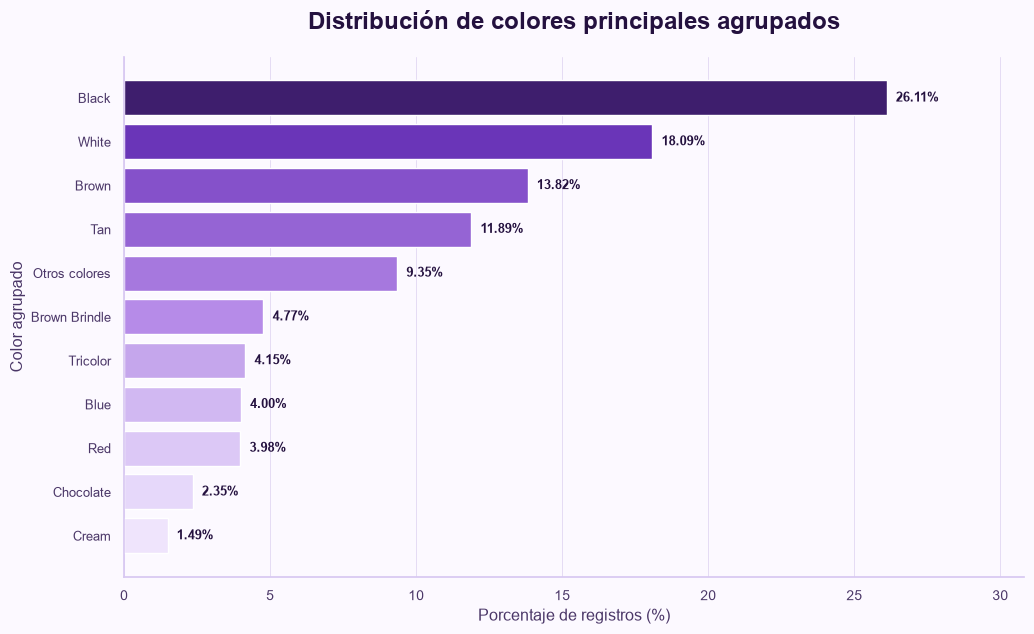

In [58]:
# Visualización de colores principales agrupados

main_color_grouped_plot = main_color_grouped_summary.copy()
main_color_grouped_plot = main_color_grouped_plot.sort_values("porcentaje", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = [
    "#EFE4FC", "#E6D8FA", "#DCC8F6", "#D1B8F2", "#C5A6EC",
    "#B68BE8", "#A678DE", "#9564D4", "#8551CA", "#6A35B8",
    "#3E1E6D"
]

bars = ax.barh(
    main_color_grouped_plot["color_agrupado"],
    main_color_grouped_plot["porcentaje"],
    color=colors[:len(main_color_grouped_plot)]
)

ax.set_title(
    "Distribución de colores principales agrupados",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Color agrupado", fontsize=11.5, color="#4B3768")

max_value = main_color_grouped_plot["porcentaje"].max()
ax.set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, main_color_grouped_plot["porcentaje"]):
    ax.text(
        value + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=9.5)

ax.grid(axis="y", visible=False)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La agrupación de colores principales permite reducir la complejidad de la variable original de color manteniendo los colores más representativos del dataset. Los colores principales más frecuentes son `Black`, `White`, `Brown` y `Tan`, que concentran una parte importante de los registros.

La categoría `Otros colores` agrupa combinaciones o colores menos frecuentes, permitiendo conservar la información general sin introducir una cardinalidad excesiva en la fase de modelización. Esta variable agrupada será más adecuada para su uso posterior en modelos predictivos.

### 8.9. Indicadores de raza y color secundarios

Se incorporan dos nuevas variables sencillas que recogen, sin sustituir a `main_breed` ni a `main_color`, la información descartada al quedarse únicamente con el primer término registrado en `breed_intake` y `color_intake` (apartado anterior).

`has_secondary_breed` y `has_secondary_color` son indicadores binarios que señalan si el registro original incluye una segunda raza o un segundo color. `secondary_breed` y `secondary_color` recogen, cuando existe, ese segundo término. Las cuatro variables están disponibles en el momento de entrada del perro al refugio y no generan fuga de información.

In [59]:
# Indicadores de raza y color secundarios

dogs_base["has_secondary_breed"] = dogs_base["breed_intake"].str.contains("/", na=False).astype(int)
dogs_base["secondary_breed"] = (
    dogs_base["breed_intake"]
    .str.split("/", n=1)
    .str[1]
    .str.strip()
)

dogs_base["has_secondary_color"] = dogs_base["color_intake"].str.contains("/", na=False).astype(int)
dogs_base["secondary_color"] = (
    dogs_base["color_intake"]
    .str.split("/", n=1)
    .str[1]
    .str.strip()
)

resumen_variables_secundarias = pd.DataFrame({
    "variable": ["has_secondary_breed", "has_secondary_color"],
    "registros_con_valor_1": [
        dogs_base["has_secondary_breed"].sum(),
        dogs_base["has_secondary_color"].sum()
    ],
    "porcentaje": [
        round(dogs_base["has_secondary_breed"].mean() * 100, 2),
        round(dogs_base["has_secondary_color"].mean() * 100, 2)
    ]
})

display(resumen_variables_secundarias)

,variable,registros_con_valor_1,porcentaje
0,has_secondary_breed,15369,16.38
1,has_secondary_color,63059,67.22


### 8.10. Indicador de nombre registrado en la entrada

Se añade un indicador categórico, `has_name_intake`, que señala si el perro tiene un nombre registrado en el momento de entrada. No se utiliza el nombre en sí (`name_intake`) como variable predictora -no aporta información generalizable y podría actuar como un identificador encubierto de cada animal-, pero la propia ausencia de nombre sí es una característica disponible en el momento de entrada que podría estar relacionada, por ejemplo, con animales callejeros sin dueño conocido.

In [60]:
# Indicador de nombre registrado en la entrada

dogs_base["has_name_intake"] = np.where(
    dogs_base["name_intake"].isna(),
    "Sin nombre registrado",
    "Con nombre registrado"
)

print("Distribución de has_name_intake:")
display(dogs_base["has_name_intake"].value_counts(normalize=True).mul(100).round(2))

Distribución de has_name_intake:


has_name_intake
Con nombre registrado    84.33
Sin nombre registrado    15.67
Name: proportion, dtype: float64

### 8.11. Historial de entradas previas del mismo perro

Como se ha comprobado en apartados anteriores, un mismo perro puede aparecer varias veces en el refugio a lo largo del periodo analizado. Esta circunstancia permite construir variables de historial, siempre que se calculen utilizando exclusivamente información anterior a la entrada actual.

Se crean tres variables: `previous_intake_count` (número de entradas previas del mismo perro), `is_repeat_intake` (indicador binario de si existe alguna entrada previa) y `days_since_previous_intake` (días transcurridos desde la entrada inmediatamente anterior, si existe). Para calcularlas correctamente, el dataset base se ordena primero por `animal_id` y `intake_datetime`, de forma que ninguna de estas variables incorpore información de entradas futuras ni del desenlace de la estancia actual. `days_since_previous_intake` queda sin informar (nulo) para la primera entrada registrada de cada perro, ya que en ese caso no existe una entrada previa de la que calcular la diferencia.

In [61]:
# Historial de entradas previas del mismo perro

dogs_base = dogs_base.sort_values(["animal_id", "intake_datetime"]).reset_index(drop=True)

dogs_base["previous_intake_count"] = dogs_base.groupby("animal_id").cumcount()
dogs_base["is_repeat_intake"] = (dogs_base["previous_intake_count"] > 0).astype(int)

fecha_entrada_previa = dogs_base.groupby("animal_id")["intake_datetime"].shift(1)
dogs_base["days_since_previous_intake"] = (
    dogs_base["intake_datetime"] - fecha_entrada_previa
).dt.total_seconds() / (60 * 60 * 24)

resumen_historial_entradas = pd.DataFrame({
    "indicador": [
        "Entradas con alguna entrada previa (is_repeat_intake = 1)",
        "Porcentaje sobre el dataset base",
        "Máximo de entradas previas registradas para un mismo perro"
    ],
    "valor": [
        dogs_base["is_repeat_intake"].sum(),
        round(dogs_base["is_repeat_intake"].mean() * 100, 2),
        dogs_base["previous_intake_count"].max()
    ]
})

display(resumen_historial_entradas)

,indicador,valor
0,Entradas con alguna entrada previa (is_repeat_...,14248.00
1,Porcentaje sobre el dataset base,15.19
2,Máximo de entradas previas registradas para un...,32.00


### 8.12. Variables temporales de la entrada

Se incorporan variables derivadas de `intake_datetime`: `intake_month`, `intake_dayofweek`, `intake_hour`, `intake_is_weekend` e `intake_season`. Todas ellas se construyen exclusivamente a partir de la fecha de entrada, por lo que están disponibles en el momento en que el perro llega al refugio y no incorporan ninguna información sobre el desenlace posterior.

In [62]:
# Variables temporales de la entrada

dogs_base["intake_month"] = dogs_base["intake_datetime"].dt.month
dogs_base["intake_dayofweek"] = dogs_base["intake_datetime"].dt.dayofweek
dogs_base["intake_hour"] = dogs_base["intake_datetime"].dt.hour
dogs_base["intake_is_weekend"] = dogs_base["intake_dayofweek"].isin([5, 6]).astype(int)


def asignar_estacion(mes):
    if pd.isna(mes):
        return "Sin información"
    elif mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"


dogs_base["intake_season"] = dogs_base["intake_month"].apply(asignar_estacion)

variables_temporales_entrada = [
    "intake_month", "intake_dayofweek", "intake_hour", "intake_is_weekend", "intake_season"
]

display(dogs_base[variables_temporales_entrada].head())

,intake_month,intake_dayofweek,intake_hour,intake_is_weekend,intake_season
0,3,4,14,0,Primavera
1,12,4,10,0,Invierno
2,4,2,15,0,Primavera
3,11,5,9,1,Otoño
4,11,5,14,1,Otoño


### 8.13. Complejidad de raza y color registradas

Como complemento a `has_secondary_breed` y `has_secondary_color` (apartado 8.9), se añaden `breed_num_terms` y `color_num_terms`, que cuentan cuántos términos incluye `breed_intake`/`color_intake` (uno si no hay ningún `/`, dos si hay un segundo término, etc.). Mientras que los indicadores del apartado 8.9 son binarios, estas dos variables permiten distinguir también los casos, poco frecuentes, con más de dos términos registrados.

In [63]:
# Complejidad de raza y color registradas

dogs_base["breed_num_terms"] = dogs_base["breed_intake"].fillna("").str.count("/") + 1
dogs_base["color_num_terms"] = dogs_base["color_intake"].fillna("").str.count("/") + 1

display(dogs_base[["breed_num_terms", "color_num_terms"]].describe())

,breed_num_terms,color_num_terms
count,93803.000000,93803.000000
mean,1.164451,1.672249
std,0.372322,0.469396
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,3.000000,2.000000


### 8.14. Agrupación de la localización de hallazgo

`found_location` recoge, en texto libre, el lugar donde fue encontrado el perro y presenta una cardinalidad muy elevada (direcciones concretas, intersecciones, etc.). Se crea `found_location_grouped`, que agrupa esta información en cuatro categorías -`Austin`, `Travis`, `Outside Jurisdiction` y `Otra localización`- a partir de la presencia de esas cadenas de texto en el valor original, conservando `found_location` como variable de referencia sin agrupar.

In [64]:
# Agrupación de la localización de hallazgo

def agrupar_localizacion(valor):
    if pd.isna(valor):
        return "Sin información"

    texto = str(valor)

    if "Austin (TX)" in texto:
        return "Austin"
    elif "Travis (TX)" in texto:
        return "Travis"
    elif "Outside Jurisdiction" in texto:
        return "Outside Jurisdiction"
    else:
        return "Otra localización"


dogs_base["found_location_grouped"] = dogs_base["found_location"].apply(agrupar_localizacion)

print("Distribución de found_location_grouped:")
display(dogs_base["found_location_grouped"].value_counts(normalize=True).mul(100).round(2))

Distribución de found_location_grouped:


found_location_grouped
Austin                  79.01
Travis                  13.05
Otra localización        6.32
Outside Jurisdiction     1.62
Name: proportion, dtype: float64

### 8.15. Interacciones simples entre variables de entrada

Además de las variables individuales, se crean algunas interacciones categóricas sencillas entre características disponibles en el momento de entrada. Estas variables permiten representar combinaciones potencialmente relevantes, por ejemplo la relación entre edad y tipo de entrada, condición y tipo de entrada, raza agrupada y edad, o estación del año y condición inicial.

Estas interacciones no incorporan información posterior al ingreso del perro en el refugio. Su utilidad se evaluará posteriormente durante la modelización, manteniéndose únicamente si aportan rendimiento predictivo de forma justificada.


In [65]:
# Interacciones simples entre variables de entrada

def crear_interaccion(dataframe, columnas, nombre_nueva_variable):
    """Crea una interacción categórica simple a partir de columnas existentes."""
    if all(col in dataframe.columns for col in columnas):
        dataframe[nombre_nueva_variable] = (
            dataframe[columnas]
            .fillna("Sin información")
            .astype(str)
            .agg(" | ".join, axis=1)
        )


crear_interaccion(dogs_base, ["age_group", "intake_type"], "age_group_intake_type")
crear_interaccion(dogs_base, ["intake_condition", "intake_type"], "condition_intake_type")
crear_interaccion(dogs_base, ["main_breed_grouped", "age_group"], "breed_age_group")
crear_interaccion(dogs_base, ["intake_season", "intake_condition"], "season_condition")

variables_interaccion = [
    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition"
]

print("Variables de interacción creadas:")
display(dogs_base[variables_interaccion].head())


Variables de interacción creadas:


,age_group_intake_type,condition_intake_type,breed_age_group,season_condition
0,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Primavera | Normal
1,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Invierno | Normal
2,Senior | Owner Surrender,Normal | Owner Surrender,Dachshund | Senior,Primavera | Normal
3,Senior | Public Assist,Injured | Public Assist,Otras razas | Senior,Otoño | Injured
4,Senior | Stray,Aged | Stray,Labrador Retriever | Senior,Otoño | Aged


### 8.16. Historial enriquecido del perro

Se amplía el historial del animal con variables que resumen información de estancias anteriores del mismo perro. Este bloque incluye el resultado de la estancia previa, la duración de la estancia previa y contadores acumulados de eventos anteriores, como largas estancias previas, entradas por entrega del propietario o entradas como animal callejero.

Estas variables son especialmente relevantes porque un perro con historial previo en el refugio puede presentar patrones distintos de permanencia. Para evitar fuga de información, se calculan siempre mediante desplazamiento temporal por `animal_id`, de forma que cada registro solo pueda utilizar información de estancias anteriores.


In [66]:
# Historial enriquecido del perro

dogs_base = dogs_base.sort_values(["animal_id", "intake_datetime"]).reset_index(drop=True)


def construir_historial_enriquecido(dataframe):
    """
    Construye variables históricas del perro utilizando solo estancias previas
    cuya salida ya era anterior a la entrada actual.
    """
    registros_historial = []
    datos_ordenados = dataframe.sort_values([
        "animal_id",
        "intake_datetime",
        "outcome_datetime"
    ]).copy()

    for _, grupo in datos_ordenados.groupby("animal_id", sort=False):
        historial = []

        for idx_row, fila in grupo.iterrows():
            fecha_entrada_actual = fila["intake_datetime"]

            historial_valido = [
                h for h in historial
                if (
                    pd.notna(h["outcome_datetime"])
                    and pd.notna(fecha_entrada_actual)
                    and h["outcome_datetime"] < fecha_entrada_actual
                )
            ]

            if historial_valido:
                ultimo = historial_valido[-1]

                previous_outcome_type = (
                    ultimo["outcome_type"]
                    if pd.notna(ultimo["outcome_type"])
                    else "Sin información"
                )
                previous_stay_days = ultimo["stay_days_rounded"]

                previous_long_stay_count = float(
                    sum(
                        (h["stay_days"] > 30)
                        for h in historial_valido
                        if pd.notna(h["stay_days"])
                    )
                )

                previous_owner_surrender_count = float(
                    sum(h["intake_type"] == "Owner Surrender" for h in historial_valido)
                )

                previous_stray_count = float(
                    sum(h["intake_type"] == "Stray" for h in historial_valido)
                )

            else:
                previous_outcome_type = "Sin historial"
                previous_stay_days = np.nan
                previous_long_stay_count = 0.0
                previous_owner_surrender_count = 0.0
                previous_stray_count = 0.0

            registros_historial.append({
                "index": idx_row,
                "previous_outcome_type": previous_outcome_type,
                "previous_stay_days": previous_stay_days,
                "previous_long_stay_count": previous_long_stay_count,
                "previous_owner_surrender_count": previous_owner_surrender_count,
                "previous_stray_count": previous_stray_count
            })

            historial.append({
                "outcome_datetime": fila["outcome_datetime"],
                "outcome_type": fila["outcome_type"],
                "stay_days_rounded": fila["stay_days_rounded"],
                "stay_days": fila["stay_days"],
                "intake_type": fila["intake_type"]
            })

    historial_enriquecido = (
        pd.DataFrame(registros_historial)
        .set_index("index")
        .sort_index()
    )

    columnas_float32 = [
        "previous_long_stay_count",
        "previous_owner_surrender_count",
        "previous_stray_count"
    ]

    historial_enriquecido[columnas_float32] = historial_enriquecido[columnas_float32].astype(np.float32)

    return historial_enriquecido


historial_enriquecido = construir_historial_enriquecido(dogs_base)

for columna in historial_enriquecido.columns:
    dogs_base[columna] = historial_enriquecido[columna]

columnas_historial_enriquecido = [
    "previous_outcome_type",
    "previous_stay_days",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count"
]

resumen_historial_enriquecido = pd.DataFrame({
    "variable": columnas_historial_enriquecido,
    "nulos": [dogs_base[col].isna().sum() for col in columnas_historial_enriquecido],
    "porcentaje_nulos": [
        round(dogs_base[col].isna().mean() * 100, 2)
        for col in columnas_historial_enriquecido
    ]
})

display(resumen_historial_enriquecido)


,variable,nulos,porcentaje_nulos
0,previous_outcome_type,0,0.00
1,previous_stay_days,79564,84.82
2,previous_long_stay_count,0,0.00
3,previous_owner_surrender_count,0,0.00
4,previous_stray_count,0,0.00


### 8.17. Variables de contexto temporal del refugio

Además de las características individuales del perro, se incorporan variables aproximadas de presión operativa del refugio en la fecha de entrada. Estas variables recogen el número de entradas, salidas y adopciones de perros en ventanas temporales anteriores, así como una estimación de perros activos en el refugio antes de la entrada actual.

El objetivo es capturar el contexto en el que se produce cada ingreso: momentos con mayor volumen de entradas o menor rotación pueden afectar indirectamente al riesgo de estancia prolongada. Todas estas variables se calculan con eventos anteriores a `intake_datetime`, excluyendo el evento actual y cualquier información futura.


In [67]:
# Variables de contexto temporal del refugio

def convertir_fecha_segura(serie):
    """Convierte una serie a datetime admitiendo distintos formatos."""
    try:
        return pd.to_datetime(serie, errors="coerce", format="mixed")
    except TypeError:
        return pd.to_datetime(serie, errors="coerce")


def contar_eventos_previos(fechas_referencia, fechas_eventos, dias):
    """
    Cuenta eventos ocurridos en una ventana anterior a cada fecha de referencia.
    El evento de la propia fecha no se incluye porque se usa side='left'.
    """
    resultado = np.zeros(len(fechas_referencia), dtype=np.float32)

    mascara_ref = fechas_referencia.notna()
    if mascara_ref.sum() == 0:
        return resultado

    eventos_validos = fechas_eventos.dropna().values.astype("datetime64[ns]")
    if len(eventos_validos) == 0:
        return resultado

    eventos_validos = np.sort(eventos_validos)
    referencias = fechas_referencia.loc[mascara_ref].values.astype("datetime64[ns]")

    fin = np.searchsorted(eventos_validos, referencias, side="left")
    inicio = np.searchsorted(
        eventos_validos,
        referencias - np.timedelta64(dias, "D"),
        side="left"
    )

    resultado[mascara_ref.to_numpy()] = (fin - inicio).astype(np.float32)
    return resultado


def contar_activos_aproximados(fechas_referencia, fechas_entrada, fechas_salida):
    """
    Estima la presión operativa del refugio como diferencia acumulada entre
    entradas y salidas previas a cada fecha de entrada.
    """
    resultado = np.zeros(len(fechas_referencia), dtype=np.float32)

    mascara_ref = fechas_referencia.notna()
    if mascara_ref.sum() == 0:
        return resultado

    entradas_validas = np.sort(fechas_entrada.dropna().values.astype("datetime64[ns]"))
    salidas_validas = np.sort(fechas_salida.dropna().values.astype("datetime64[ns]"))
    referencias = fechas_referencia.loc[mascara_ref].values.astype("datetime64[ns]")

    entradas_previas = np.searchsorted(entradas_validas, referencias, side="left")
    salidas_previas = np.searchsorted(salidas_validas, referencias, side="left")

    resultado[mascara_ref.to_numpy()] = np.maximum(
        entradas_previas - salidas_previas,
        0
    ).astype(np.float32)

    return resultado


fechas_entrada = convertir_fecha_segura(dogs_base["intake_datetime"])
fechas_salida = convertir_fecha_segura(dogs_base["outcome_datetime"])

dogs_base["n_intakes_dogs_last_7d"] = contar_eventos_previos(fechas_entrada, fechas_entrada, 7)
dogs_base["n_intakes_dogs_last_30d"] = contar_eventos_previos(fechas_entrada, fechas_entrada, 30)
dogs_base["n_outcomes_dogs_last_7d"] = contar_eventos_previos(fechas_entrada, fechas_salida, 7)
dogs_base["n_outcomes_dogs_last_30d"] = contar_eventos_previos(fechas_entrada, fechas_salida, 30)

fechas_adopcion = fechas_salida[dogs_base["outcome_type"].eq("Adoption")]

dogs_base["n_adoptions_dogs_last_30d"] = contar_eventos_previos(
    fechas_entrada,
    fechas_adopcion,
    30
)

dogs_base["estimated_active_dogs_at_intake"] = contar_activos_aproximados(
    fechas_entrada,
    fechas_entrada,
    fechas_salida
)

dogs_base["ratio_intakes_outcomes_30d"] = (
    dogs_base["n_intakes_dogs_last_30d"]
    / (dogs_base["n_outcomes_dogs_last_30d"] + 1)
).astype(np.float32)

columnas_contexto_refugio = [
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

display(dogs_base[columnas_contexto_refugio].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
n_intakes_dogs_last_7d,93803.0,171.41,48.47,0.0,138.00,183.0,204.00,351.0
n_intakes_dogs_last_30d,93803.0,730.23,191.73,0.0,584.00,800.0,864.00,1058.0
n_outcomes_dogs_last_7d,93803.0,169.98,48.70,0.0,136.00,181.0,203.00,314.0
n_outcomes_dogs_last_30d,93803.0,725.12,192.19,0.0,571.00,799.0,858.00,1065.0
n_adoptions_dogs_last_30d,93803.0,354.88,85.99,0.0,304.00,366.0,412.00,561.0
estimated_active_dogs_at_intake,93803.0,473.79,86.31,0.0,422.00,470.0,523.00,855.0
ratio_intakes_outcomes_30d,93803.0,1.02,0.24,0.0,0.96,1.0,1.04,10.0


### 8.18. Control de fuga temporal en variables históricas y de contexto

Las variables históricas y de contexto son útiles para la predicción, pero requieren un control específico porque algunas se derivan de eventos ocurridos a lo largo del tiempo. Por ello, se añade una comprobación explícita para confirmar que no se está incorporando información posterior a la fecha de entrada del perro.

El criterio aplicado es el siguiente: las variables del historial del perro solo pueden resumir estancias anteriores y las variables de contexto del refugio solo pueden contar eventos ocurridos antes de `intake_datetime`. Esta revisión refuerza que el dataset preparado sea compatible con un escenario operativo en el que la predicción se realizaría en el momento de la entrada.


In [68]:
# Control de fuga temporal en variables históricas y de contexto

controles_fuga_temporal_eda = []


def registrar_control_temporal(nombre_control, condicion, detalle):
    controles_fuga_temporal_eda.append({
        "control": nombre_control,
        "resultado": "OK" if bool(condicion) else "Revisar",
        "detalle": detalle
    })


dogs_control_temporal = dogs_base.sort_values([
    "animal_id",
    "intake_datetime",
    "outcome_datetime"
]).copy()

previous_outcome_datetime_control = (
    dogs_control_temporal.groupby("animal_id")["outcome_datetime"].shift(1)
)

registros_previos_no_cerrados = int(
    (
        previous_outcome_datetime_control.notna()
        & (previous_outcome_datetime_control >= dogs_control_temporal["intake_datetime"])
    ).sum()
)

registrar_control_temporal(
    "Historial enriquecido restringido a estancias previas cerradas",
    True,
    (
        "El cálculo de previous_outcome_type, previous_stay_days y contadores históricos "
        "solo utiliza estancias anteriores con outcome_datetime < intake_datetime. "
        f"Se detectaron {registros_previos_no_cerrados} casos en los que la estancia inmediatamente "
        "anterior no estaba cerrada antes de la nueva entrada; dichos casos quedan excluidos del historial."
    )
)

dias_previos_validos = dogs_base["days_since_previous_intake"].dropna().ge(0).all()

registrar_control_temporal(
    "Días desde entrada previa no negativos",
    dias_previos_validos,
    "days_since_previous_intake solo presenta valores nulos o mayores/iguales a cero."
)

columnas_conteo_contexto = [
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake"
]

conteos_no_negativos = dogs_base[columnas_conteo_contexto].ge(0).all().all()

registrar_control_temporal(
    "Variables de contexto no negativas",
    conteos_no_negativos,
    "Los conteos de entradas, salidas, adopciones y activos estimados no presentan valores negativos."
)

ratio_valido = dogs_base["ratio_intakes_outcomes_30d"].replace([np.inf, -np.inf], np.nan).notna().all()

registrar_control_temporal(
    "Ratio entradas/salidas calculable",
    ratio_valido,
    "ratio_intakes_outcomes_30d se calcula dividiendo por n_outcomes_dogs_last_30d + 1 para evitar divisiones por cero."
)

registrar_control_temporal(
    "Ventanas temporales anteriores a la entrada",
    True,
    "Las ventanas de 7 y 30 días se calculan con np.searchsorted(..., side='left'), excluyendo el evento actual y eventos posteriores."
)

controles_fuga_temporal_eda = pd.DataFrame(controles_fuga_temporal_eda)

display(controles_fuga_temporal_eda)

if not controles_fuga_temporal_eda["resultado"].eq("OK").all():
    raise ValueError("Algún control de fuga temporal requiere revisión antes de guardar el dataset.")


,control,resultado,detalle
0,Historial enriquecido restringido a estancias ...,OK,"El cálculo de previous_outcome_type, previous_..."
1,Días desde entrada previa no negativos,OK,days_since_previous_intake solo presenta valor...
2,Variables de contexto no negativas,OK,"Los conteos de entradas, salidas, adopciones y..."
3,Ratio entradas/salidas calculable,OK,ratio_intakes_outcomes_30d se calcula dividien...
4,Ventanas temporales anteriores a la entrada,OK,Las ventanas de 7 y 30 días se calculan con np...


## 9. Definición de la variable objetivo

Tras analizar la distribución del tiempo de estancia y comparar distintos umbrales de larga estancia, se define la variable objetivo principal del proyecto.

De acuerdo con el análisis previo, se utilizará el umbral de más de 30 días para identificar perros con riesgo de larga estancia. Este umbral permite representar un fenómeno minoritario, pero con suficiente volumen de casos positivos para entrenar modelos predictivos de forma robusta.

La variable objetivo se denominará `target_long_stay` y se construye directamente a partir de `stay_days` (y no de `stay_days_rounded`), de forma que la clasificación no dependa de ninguna convención de redondeo aplicada a la variable descriptiva. `stay_days_rounded` se conserva en el dataset con fines de interpretación y reporting, pero no se utiliza para definir el target. La variable objetivo tomará los siguientes valores:

- 1: perro con estancia superior a 30 días.
- 0: perro con estancia igual o inferior a 30 días.

In [69]:
# Definición de la variable objetivo principal

dogs_base["target_long_stay"] = (dogs_base["stay_days"] > 30).astype(int)

target_summary = (
    dogs_base["target_long_stay"]
    .value_counts()
    .reset_index()
)

target_summary.columns = ["target_long_stay", "registros"]
target_summary["categoria"] = target_summary["target_long_stay"].map({
    0: "Estancia no prolongada",
    1: "Larga estancia"
})

target_summary["porcentaje"] = (
    target_summary["registros"] / target_summary["registros"].sum() * 100
).round(2)

target_summary = target_summary[[
    "categoria",
    "target_long_stay",
    "registros",
    "porcentaje"
]]

display(target_summary)

,categoria,target_long_stay,registros,porcentaje
0,Estancia no prolongada,0,78714,83.91
1,Larga estancia,1,15089,16.09


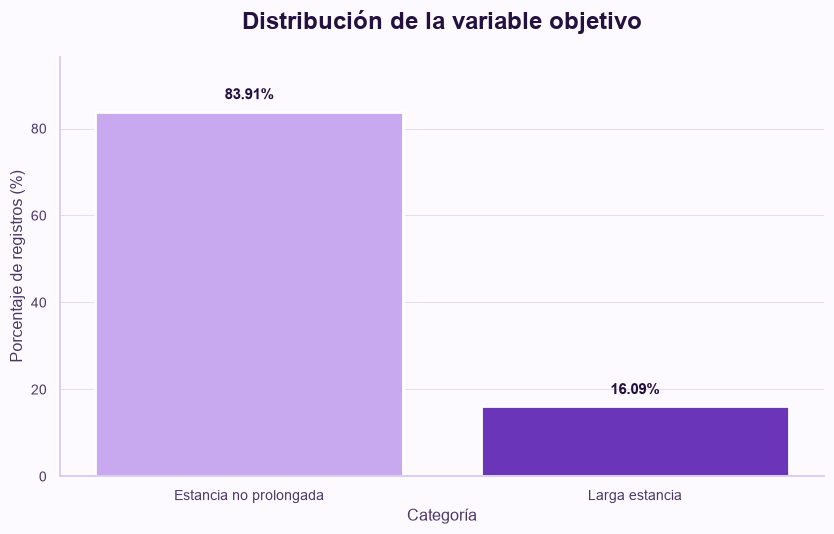

In [70]:
# Visualización de la variable objetivo

target_plot = target_summary.copy()
target_plot = target_plot.sort_values("target_long_stay")

fig, ax = plt.subplots(figsize=(8.5, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors = ["#C8A9F0", "#6A35B8"]

bars = ax.bar(
    target_plot["categoria"],
    target_plot["porcentaje"],
    color=colors,
    edgecolor="white",
    linewidth=2
)

ax.set_title(
    "Distribución de la variable objetivo",
    fontsize=17,
    fontweight="bold",
    color="#24113F",
    pad=20
)

ax.set_xlabel("Categoría", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Porcentaje de registros (%)", fontsize=11.5, color="#4B3768")

max_value = target_plot["porcentaje"].max()
ax.set_ylim(0, max_value * 1.15)

for bar, value in zip(bars, target_plot["porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.025,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.tick_params(axis="x", colors="#4B3768", labelsize=10)
ax.tick_params(axis="y", colors="#4B3768", labelsize=10)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color="#7E57C2"
)

ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

La variable objetivo `target_long_stay` presenta una distribución desbalanceada, aunque no extrema. El 83,91 % de los registros corresponde a perros con estancia no prolongada, mientras que el 16,09 % corresponde a perros con larga estancia.

Este resultado es coherente con el planteamiento del proyecto: la larga estancia representa un fenómeno minoritario dentro del refugio, pero con un volumen suficiente de casos positivos para entrenar modelos predictivos. En fases posteriores será necesario tener en cuenta este desbalance mediante métricas adecuadas, como recall, F1-score y ROC-AUC, y mediante estrategias de modelización adaptadas al problema.


Antes de avanzar hacia la selección final del dataset, resulta útil comprobar si algunas de las variables predictoras candidatas muestran una relación aparente con la variable objetivo. Este análisis bivariante no sustituye a la fase de modelización, pero permite anticipar que variables podrían aportar señal predictiva y orientar la interpretación de resultados posteriores. Se analiza la tasa de larga estancia (`target_long_stay`) según tres variables candidatas: grupo de edad, tipo de entrada y tipo de raza (mixta o no mixta).

### 9.1. Relación entre el grupo de edad y la variable objetivo

Se analiza la tasa de larga estancia según el grupo de edad del perro en el momento de entrada.

,age_group,registros,tasa_larga_estancia
1,Cachorro,24195,13.03
2,Joven,41581,17.43
0,Adulto,20286,17.94
3,Senior,7733,13.58
4,Sin información,8,12.50


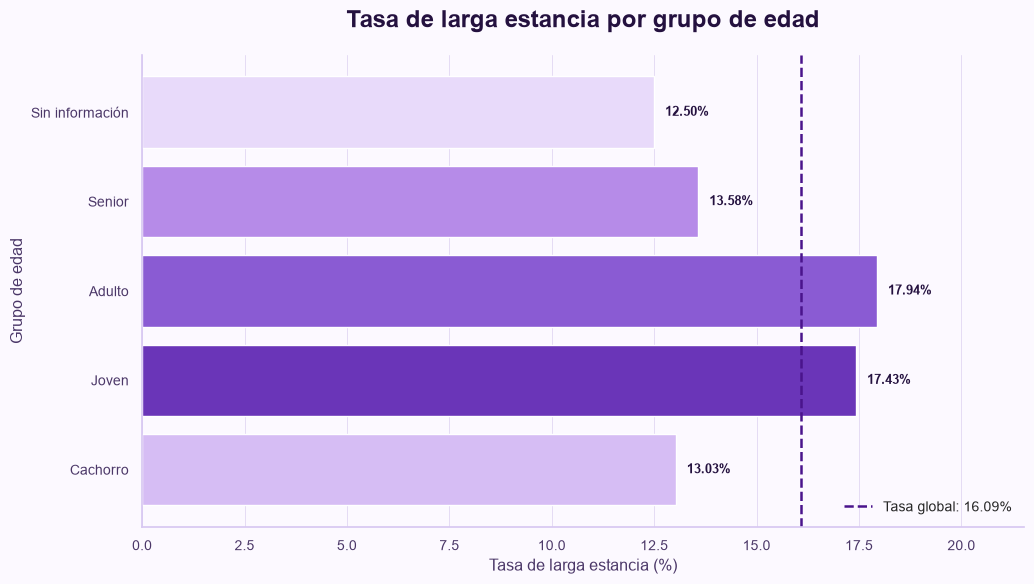

In [71]:
# Tasa de larga estancia por grupo de edad

target_by_age_group = (
    dogs_base
    .groupby("age_group")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)

target_by_age_group["tasa_larga_estancia"] = (target_by_age_group["tasa_larga_estancia"] * 100).round(2)

orden_grupos = ["Cachorro", "Joven", "Adulto", "Senior", "Sin información"]
target_by_age_group["age_group"] = pd.Categorical(
    target_by_age_group["age_group"],
    categories=orden_grupos,
    ordered=True
)
target_by_age_group = target_by_age_group.sort_values("age_group")

display(target_by_age_group)

tasa_global = dogs_base["target_long_stay"].mean() * 100

plot_barh_estilo_invisible_dogs(
    categorias=target_by_age_group["age_group"].astype(str),
    valores=target_by_age_group["tasa_larga_estancia"],
    titulo="Tasa de larga estancia por grupo de edad",
    xlabel="Tasa de larga estancia (%)",
    ylabel="Grupo de edad",
    colors=["#D6BDF4", "#6A35B8", "#8A5BD3", "#B68BE8", "#E8DAFA"][:len(target_by_age_group)],
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%"
)

La tasa de larga estancia varía según el grupo de edad. Los perros adultos y jóvenes presentan las tasas más altas, con un 17,94 % y un 17,43 % respectivamente, ambas por encima de la tasa global del 16,09 %. En cambio, los cachorros y los perros senior presentan tasas claramente inferiores, del 13,03 % y el 13,59 %.

Este resultado es coherente con la dinámica habitual de adopción en refugios: los cachorros suelen tener una demanda de adopción más alta y rápida, mientras que los perros adultos y jóvenes -sin ser los de mayor edad- podrían enfrentarse a una ventana de adopción más incierta. La categoría "Sin información" agrupa únicamente 8 registros y no se considera representativa. Este patrón sugiere que el grupo de edad podría aportar señal predictiva relevante en la fase de modelización.

### 9.2. Relación entre el tipo de entrada y la variable objetivo

A continuación se analiza si el tipo de entrada del perro al refugio está relacionado con la probabilidad de larga estancia.

,intake_type,registros,tasa_larga_estancia,intake_type_es
5,Wildlife,1,0.00,Fauna silvestre
1,Euthanasia Request,183,2.73,Solicitud de eutanasia
3,Public Assist,8345,11.49,Asistencia pública
4,Stray,63439,14.80,Animal perdido o callejero
2,Owner Surrender,20754,21.44,Entrega del propietario
0,Abandoned,1081,26.18,Abandono


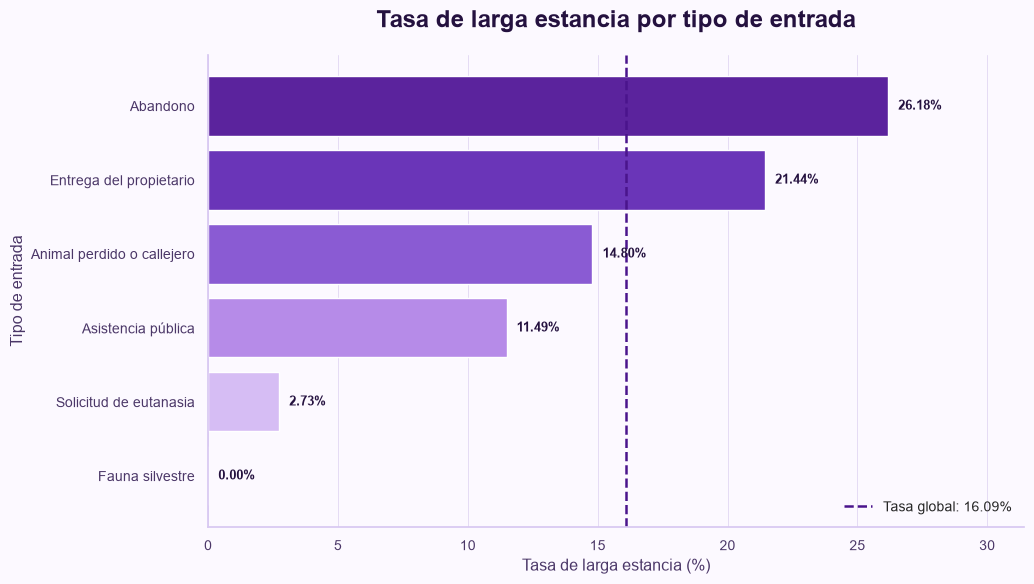

In [72]:
# Tasa de larga estancia por tipo de entrada

target_by_intake_type = (
    dogs_base
    .groupby("intake_type")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)

target_by_intake_type["tasa_larga_estancia"] = (target_by_intake_type["tasa_larga_estancia"] * 100).round(2)
target_by_intake_type["intake_type_es"] = (
    target_by_intake_type["intake_type"]
    .map(traduccion_entradas)
    .fillna(target_by_intake_type["intake_type"])
)
target_by_intake_type = target_by_intake_type.sort_values("tasa_larga_estancia", ascending=True)

display(target_by_intake_type)

plot_barh_estilo_invisible_dogs(
    categorias=target_by_intake_type["intake_type_es"],
    valores=target_by_intake_type["tasa_larga_estancia"],
    titulo="Tasa de larga estancia por tipo de entrada",
    xlabel="Tasa de larga estancia (%)",
    ylabel="Tipo de entrada",
    colors=["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#6A35B8", "#5B239D"][:len(target_by_intake_type)],
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%"
)

La tasa de larga estancia presenta diferencias notables según el tipo de entrada. Los perros abandonados presentan la tasa más alta, con un 26,18 %, seguidos de los perros entregados por su propietario, con un 21,44 %. Ambas categorías superan ampliamente la tasa global del 16,09 %.

En el extremo opuesto, los perros que ingresan por solicitud de eutanasia presentan una tasa muy baja, del 2,73 %, coherente con que su desenlace suele producirse en un plazo muy corto tras la entrada. La categoría "Fauna silvestre" solo contiene 1 registro y no resulta representativa. Los perros que llegan como animales perdidos o callejeros, la categoría más numerosa del dataset, presentan una tasa del 14,80 %, ligeramente por debajo de la media global.

Estos resultados indican que el tipo de entrada aporta información relevante sobre el riesgo de larga estancia y refuerzan su inclusión como variable predictora en la fase de modelización.

### 9.3. Relación entre el tipo de raza y la variable objetivo

Por último, se analiza si los perros registrados como raza mixta presentan una tasa de larga estancia diferente a la de los perros de raza no mixta.

,is_mixed_breed,registros,tasa_larga_estancia
1,Raza no mixta,19320,15.41
0,Raza mixta,74483,16.26


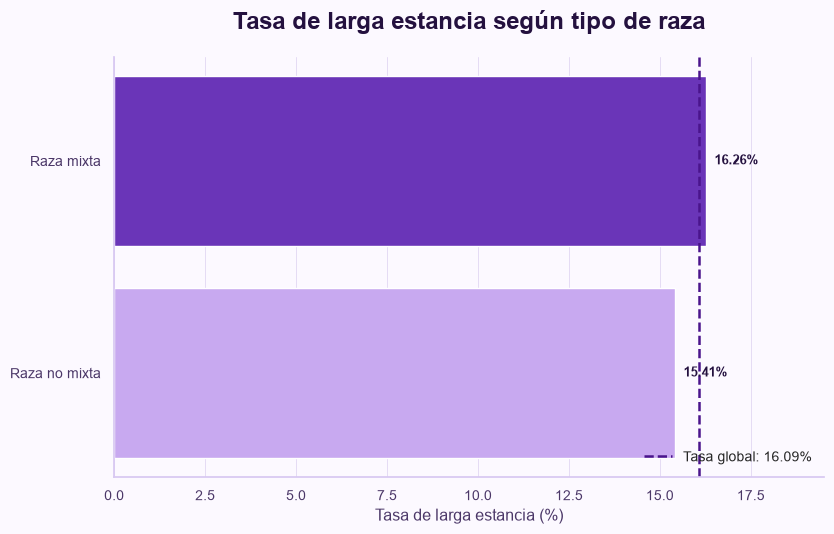

In [73]:
# Tasa de larga estancia por tipo de raza (mixta / no mixta)

target_by_mixed_breed = (
    dogs_base
    .groupby("is_mixed_breed")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)

target_by_mixed_breed["tasa_larga_estancia"] = (target_by_mixed_breed["tasa_larga_estancia"] * 100).round(2)
target_by_mixed_breed = target_by_mixed_breed.sort_values("tasa_larga_estancia", ascending=True)

display(target_by_mixed_breed)

plot_barh_estilo_invisible_dogs(
    categorias=target_by_mixed_breed["is_mixed_breed"],
    valores=target_by_mixed_breed["tasa_larga_estancia"],
    titulo="Tasa de larga estancia según tipo de raza",
    xlabel="Tasa de larga estancia (%)",
    ylabel="",
    colors=["#C8A9F0", "#6A35B8"],
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%",
    figsize=(8.5, 5.5)
)

A diferencia de las variables anteriores, el tipo de raza no muestra una relación aparente relevante con la variable objetivo. Los perros de raza mixta presentan una tasa de larga estancia del 16,26 % y los de raza no mixta del 15,41 %, ambas muy próximas a la tasa global del 16,09 %.

Este resultado no descarta que la raza principal agrupada (`main_breed_grouped`) pueda aportar información relevante de forma más específica, pero sugiere que la distinción binaria entre raza mixta y no mixta, por sí sola, tiene un poder discriminante limitado respecto a la larga estancia.

### 9.4. Síntesis del análisis bivariante

El análisis bivariante muestra que el grupo de edad y, especialmente, el tipo de entrada presentan diferencias relevantes en la tasa de larga estancia, lo que respalda su inclusión como variables predictoras. La distinción entre raza mixta y no mixta, en cambio, muestra un efecto muy limitado en esta forma binaria, aunque la raza principal agrupada (`main_breed_grouped`) podría aportar más información en un análisis más granular durante la fase de modelización.

Estos resultados son coherentes con las variables ya seleccionadas en el apartado 8 y refuerzan la decisión de avanzar hacia la selección y guardado del dataset preparado.

### 9.5. Ampliación del análisis bivariante: variables adicionales

El análisis bivariante de los apartados 9.1 a 9.3 se centró en tres variables candidatas: grupo de edad, tipo de entrada y tipo de raza (mixta o no mixta). Sin embargo, entre las variables predictoras ya construidas en el apartado 8 quedan por explorar otras con potencial señal predictiva, en particular `intake_condition`, `sterilized_intake` y `main_breed_grouped`. Esta última variable es, además, la que la síntesis del apartado 9.4 señalaba explícitamente como pendiente de un análisis más granular, tras comprobar que la distinción binaria de raza mixta aportaba poca información. A continuación se completa el análisis bivariante cruzando estas tres variables con `target_long_stay`, siguiendo el mismo criterio y el mismo estilo de representación utilizados en los apartados anteriores.

,intake_condition,registros,tasa_larga_estancia,intake_condition_es
1,Agonal,1,0.00,Agónico
3,Congenital,1,0.00,Congenital
7,Med Urgent,10,0.00,Urgencia médica
4,Feral,10,0.00,Ferales
14,Parvo,11,0.00,Parvo
0,Aged,444,10.36,Edad avanzada
16,Sick,2690,13.68,Enfermo
11,Normal,83197,15.11,Normal
15,Pregnant,114,22.81,Gestante
13,Other,229,24.89,Otra condición


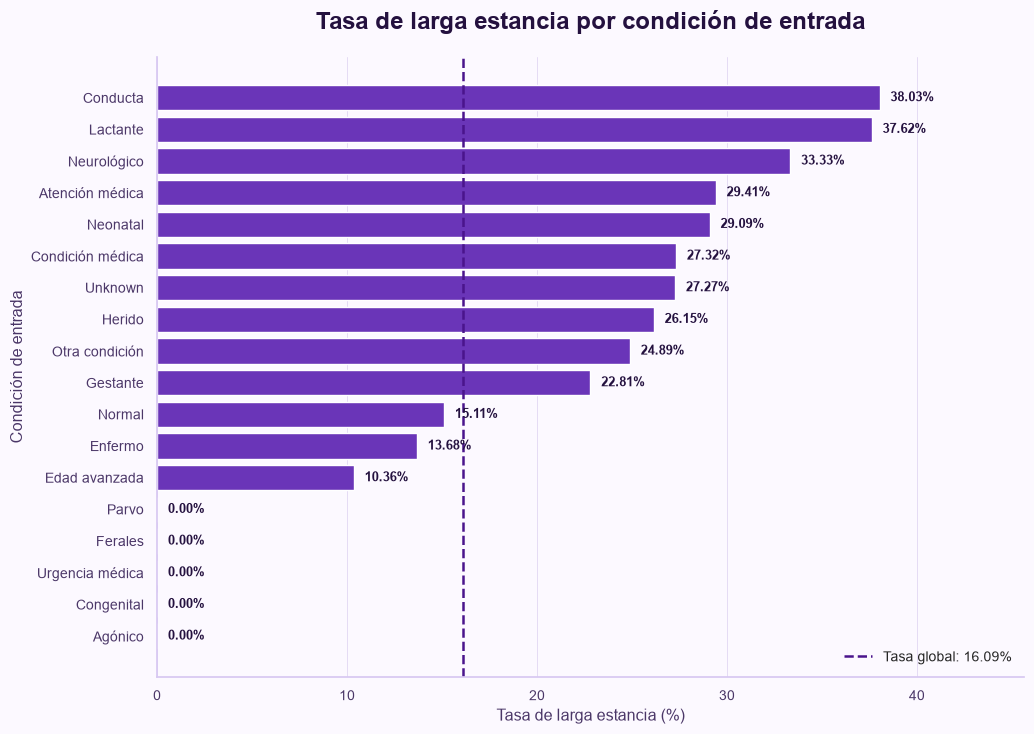

,sterilized_intake,registros,tasa_larga_estancia
0,Desconocido,706,3.97
1,Esterilizado,31268,15.10
2,No esterilizado,61829,16.72


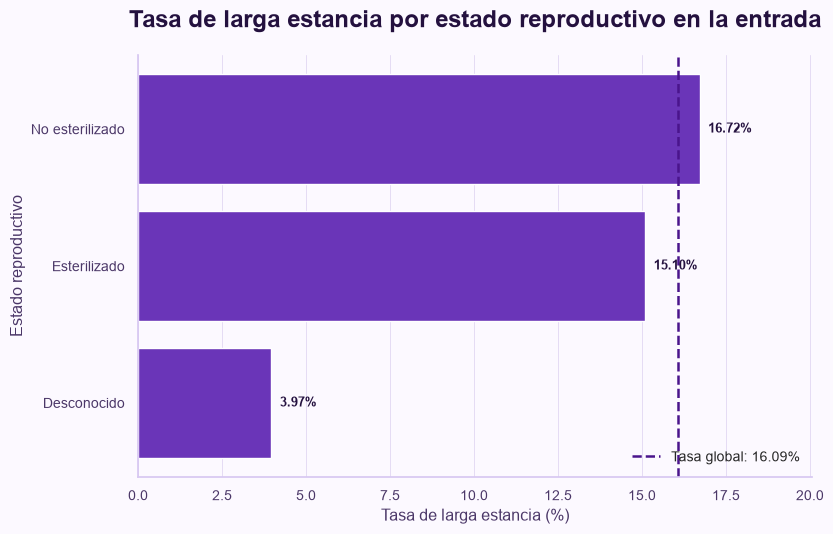

,main_breed_grouped,registros,tasa_larga_estancia
15,Yorkshire Terrier,1159,4.31
11,Miniature Poodle,1381,4.49
7,Dachshund,2098,6.05
6,Chihuahua Shorthair,10045,8.27
2,Beagle,1214,8.65
1,Australian Shepherd,1279,11.34
14,Siberian Husky,2112,13.21
9,Great Pyrenees,1561,13.32
12,Otras razas,30236,13.50
3,Border Collie,1779,13.72


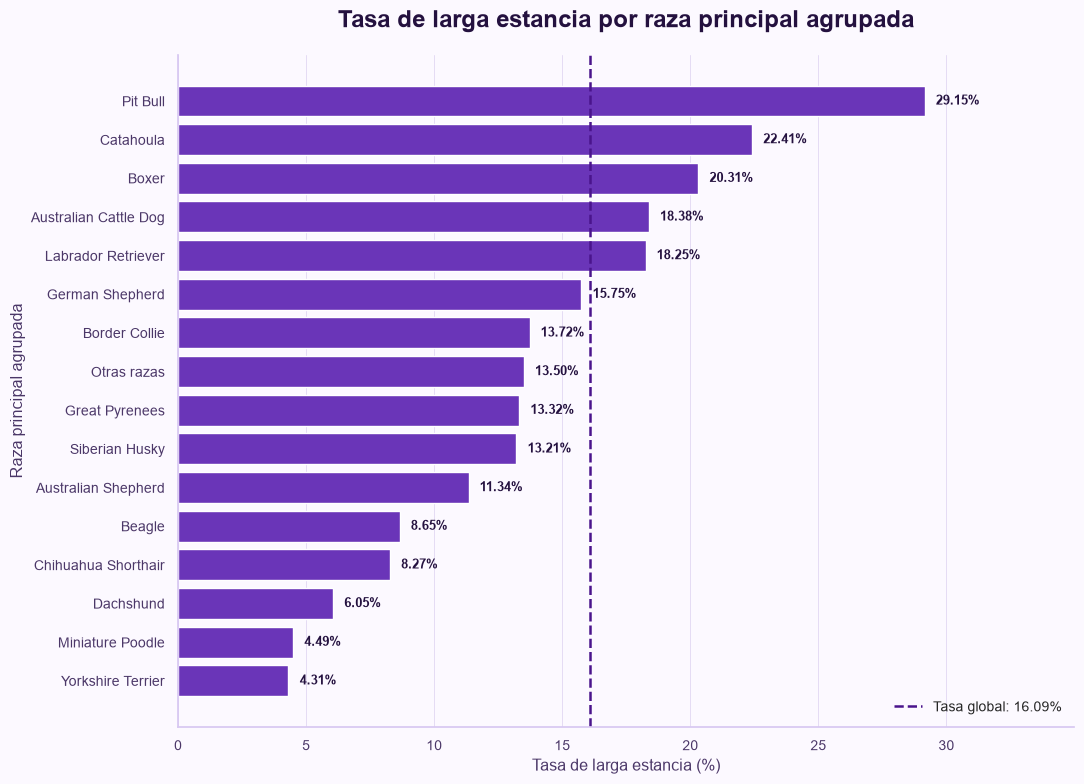

In [74]:
# Tasa de larga estancia por condición de entrada, estado reproductivo y raza principal agrupada

target_by_intake_condition = (
    dogs_base
    .groupby("intake_condition")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)
target_by_intake_condition["tasa_larga_estancia"] = (target_by_intake_condition["tasa_larga_estancia"] * 100).round(2)
target_by_intake_condition["intake_condition_es"] = (
    target_by_intake_condition["intake_condition"]
    .map(traduccion_condiciones)
    .fillna(target_by_intake_condition["intake_condition"])
)
target_by_intake_condition = target_by_intake_condition.sort_values("tasa_larga_estancia", ascending=True)

display(target_by_intake_condition)

plot_barh_estilo_invisible_dogs(
    categorias=target_by_intake_condition["intake_condition_es"],
    valores=target_by_intake_condition["tasa_larga_estancia"],
    titulo="Tasa de larga estancia por condición de entrada",
    xlabel="Tasa de larga estancia (%)",
    ylabel="Condición de entrada",
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%",
    figsize=(10.5, 7.5)
)


# Tasa de larga estancia por estado reproductivo en la entrada

target_by_sterilized = (
    dogs_base
    .groupby("sterilized_intake")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)
target_by_sterilized["tasa_larga_estancia"] = (target_by_sterilized["tasa_larga_estancia"] * 100).round(2)
target_by_sterilized = target_by_sterilized.sort_values("tasa_larga_estancia", ascending=True)

display(target_by_sterilized)

plot_barh_estilo_invisible_dogs(
    categorias=target_by_sterilized["sterilized_intake"],
    valores=target_by_sterilized["tasa_larga_estancia"],
    titulo="Tasa de larga estancia por estado reproductivo en la entrada",
    xlabel="Tasa de larga estancia (%)",
    ylabel="Estado reproductivo",
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%",
    figsize=(8.5, 5.5)
)


# Tasa de larga estancia por raza principal agrupada

target_by_main_breed = (
    dogs_base
    .groupby("main_breed_grouped")["target_long_stay"]
    .agg(registros="count", tasa_larga_estancia="mean")
    .reset_index()
)
target_by_main_breed["tasa_larga_estancia"] = (target_by_main_breed["tasa_larga_estancia"] * 100).round(2)
target_by_main_breed = target_by_main_breed.sort_values("tasa_larga_estancia", ascending=True)

display(target_by_main_breed)

plot_barh_estilo_invisible_dogs(
    categorias=target_by_main_breed["main_breed_grouped"],
    valores=target_by_main_breed["tasa_larga_estancia"],
    titulo="Tasa de larga estancia por raza principal agrupada",
    xlabel="Tasa de larga estancia (%)",
    ylabel="Raza principal agrupada",
    ref_line=tasa_global,
    ref_label=f"Tasa global: {tasa_global:.2f}%",
    figsize=(11, 8)
)

La ampliación del análisis bivariante confirma que las tres variables adicionales aportan señal de intensidad muy distinta. La condición de entrada es la que muestra el gradiente más pronunciado: categorías asociadas a vulnerabilidad, como conducta (38,03 %), lactancia (37,62 %) o heridas (26,17 %), presentan tasas muy superiores a la tasa global del 16,09 %, mientras que la categoría edad avanzada (10,36 %) se sitúa claramente por debajo. La categoría normal, que concentra la inmensa mayoría de los registros (83.209), presenta una tasa del 15,10 %, muy próxima a la media global. Algunas categorías extremadamente minoritarias (por ejemplo, urgencia médica o agónico, con 10 y 1 registro respectivamente) no se consideran representativas.

El estado reproductivo en la entrada, en cambio, muestra un efecto más moderado: los perros no esterilizados presentan una tasa del 16,72 % frente al 15,09 % de los esterilizados, una diferencia reducida en comparación con el resto de variables analizadas. La categoría desconocido (3,97 %) reúne muy pocos registros y coincide con salidas rápidas, por lo que no resulta especialmente informativa.

La raza principal agrupada es, de las tres, la que aporta la señal más clara: Pit Bull presenta la tasa más alta con diferencia (29,15 %, prácticamente el doble de la tasa global), seguida de Catahoula (22,41 %) y Boxer (20,31 %). En el extremo opuesto, razas de menor tamaño como Yorkshire Terrier (4,31 %), Miniature Poodle (4,49 %) o Dachshund (6,05 %) presentan tasas muy inferiores a la media. Este resultado confirma la hipótesis avanzada en el apartado 9.4: aunque la distinción binaria entre raza mixta y no mixta apenas discrimina, la raza principal agrupada sí concentra información relevante sobre el riesgo de larga estancia, y debería considerarse una variable predictora prioritaria en la fase de modelización.

En conjunto, esta ampliación refuerza la lista de variables predictoras candidatas ya identificada en el apartado 10.3, aportando evidencia adicional sobre cuáles de ellas (especialmente `intake_condition` y `main_breed_grouped`) podrían tener mayor peso en el modelo final.

### 9.6. Significancia estadística del análisis bivariante

Las diferencias en la tasa de larga estancia descritas en los apartados 9.1 a 9.5 se han interpretado hasta ahora de forma descriptiva y visual, sin comprobar si son estadísticamente significativas o podrían deberse al azar. Para completar el análisis bivariante con un criterio de rigor estadístico, se aplican dos pruebas complementarias a las seis variables candidatas exploradas: un test de chi-cuadrado de independencia, que evalúa si existe una asociación global entre cada variable y `target_long_stay`, y un intervalo de confianza del 95 % (método de Wilson) para la tasa de larga estancia de cada categoría, que permite valorar si esa tasa difiere de forma significativa de la tasa global del dataset.

In [75]:
# Test de chi-cuadrado de independencia frente a target_long_stay

from scipy.stats import chi2_contingency

variables_bivariante = [
    "age_group",
    "intake_type",
    "is_mixed_breed",
    "intake_condition",
    "sterilized_intake",
    "main_breed_grouped"
]

resultados_chi2 = []
for variable in variables_bivariante:
    tabla_contingencia = pd.crosstab(dogs_base[variable], dogs_base["target_long_stay"])
    chi2, p_valor, grados_libertad, _ = chi2_contingency(tabla_contingencia)
    resultados_chi2.append({
        "variable": variable,
        "chi2": round(chi2, 2),
        "grados_libertad": grados_libertad,
        "p_valor": p_valor,
        "asociacion_significativa_95": p_valor < 0.05
    })

resultados_chi2 = pd.DataFrame(resultados_chi2).sort_values("p_valor").reset_index(drop=True)

print("Test de chi-cuadrado de independencia frente a target_long_stay:")
display(resultados_chi2)


# Intervalo de confianza del 95 % (Wilson) para la tasa de larga estancia por categoría

def anadir_intervalo_confianza_wilson(tabla_resumen, z=1.959963985):
    tabla_resumen = tabla_resumen.copy()
    n = tabla_resumen["registros"]
    p = tabla_resumen["tasa_larga_estancia"] / 100

    centro = p + z**2 / (2 * n)
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    denominador = 1 + z**2 / n

    tabla_resumen["ic_95_inferior"] = ((centro - margen) / denominador * 100).round(2)
    tabla_resumen["ic_95_superior"] = ((centro + margen) / denominador * 100).round(2)
    tabla_resumen["difiere_de_tasa_global"] = (
        (tasa_global < tabla_resumen["ic_95_inferior"]) |
        (tasa_global > tabla_resumen["ic_95_superior"])
    )
    return tabla_resumen


tablas_bivariante = {
    "age_group": target_by_age_group,
    "intake_type": target_by_intake_type,
    "is_mixed_breed": target_by_mixed_breed,
    "intake_condition": target_by_intake_condition,
    "sterilized_intake": target_by_sterilized,
    "main_breed_grouped": target_by_main_breed
}

for nombre_variable, tabla in tablas_bivariante.items():
    print(f"\nIntervalo de confianza del 95 % para la tasa de larga estancia — {nombre_variable}:")
    display(anadir_intervalo_confianza_wilson(tabla))

Test de chi-cuadrado de independencia frente a target_long_stay:


,variable,chi2,grados_libertad,p_valor,asociacion_significativa_95
0,main_breed_grouped,3050.87,15,0.000000e+00,True
1,intake_condition,1015.59,17,4.166357e-205,True
2,intake_type,754.59,5,7.676406e-161,True
3,age_group,310.96,4,4.679318e-66,True
4,sterilized_intake,118.04,2,2.336949e-26,True
5,is_mixed_breed,8.20,1,4.195887e-03,True



Intervalo de confianza del 95 % para la tasa de larga estancia — age_group:


,age_group,registros,tasa_larga_estancia,ic_95_inferior,ic_95_superior,difiere_de_tasa_global
1,Cachorro,24195,13.03,12.61,13.46,True
2,Joven,41581,17.43,17.07,17.80,True
0,Adulto,20286,17.94,17.42,18.47,True
3,Senior,7733,13.58,12.83,14.36,True
4,Sin información,8,12.50,2.24,47.09,False



Intervalo de confianza del 95 % para la tasa de larga estancia — intake_type:


...

,intake_condition,registros,tasa_larga_estancia,intake_condition_es,ic_95_inferior,ic_95_superior,difiere_de_tasa_global
1,Agonal,1,0.00,Agónico,0.00,79.35,False
3,Congenital,1,0.00,Congenital,0.00,79.35,False
7,Med Urgent,10,0.00,Urgencia médica,0.00,27.75,False
4,Feral,10,0.00,Ferales,0.00,27.75,False
14,Parvo,11,0.00,Parvo,0.00,25.88,False
0,Aged,444,10.36,Edad avanzada,7.86,13.54,True
16,Sick,2690,13.68,Enfermo,12.43,15.03,True
11,Normal,83197,15.11,Normal,14.87,15.35,True
15,Pregnant,114,22.81,Gestante,16.07,31.32,False
13,Other,229,24.89,Otra condición,19.74,30.87,True



Intervalo de confianza del 95 % para la tasa de larga estancia — sterilized_intake:


,sterilized_intake,registros,tasa_larga_estancia,ic_95_inferior,ic_95_superior,difiere_de_tasa_global
0,Desconocido,706,3.97,2.76,5.68,True
1,Esterilizado,31268,15.10,14.71,15.50,True
2,No esterilizado,61829,16.72,16.43,17.02,True



Intervalo de confianza del 95 % para la tasa de larga estancia — main_breed_grouped:


,main_breed_grouped,registros,tasa_larga_estancia,ic_95_inferior,ic_95_superior,difiere_de_tasa_global
15,Yorkshire Terrier,1159,4.31,3.28,5.64,True
11,Miniature Poodle,1381,4.49,3.52,5.71,True
7,Dachshund,2098,6.05,5.11,7.15,True
6,Chihuahua Shorthair,10045,8.27,7.75,8.82,True
2,Beagle,1214,8.65,7.20,10.36,True
1,Australian Shepherd,1279,11.34,9.72,13.19,True
14,Siberian Husky,2112,13.21,11.83,14.72,True
9,Great Pyrenees,1561,13.32,11.72,15.10,True
12,Otras razas,30236,13.50,13.12,13.89,True
3,Border Collie,1779,13.72,12.20,15.40,True


El test de chi-cuadrado confirma que las seis variables analizadas presentan una asociación estadísticamente significativa con `target_long_stay` (p < 0,05 en todos los casos). Las asociaciones más fuertes corresponden a `main_breed_grouped` (χ² = 3.050,87; p < 0,001) e `intake_condition` (χ² = 1.015,59; p < 0,001), seguidas de `intake_type` (χ² = 754,59; p < 0,001) y `age_group` (χ² = 310,96; p < 0,001), lo que respalda cuantitativamente la jerarquía de relevancia sugerida por la inspección visual en los apartados anteriores.

El caso de `is_mixed_breed` merece una lectura más matizada: aunque el test resulta significativo (χ² = 8,20; p = 0,0042), el efecto es mucho más débil que el del resto de variables, y así lo confirma el intervalo de confianza, ya que los intervalos de raza mixta (15,99 %–16,52 %) y raza no mixta (14,89 %–15,91 %) se solapan casi por completo. Este resultado ilustra un matiz estadístico relevante dado el tamaño de la muestra (93.803 registros): con un volumen de datos tan grande, incluso diferencias de escasa magnitud práctica pueden resultar significativas, por lo que el p-valor debe interpretarse siempre junto con el intervalo de confianza y no de forma aislada. Esto confirma, con criterio estadístico y no solo visual, la conclusión ya avanzada en el apartado 9.3: la distinción binaria de raza mixta aporta señal real pero de magnitud limitada.

Los intervalos de confianza por categoría permiten además identificar qué grupos concretos se alejan de la tasa global del 16,09 % de forma significativa. Por ejemplo, en `intake_type`, tanto los perros abandonados (26,18 %; IC 23,65 %–28,88 %) como los que ingresan por solicitud de eutanasia (2,73 %; IC 1,17 %–6,24 %) presentan intervalos que no incluyen la tasa global, confirmando que ambas diferencias son reales y no atribuibles al azar. En cambio, algunas categorías muy minoritarias (por ejemplo, `Wildlife` en `intake_type`, con un único registro, o varias condiciones de entrada con menos de 15 casos) muestran intervalos de confianza muy amplios, lo que indica que sus tasas no pueden interpretarse de forma fiable y deben tratarse con cautela en la fase de modelización.

## 10. Selección, validación y guardado del dataset preparado

Una vez construida la variable objetivo y creadas las principales variables predictoras, se selecciona un conjunto final de columnas, se valida su calidad y compatibilidad con la fase de modelización, y se guarda el dataset preparado.

La selección incluye variables de identificación, fechas, tiempo de estancia, variable objetivo y variables predictoras disponibles en el momento de entrada del perro al refugio, incluyendo las variables históricas, de contexto temporal y de alta cardinalidad incorporadas durante la preparación.


In [76]:
# Selección del dataset preparado

columns_final = [
    "animal_id",
    "intake_datetime",
    "outcome_datetime",
    "stay_days",
    "stay_days_rounded",
    "target_long_stay",

    "intake_type",
    "intake_condition",
    "sex_upon_intake",
    "sex",
    "sterilized_intake",
    "age_upon_intake",
    "age_months_intake",
    "age_group",

    "name_intake",
    "has_name_intake",
    "found_location",
    "found_location_grouped",

    "breed_intake",
    "is_mixed_breed",
    "main_breed",
    "main_breed_grouped",
    "has_secondary_breed",
    "secondary_breed",
    "breed_num_terms",

    "color_intake",
    "main_color",
    "main_color_grouped",
    "has_secondary_color",
    "secondary_color",
    "color_num_terms",

    "intake_month",
    "intake_dayofweek",
    "intake_hour",
    "intake_is_weekend",
    "intake_season",

    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition",

    "previous_intake_count",
    "is_repeat_intake",
    "days_since_previous_intake",
    "previous_outcome_type",
    "previous_stay_days",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",

    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d",

    "outcome_type",
    "outcome_subtype"
]

columnas_finales_faltantes = [col for col in columns_final if col not in dogs_base.columns]

if columnas_finales_faltantes:
    raise ValueError(f"Faltan columnas para construir el dataset preparado: {columnas_finales_faltantes}")

dogs_model_ready = dogs_base[columns_final].copy()

print("Dimensiones del dataset preparado:")
print(dogs_model_ready.shape)

print("\nPrimeras filas del dataset preparado:")
display(dogs_model_ready.head())

print("\nResumen de valores nulos:")
display(
    pd.DataFrame({
        "variable": dogs_model_ready.columns,
        "nulos": dogs_model_ready.isna().sum().values,
        "porcentaje_nulos": (dogs_model_ready.isna().mean().values * 100).round(2)
    }).sort_values("porcentaje_nulos", ascending=False)
)


Dimensiones del dataset preparado:
(93803, 57)

Primeras filas del dataset preparado:


,animal_id,intake_datetime,outcome_datetime,stay_days,stay_days_rounded,target_long_stay,intake_type,intake_condition,sex_upon_intake,sex,sterilized_intake,age_upon_intake,age_months_intake,age_group,name_intake,has_name_intake,found_location,found_location_grouped,breed_intake,is_mixed_breed,main_breed,main_breed_grouped,has_secondary_breed,secondary_breed,breed_num_terms,color_intake,main_color,main_color_grouped,has_secondary_color,secondary_color,color_num_terms,intake_month,intake_dayofweek,intake_hour,intake_is_weekend,intake_season,age_group_intake_type,condition_intake_type,breed_age_group,season_condition,previous_intake_count,is_repeat_intake,days_since_previous_intake,previous_outcome_type,previous_stay_days,previous_long_stay_count,previous_owner_surrender_count,previous_stray_count,n_intakes_dogs_last_7d,n_intakes_dogs_last_30d,n_outcomes_dogs_last_7d,n_outcomes_dogs_last_30d,n_adoptions_dogs_last_30d,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d,outcome_type,outcome_subtype
0,A006100,2014-03-07 14:26:00,2014-03-08 17:10:00,1.113889,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,6 years,72.0,Adulto,Scamp,Con nombre registrado,8700 Research in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,3,4,14,0,Primavera,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,171.0,864.0,163.0,772.0,337.0,460.0,1.117723,Return to Owner,NaN
1,A006100,2014-12-19 10:21:00,2014-12-20 16:35:00,1.259722,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,7 years,84.0,Adulto,Scamp,Con nombre registrado,8700 Research Blvd in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,12,4,10,0,Invierno,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Invierno | Normal,1,1,286.829861,Return to Owner,2.0,0.0,0.0,0.0,228.0,925.0,202.0,976.0,414.0,404.0,0.946776,Return to Owner,NaN
2,A047759,2014-04-02 15:55:00,2014-04-07 15:12:00,4.970139,5,0,Owner Surrender,Normal,Neutered Male,Macho,Esterilizado,10 years,120.0,Senior,Oreo,Con nombre registrado,Austin (TX),Austin,Dachshund,Raza no mixta,Dachshund,Dachshund,0,NaN,1,Tricolor,Tricolor,Tricolor,0,NaN,1,4,2,15,0,Primavera,Senior | Owner Surrender,Normal | Owner Surrender,Dachshund | Senior,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,205.0,900.0,191.0,864.0,354.0,463.0,1.040462,Transfer,Partner
3,A134067,2013-11-16 09:02:00,2013-11-16 11:54:00,0.119444,1,0,Public Assist,Injured,Neutered Male,Macho,Esterilizado,16 years,192.0,Senior,Bandit,Con nombre registrado,12034 Research Blvd in Austin (TX),Austin,Shetland Sheepdog,Raza no mixta,Shetland Sheepdog,Otras razas,0,NaN,1,Brown/White,Brown,Brown,1,White,2,11,5,9,1,Otoño,Senior | Public Assist,Injured | Public Assist,Otras razas | Senior,Otoño | Injured,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,181.0,855.0,176.0,777.0,288.0,314.0,1.098972,Return to Owner,NaN
4,A141142,2013-11-16 14:46:00,2013-11-17 11:40:00,0.870833,1,0,Stray,Aged,Spayed Female,Hembra,Esterilizado,15 years,180.0,Senior,Bettie,Con nombre registrado,Austin (TX),Austin,Labrador Retriever/Pit Bull,Raza mixta,Labrador Retriever,Labrador Retriever,1,Pit Bull,2,Black/White,Black,Black,1,White,2,11,5,14,1,Otoño,Senior | Stray,Aged | Stray,Labrador Retriever | Senior,Otoño | Aged,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,179.0,854.0,174.0,786.0,290.0,315.0,1.085133,Return to Owner,NaN



Resumen de valores nulos:


,variable,nulos,porcentaje_nulos
44,previous_stay_days,79564,84.82
42,days_since_previous_intake,79555,84.81
23,secondary_breed,78434,83.62
56,outcome_subtype,62835,66.99
29,secondary_color,30744,32.78
14,name_intake,14698,15.67
55,outcome_type,27,0.03
12,age_months_intake,8,0.01
1,intake_datetime,0,0.00
8,sex_upon_intake,1,0.00


El dataset preparado incluye información identificativa, fechas de entrada y salida, tiempo de estancia, variable objetivo y variables predictoras derivadas a partir de la información disponible en el momento de entrada del perro al refugio, junto con las nuevas variables incorporadas en el apartado 8: indicador de nombre registrado, indicadores y complejidad de raza y color, agrupación de la localización de hallazgo, variables temporales de la entrada, e historial de entradas previas del mismo perro. Las dimensiones exactas se muestran en la celda anterior.

El análisis de valores nulos muestra que la mayoría de variables relevantes para la modelización no presenta valores ausentes. Las excepciones más relevantes son `age_months_intake` (edades negativas tratadas como no informadas en el apartado 8.1) y `days_since_previous_intake` (nulo para las entradas sin ninguna entrada previa registrada, es decir, cuando `is_repeat_intake` es 0).

Las variables `outcome_type`, `outcome_subtype`, `outcome_datetime`, `stay_days` y `stay_days_rounded` se mantienen en el dataset preparado con fines descriptivos y de trazabilidad, pero no deberán utilizarse como variables predictoras en la fase de modelización, ya que representan información conocida después de la entrada del animal y podrían generar fuga de información.

In [77]:
# Comprobación de compatibilidad con la fase de modelización

variables_predictoras_generales = [
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "is_mixed_breed",
    "main_breed_grouped",
    "main_color_grouped",
    "intake_month",
    "intake_dayofweek",
    "intake_hour",
    "intake_is_weekend",
    "intake_season",
    "has_secondary_breed",
    "secondary_breed",
    "has_secondary_color",
    "secondary_color",
    "breed_num_terms",
    "color_num_terms",
    "has_name_intake",
    "found_location_grouped",
    "previous_intake_count",
    "is_repeat_intake",
    "days_since_previous_intake",
    "previous_outcome_type",
    "previous_stay_days",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

variables_predictoras_catboost = [
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "is_mixed_breed",
    "intake_month",
    "intake_dayofweek",
    "intake_hour",
    "intake_is_weekend",
    "intake_season",
    "has_secondary_breed",
    "secondary_breed",
    "has_secondary_color",
    "secondary_color",
    "breed_num_terms",
    "color_num_terms",
    "has_name_intake",
    "previous_intake_count",
    "is_repeat_intake",
    "days_since_previous_intake",
    "previous_outcome_type",
    "previous_stay_days",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d",
    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition",
    "breed_intake",
    "color_intake",
    "found_location"
]

required_columns_for_modeling = [
    "animal_id",
    "target_long_stay"
] + sorted(set(variables_predictoras_generales + variables_predictoras_catboost))

columnas_requeridas_faltantes = set(required_columns_for_modeling) - set(dogs_model_ready.columns)

if columnas_requeridas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias para la fase de modelización: {columnas_requeridas_faltantes}"
    )

print("Todas las columnas necesarias para la fase de modelización están presentes.")
print("Número de variables predictoras generales:", len(variables_predictoras_generales))
print("Número de variables predictoras candidatas para CatBoost:", len(variables_predictoras_catboost))


Todas las columnas necesarias para la fase de modelización están presentes.
Número de variables predictoras generales: 37
Número de variables predictoras candidatas para CatBoost: 41


In [78]:
# Comprobaciones de calidad previas al guardado del dataset preparado

assert dogs_model_ready.shape[0] > 0, "El dataset preparado está vacío."
assert dogs_model_ready["animal_id"].notna().all(), "Existen valores nulos en animal_id."
assert dogs_model_ready["target_long_stay"].notna().all(), "Existen valores nulos en target_long_stay."
assert dogs_model_ready["target_long_stay"].isin([0, 1]).all(), "target_long_stay contiene valores distintos de 0 y 1."
assert (dogs_model_ready["stay_days"] >= 0).all(), "Existen estancias negativas en el dataset preparado."

columnas_derivadas_modelizacion = [
    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition",
    "previous_outcome_type",
    "previous_stay_days",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

columnas_derivadas_faltantes = [
    col for col in columnas_derivadas_modelizacion
    if col not in dogs_model_ready.columns
]

assert not columnas_derivadas_faltantes, (
    f"Faltan variables derivadas para la modelización: {columnas_derivadas_faltantes}"
)

columnas_conteo_contexto = [
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

assert dogs_model_ready[columnas_conteo_contexto].ge(0).all().all(), (
    "Existen valores negativos en variables históricas o de contexto."
)

if "controles_fuga_temporal_eda" in globals():
    assert controles_fuga_temporal_eda["resultado"].eq("OK").all(), (
        "Algún control de fuga temporal requiere revisión."
    )

print("Comprobaciones de calidad superadas: el dataset preparado es apto para su guardado.")


Comprobaciones de calidad superadas: el dataset preparado es apto para su guardado.


In [79]:
# Guardado del dataset preparado

output_path = processed_data_path / "invisible_dogs_dataset_preparado.csv"

dogs_model_ready.to_csv(output_path, index=False)

print(f"Dataset preparado guardado correctamente en: {output_path}")
print("Dimensiones del archivo guardado:", dogs_model_ready.shape)

if "controles_fuga_temporal_eda" in globals():
    controles_fuga_temporal_path = processed_data_path / "controles_fuga_temporal_preparacion.csv"
    controles_fuga_temporal_eda.to_csv(controles_fuga_temporal_path, index=False)
    print(f"Controles de fuga temporal guardados en: {controles_fuga_temporal_path}")


Dataset preparado guardado correctamente en: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\invisible_dogs_dataset_preparado.csv
Dimensiones del archivo guardado: (93803, 57)
Controles de fuga temporal guardados en: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\controles_fuga_temporal_preparacion.csv


In [80]:
# Verificación de la carga del dataset guardado

dogs_model_ready_verificacion = pd.read_csv(output_path)

if dogs_model_ready_verificacion.shape != dogs_model_ready.shape:
    raise ValueError("Las dimensiones del archivo guardado no coinciden con las del dataset preparado.")

if set(dogs_model_ready_verificacion.columns) != set(dogs_model_ready.columns):
    raise ValueError("Las columnas del archivo guardado no coinciden con las del dataset preparado.")

if not set(required_columns_for_modeling).issubset(dogs_model_ready_verificacion.columns):
    raise ValueError("El archivo guardado no contiene todas las columnas necesarias para la fase de modelización.")

print("Verificación superada: el archivo guardado reproduce correctamente el dataset preparado.")
print("Ruta:", output_path)
print("Dimensiones verificadas:", dogs_model_ready_verificacion.shape)

print("\nDistribución de target_long_stay en el archivo guardado:")
display(dogs_model_ready_verificacion["target_long_stay"].value_counts(normalize=True).mul(100).round(2))

print("\nEl dataset preparado queda disponible en data/processed y contiene las variables "
      "necesarias para la modelización predictiva y la construcción del Invisible Dog Score.")


Verificación superada: el archivo guardado reproduce correctamente el dataset preparado.
Ruta: g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\invisible_dogs_dataset_preparado.csv
Dimensiones verificadas: (93803, 57)

Distribución de target_long_stay en el archivo guardado:


target_long_stay
0    83.91
1    16.09
Name: proportion, dtype: float64


El dataset preparado queda disponible en data/processed y contiene las variables necesarias para la modelización predictiva y la construcción del Invisible Dog Score.


### 10.1. Consideraciones para la fase de modelización

Aunque el dataset preparado conserva variables posteriores a la entrada del perro, como `outcome_datetime`, `outcome_type`, `outcome_subtype`, `stay_days` y `stay_days_rounded`, estas columnas no deberán utilizarse como variables predictoras. Se mantienen en el archivo final por motivos de trazabilidad, análisis descriptivo y validación de la variable objetivo.

El dataset también incorpora variables históricas y de contexto temporal. Estas variables sí pueden considerarse candidatas para la modelización porque se han calculado exclusivamente con información anterior a la entrada actual del perro. En particular, el historial del animal se basa en registros previos del mismo `animal_id`, mientras que las variables de presión del refugio se calculan con eventos ocurridos antes de `intake_datetime`.

Además, se conservan variables completas de alta cardinalidad, como `breed_intake`, `color_intake` y `found_location`. Estas variables no se consideran candidatas generales para cualquier tipo de modelo, pero pueden ser útiles en algoritmos capaces de tratar categorías de alta cardinalidad de forma nativa. Por ello, el dataset final mantiene tanto sus versiones agrupadas como las variables originales necesarias para comparar enfoques de modelización.

Dado que algunos perros aparecen en más de una estancia a lo largo del periodo analizado, la partición de entrenamiento y prueba deberá realizarse teniendo en cuenta `animal_id`. Esta precaución reducirá el riesgo de que registros del mismo perro aparezcan simultáneamente en entrenamiento y evaluación, reforzando la validez de los resultados.

También conviene tener presente que los datos se obtienen mediante consulta directa a una API pública actualizada de forma continua. Por ello, los resultados exactos podrían variar ligeramente si el proceso se ejecuta en una fecha posterior. El snapshot registrado durante la carga de datos permite documentar la extracción utilizada en esta ejecución concreta.

Asimismo, el criterio de emparejamiento entre entradas y salidas asocia cronológicamente cada entrada con la primera salida posterior todavía disponible, garantizando que ninguna entrada ni ninguna salida se reutiliza en más de una estancia. Al no existir en la fuente original un identificador que vincule explícitamente cada entrada con su salida, este criterio sigue siendo una aproximación razonable para reconstruir las estancias y debe tenerse en cuenta al interpretar los resultados posteriores del modelo.


### 10.2. Diccionario de variables preparadas
Como parte del cierre del notebook, se resume el conjunto de variables creadas durante la preparación del dataset. Este diccionario facilita la trazabilidad de las transformaciones realizadas y permite identificar qué variables podrán utilizarse posteriormente en la fase de modelización.

In [81]:
# Diccionario de variables preparadas

diccionario_variables_data = [
    {
        "variable": "stay_days",
        "origen": "intake_datetime + outcome_datetime",
        "descripcion": "Tiempo de estancia en días decimales.",
        "uso_modelizacion": "No usar como predictora"
    },
    {
        "variable": "stay_days_rounded",
        "origen": "stay_days",
        "descripcion": "Tiempo de estancia redondeado a días completos.",
        "uso_modelizacion": "No usar como predictora"
    },
    {
        "variable": "target_long_stay",
        "origen": "stay_days",
        "descripcion": "Variable objetivo: 1 si la estancia supera 30 días, 0 en caso contrario.",
        "uso_modelizacion": "Variable objetivo"
    },
    {
        "variable": "age_months_intake",
        "origen": "age_upon_intake",
        "descripcion": "Edad del perro en meses en el momento de entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "age_group",
        "origen": "age_months_intake",
        "descripcion": "Grupo de edad: cachorro, joven, adulto, senior o sin información.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "sex",
        "origen": "sex_upon_intake",
        "descripcion": "Sexo del perro: macho, hembra o desconocido.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "sterilized_intake",
        "origen": "sex_upon_intake",
        "descripcion": "Estado reproductivo en la entrada: esterilizado, no esterilizado o desconocido.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "is_mixed_breed",
        "origen": "breed_intake",
        "descripcion": "Indica si el perro aparece registrado como raza mixta o cruce.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "breed_intake",
        "origen": "dataset de entradas",
        "descripcion": "Raza completa registrada en la entrada.",
        "uso_modelizacion": "Predictora de alta cardinalidad para modelos categóricos nativos"
    },
    {
        "variable": "main_breed",
        "origen": "breed_intake",
        "descripcion": "Raza principal extraída a partir de la raza original.",
        "uso_modelizacion": "Variable intermedia"
    },
    {
        "variable": "main_breed_grouped",
        "origen": "main_breed",
        "descripcion": "Raza principal agrupada en razas frecuentes y otras razas.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "has_secondary_breed",
        "origen": "breed_intake",
        "descripcion": "Indica si breed_intake incluye una segunda raza.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "secondary_breed",
        "origen": "breed_intake",
        "descripcion": "Segunda raza registrada en breed_intake, si existe.",
        "uso_modelizacion": "Predictora general candidata"
    },
    {
        "variable": "breed_num_terms",
        "origen": "breed_intake",
        "descripcion": "Número de términos de raza registrados en breed_intake.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "color_intake",
        "origen": "dataset de entradas",
        "descripcion": "Color completo registrado en la entrada.",
        "uso_modelizacion": "Predictora de alta cardinalidad para modelos categóricos nativos"
    },
    {
        "variable": "main_color",
        "origen": "color_intake",
        "descripcion": "Color principal extraído a partir del color original.",
        "uso_modelizacion": "Variable intermedia"
    },
    {
        "variable": "main_color_grouped",
        "origen": "main_color",
        "descripcion": "Color principal agrupado en colores frecuentes y otros colores.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "has_secondary_color",
        "origen": "color_intake",
        "descripcion": "Indica si color_intake incluye un segundo color.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "secondary_color",
        "origen": "color_intake",
        "descripcion": "Segundo color registrado en color_intake, si existe.",
        "uso_modelizacion": "Predictora general candidata"
    },
    {
        "variable": "color_num_terms",
        "origen": "color_intake",
        "descripcion": "Número de términos de color registrados en color_intake.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "has_name_intake",
        "origen": "name_intake",
        "descripcion": "Indica si el perro tiene un nombre registrado en la entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "found_location",
        "origen": "dataset de entradas",
        "descripcion": "Localización completa de hallazgo registrada en texto libre.",
        "uso_modelizacion": "Predictora de alta cardinalidad para modelos categóricos nativos"
    },
    {
        "variable": "found_location_grouped",
        "origen": "found_location",
        "descripcion": "Agrupación de found_location en Austin, Travis, Outside Jurisdiction u otra localización.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "intake_month",
        "origen": "intake_datetime",
        "descripcion": "Mes de la entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "intake_dayofweek",
        "origen": "intake_datetime",
        "descripcion": "Día de la semana de la entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "intake_hour",
        "origen": "intake_datetime",
        "descripcion": "Hora del día de la entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "intake_is_weekend",
        "origen": "intake_dayofweek",
        "descripcion": "Indica si la entrada se produjo en fin de semana.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "intake_season",
        "origen": "intake_month",
        "descripcion": "Estación del año de la entrada.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "age_group_intake_type",
        "origen": "age_group + intake_type",
        "descripcion": "Interacción categórica entre grupo de edad y tipo de entrada.",
        "uso_modelizacion": "Interacción candidata"
    },
    {
        "variable": "condition_intake_type",
        "origen": "intake_condition + intake_type",
        "descripcion": "Interacción categórica entre condición inicial y tipo de entrada.",
        "uso_modelizacion": "Interacción candidata"
    },
    {
        "variable": "breed_age_group",
        "origen": "main_breed_grouped + age_group",
        "descripcion": "Interacción categórica entre raza agrupada y grupo de edad.",
        "uso_modelizacion": "Interacción candidata"
    },
    {
        "variable": "season_condition",
        "origen": "intake_season + intake_condition",
        "descripcion": "Interacción categórica entre estación de entrada y condición inicial.",
        "uso_modelizacion": "Interacción candidata"
    },
    {
        "variable": "previous_intake_count",
        "origen": "animal_id + intake_datetime",
        "descripcion": "Número de entradas previas del mismo perro antes de la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "is_repeat_intake",
        "origen": "previous_intake_count",
        "descripcion": "Indica si la entrada actual no es la primera del perro.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "days_since_previous_intake",
        "origen": "animal_id + intake_datetime",
        "descripcion": "Días transcurridos desde la entrada previa del mismo perro, si existe.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "previous_outcome_type",
        "origen": "historial previo del animal",
        "descripcion": "Tipo de salida de la estancia previa del mismo perro, si existe.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "previous_stay_days",
        "origen": "historial previo del animal",
        "descripcion": "Duración de la estancia previa del mismo perro, si existe.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "previous_long_stay_count",
        "origen": "historial previo del animal",
        "descripcion": "Número acumulado de largas estancias previas del mismo perro.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "previous_owner_surrender_count",
        "origen": "historial previo del animal",
        "descripcion": "Número acumulado de entradas previas por entrega del propietario.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "previous_stray_count",
        "origen": "historial previo del animal",
        "descripcion": "Número acumulado de entradas previas como animal callejero.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "n_intakes_dogs_last_7d",
        "origen": "intake_datetime",
        "descripcion": "Número de entradas de perros en los 7 días anteriores a la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "n_intakes_dogs_last_30d",
        "origen": "intake_datetime",
        "descripcion": "Número de entradas de perros en los 30 días anteriores a la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "n_outcomes_dogs_last_7d",
        "origen": "outcome_datetime anterior a intake_datetime",
        "descripcion": "Número de salidas de perros en los 7 días anteriores a la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "n_outcomes_dogs_last_30d",
        "origen": "outcome_datetime anterior a intake_datetime",
        "descripcion": "Número de salidas de perros en los 30 días anteriores a la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "n_adoptions_dogs_last_30d",
        "origen": "outcome_type + outcome_datetime anterior a intake_datetime",
        "descripcion": "Número de adopciones de perros en los 30 días anteriores a la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "estimated_active_dogs_at_intake",
        "origen": "entradas y salidas previas",
        "descripcion": "Estimación aproximada de perros activos en el refugio antes de la entrada actual.",
        "uso_modelizacion": "Predictora general"
    },
    {
        "variable": "ratio_intakes_outcomes_30d",
        "origen": "n_intakes_dogs_last_30d + n_outcomes_dogs_last_30d",
        "descripcion": "Ratio entre entradas y salidas de perros en los 30 días previos.",
        "uso_modelizacion": "Predictora general"
    }
]

diccionario_variables = pd.DataFrame(diccionario_variables_data)

display(diccionario_variables)


,variable,origen,descripcion,uso_modelizacion
0,stay_days,intake_datetime + outcome_datetime,Tiempo de estancia en días decimales.,No usar como predictora
1,stay_days_rounded,stay_days,Tiempo de estancia redondeado a días completos.,No usar como predictora
2,target_long_stay,stay_days,Variable objetivo: 1 si la estancia supera 30 ...,Variable objetivo
3,age_months_intake,age_upon_intake,Edad del perro en meses en el momento de entrada.,Predictora general
4,age_group,age_months_intake,"Grupo de edad: cachorro, joven, adulto, senior...",Predictora general
5,sex,sex_upon_intake,"Sexo del perro: macho, hembra o desconocido.",Predictora general
6,sterilized_intake,sex_upon_intake,Estado reproductivo en la entrada: esterilizad...,Predictora general
7,is_mixed_breed,breed_intake,Indica si el perro aparece registrado como raz...,Predictora general
8,breed_intake,dataset de entradas,Raza completa registrada en la entrada.,Predictora de alta cardinalidad para modelos c...
9,main_breed,breed_intake,Raza principal extraída a partir de la raza or...,Variable intermedia


### 10.3. Variables excluidas y variables candidatas para modelización

Antes de cerrar la preparación del dataset, se identifican explícitamente las variables que no deberán utilizarse como predictoras y las variables que sí quedan disponibles para modelización.

La separación se realiza en tres grupos: variables excluidas por fuga de información, variables mantenidas por trazabilidad o como transformaciones intermedias, y variables predictoras candidatas. Dentro de estas últimas se distingue entre variables generales, adecuadas para modelos con tratamiento estándar de variables categóricas, y variables de alta cardinalidad reservadas para modelos que puedan tratarlas de forma nativa.


In [82]:
# Identificación de variables para la fase de modelización

variables_excluidas_por_fuga = [
    "outcome_datetime",
    "outcome_type",
    "outcome_subtype",
    "stay_days",
    "stay_days_rounded",
    "target_long_stay"
]

variables_mantenidas_por_trazabilidad = [
    "animal_id",
    "intake_datetime",
    "age_upon_intake",
    "sex_upon_intake",
    "name_intake",
    "main_breed",
    "main_color"
]

variables_alta_cardinalidad_catboost = [
    "breed_intake",
    "color_intake",
    "found_location"
]

variables_interacciones_candidatas = [
    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition"
]

resumen_variables_modelo = pd.DataFrame({
    "tipo_variable": [
        "Variables excluidas por fuga de información",
        "Variables mantenidas por trazabilidad o transformación intermedia",
        "Variables predictoras generales",
        "Variables de alta cardinalidad reservadas para modelos categóricos nativos",
        "Interacciones simples candidatas"
    ],
    "numero_variables": [
        len(variables_excluidas_por_fuga),
        len(variables_mantenidas_por_trazabilidad),
        len(variables_predictoras_generales),
        len(variables_alta_cardinalidad_catboost),
        len(variables_interacciones_candidatas)
    ],
    "variables": [
        ", ".join(variables_excluidas_por_fuga),
        ", ".join(variables_mantenidas_por_trazabilidad),
        ", ".join(variables_predictoras_generales),
        ", ".join(variables_alta_cardinalidad_catboost),
        ", ".join(variables_interacciones_candidatas)
    ]
})

display(resumen_variables_modelo)


,tipo_variable,numero_variables,variables
0,Variables excluidas por fuga de información,6,"outcome_datetime, outcome_type, outcome_subtyp..."
1,Variables mantenidas por trazabilidad o transf...,7,"animal_id, intake_datetime, age_upon_intake, s..."
2,Variables predictoras generales,37,"intake_type, intake_condition, sex, sterilized..."
3,Variables de alta cardinalidad reservadas para...,3,"breed_intake, color_intake, found_location"
4,Interacciones simples candidatas,4,"age_group_intake_type, condition_intake_type, ..."


La separación de variables permite distinguir entre columnas excluidas por fuga de información, columnas mantenidas por trazabilidad y variables predictoras candidatas.

La modelización partirá de las variables predictoras identificadas en esta sección, todas ellas disponibles en el momento de entrada del perro al refugio. El dataset preparado conserva tanto variables generales como variables de alta cardinalidad para que, durante la comparación de modelos, sea posible evaluar enfoques con variables agrupadas y enfoques que aprovechen categorías completas como `breed_intake`, `color_intake` y `found_location`.

La sola presencia de una columna en el CSV no implica que deba utilizarse siempre como predictora: la selección final dependerá del tipo de modelo, del control de fuga de información y del rendimiento observado en validación.


### 10.4. Revisión de perros con múltiples estancias
Dado que un mismo perro puede aparecer varias veces en el refugio a lo largo del periodo analizado, se revisa cuántos animales tienen más de una estancia registrada. Esta comprobación es relevante para definir posteriormente una estrategia adecuada de partición entre entrenamiento y prueba.

In [83]:
# Revisión de perros con múltiples estancias

estancias_por_perro = (
    dogs_model_ready["animal_id"]
    .value_counts()
    .reset_index()
)

estancias_por_perro.columns = ["animal_id", "numero_estancias"]

perros_multiples_estancias = estancias_por_perro[
    estancias_por_perro["numero_estancias"] > 1
]

resumen_estancias_perro = pd.DataFrame({
    "indicador": [
        "Perros únicos",
        "Perros con una única estancia",
        "Perros con más de una estancia",
        "Máximo de estancias registradas para un mismo perro"
    ],
    "valor": [
        dogs_model_ready["animal_id"].nunique(),
        (estancias_por_perro["numero_estancias"] == 1).sum(),
        perros_multiples_estancias.shape[0],
        estancias_por_perro["numero_estancias"].max()
    ]
})

display(resumen_estancias_perro)

,indicador,valor
0,Perros únicos,79555
1,Perros con una única estancia,68997
2,Perros con más de una estancia,10558
3,Máximo de estancias registradas para un mismo ...,33


La revisión de estancias por perro permite comprobar que algunos animales aparecen más de una vez en el dataset. Este comportamiento es esperable en datos reales de refugios, ya que un mismo perro puede regresar al centro en diferentes momentos.

De cara a la fase de modelización, esta información será relevante para valorar una partición de entrenamiento y prueba basada en `animal_id`, evitando que registros del mismo perro aparezcan simultáneamente en ambos conjuntos.

### 10.5. Resumen visual del dataset preparado

Como cierre del notebook, se presenta un resumen visual con algunas de las representaciones más relevantes obtenidas durante la preparación y el análisis exploratorio inicial.

Este panel resume los principales aspectos del dataset preparado: la distribución del tiempo de estancia, la variable objetivo, los grupos de edad, el tipo de entrada, el tipo de salida y la proporción de perros registrados como raza mixta o no mixta.

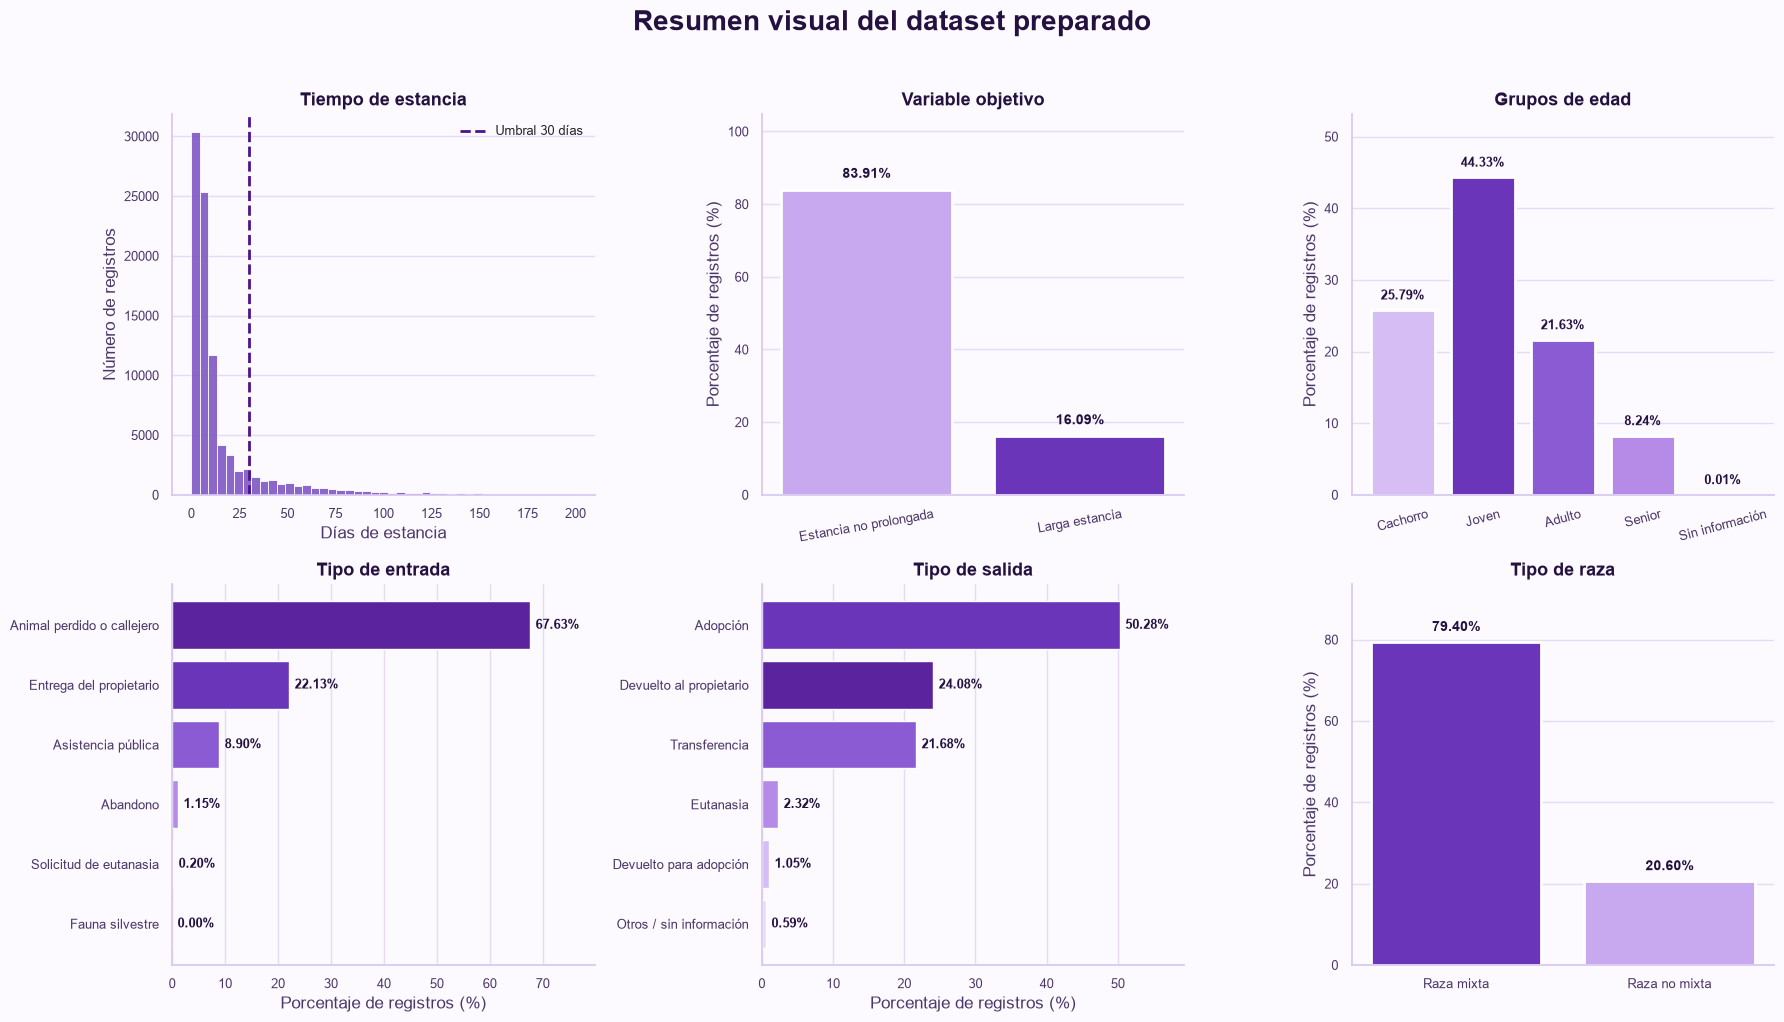

In [84]:
# Panel resumen del dataset preparado

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.patch.set_facecolor("#FCF9FF")

title_color = "#24113F"
text_color = "#4B3768"
grid_color = "#7E57C2"

for ax in axes.flat:
    ax.set_facecolor("#FCF9FF")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D8C8F2")
    ax.spines["bottom"].set_color("#D8C8F2")
    ax.tick_params(axis="x", colors=text_color, labelsize=9)
    ax.tick_params(axis="y", colors=text_color, labelsize=9)

# 1. Distribución del tiempo de estancia
stay_days_plot = dogs_base[dogs_base["stay_days_rounded"] <= 200].copy()

sns.histplot(
    data=stay_days_plot,
    x="stay_days_rounded",
    bins=45,
    color="#7E57C2",
    edgecolor="white",
    alpha=0.9,
    ax=axes[0, 0]
)

axes[0, 0].axvline(
    x=30,
    color="#4A148C",
    linestyle="--",
    linewidth=2,
    label="Umbral 30 días"
)

axes[0, 0].set_title(
    "Tiempo de estancia",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[0, 0].set_xlabel("Días de estancia", color=text_color)
axes[0, 0].set_ylabel("Número de registros", color=text_color)
axes[0, 0].legend(frameon=False, fontsize=9)
axes[0, 0].grid(axis="y", alpha=0.18, color=grid_color)
axes[0, 0].grid(axis="x", visible=False)


# 2. Variable objetivo
target_plot = target_summary.copy()
target_plot = target_plot.sort_values("target_long_stay")

colors_target = ["#C8A9F0", "#6A35B8"]

bars = axes[0, 1].bar(
    target_plot["categoria"],
    target_plot["porcentaje"],
    color=colors_target,
    edgecolor="white",
    linewidth=2
)

axes[0, 1].set_title(
    "Variable objetivo",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Porcentaje de registros (%)", color=text_color)

max_value = target_plot["porcentaje"].max()
axes[0, 1].set_ylim(0, max_value * 1.25)

for bar, value in zip(bars, target_plot["porcentaje"]):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.03,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color=title_color,
        fontweight="bold"
    )

axes[0, 1].tick_params(axis="x", rotation=10)
axes[0, 1].grid(axis="y", alpha=0.18, color=grid_color)
axes[0, 1].grid(axis="x", visible=False)


# 3. Grupos de edad
orden_grupos = ["Cachorro", "Joven", "Adulto", "Senior", "Sin información"]

age_group_plot = age_group_summary.copy()
age_group_plot["grupo_edad"] = pd.Categorical(
    age_group_plot["grupo_edad"],
    categories=orden_grupos,
    ordered=True
)
age_group_plot = age_group_plot.sort_values("grupo_edad")

colors_age = ["#D6BDF4", "#6A35B8", "#8A5BD3", "#B68BE8", "#E8DAFA"]

bars = axes[0, 2].bar(
    age_group_plot["grupo_edad"],
    age_group_plot["porcentaje"],
    color=colors_age[:len(age_group_plot)],
    edgecolor="white",
    linewidth=2
)

axes[0, 2].set_title(
    "Grupos de edad",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Porcentaje de registros (%)", color=text_color)

max_value = age_group_plot["porcentaje"].max()
axes[0, 2].set_ylim(0, max_value * 1.20)

for bar, value in zip(bars, age_group_plot["porcentaje"]):
    axes[0, 2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.025,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color=title_color,
        fontweight="bold"
    )

axes[0, 2].tick_params(axis="x", rotation=15)
axes[0, 2].grid(axis="y", alpha=0.18, color=grid_color)
axes[0, 2].grid(axis="x", visible=False)


# 4. Tipo de entrada
intake_type_plot_resume = intake_type_summary.sort_values("porcentaje", ascending=True)

colors_intake = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#6A35B8", "#5B239D"]

bars = axes[1, 0].barh(
    intake_type_plot_resume["tipo_entrada_es"],
    intake_type_plot_resume["porcentaje"],
    color=colors_intake[:len(intake_type_plot_resume)]
)

axes[1, 0].set_title(
    "Tipo de entrada",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[1, 0].set_xlabel("Porcentaje de registros (%)", color=text_color)
axes[1, 0].set_ylabel("")

max_value = intake_type_plot_resume["porcentaje"].max()
axes[1, 0].set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, intake_type_plot_resume["porcentaje"]):
    axes[1, 0].text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9,
        color=title_color,
        fontweight="bold"
    )

axes[1, 0].grid(axis="x", alpha=0.18, color=grid_color)
axes[1, 0].grid(axis="y", visible=False)


# 5. Tipo de salida
outcome_type_plot_resume = outcome_type_plot.sort_values("porcentaje", ascending=True)

colors_outcome = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#5B239D", "#6A35B8"]

bars = axes[1, 1].barh(
    outcome_type_plot_resume["tipo_salida_agrupada"],
    outcome_type_plot_resume["porcentaje"],
    color=colors_outcome[:len(outcome_type_plot_resume)]
)

axes[1, 1].set_title(
    "Tipo de salida",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[1, 1].set_xlabel("Porcentaje de registros (%)", color=text_color)
axes[1, 1].set_ylabel("")

max_value = outcome_type_plot_resume["porcentaje"].max()
axes[1, 1].set_xlim(0, max_value * 1.18)

for bar, value in zip(bars, outcome_type_plot_resume["porcentaje"]):
    axes[1, 1].text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9,
        color=title_color,
        fontweight="bold"
    )

axes[1, 1].grid(axis="x", alpha=0.18, color=grid_color)
axes[1, 1].grid(axis="y", visible=False)


# 6. Raza mixta vs no mixta
mixed_breed_plot_resume = mixed_breed_summary.sort_values("porcentaje", ascending=False)

colors_mixed = ["#6A35B8", "#C8A9F0"]

bars = axes[1, 2].bar(
    mixed_breed_plot_resume["tipo_raza"],
    mixed_breed_plot_resume["porcentaje"],
    color=colors_mixed,
    edgecolor="white",
    linewidth=2
)

axes[1, 2].set_title(
    "Tipo de raza",
    fontsize=13,
    fontweight="bold",
    color=title_color
)

axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Porcentaje de registros (%)", color=text_color)

max_value = mixed_breed_plot_resume["porcentaje"].max()
axes[1, 2].set_ylim(0, max_value * 1.18)

for bar, value in zip(bars, mixed_breed_plot_resume["porcentaje"]):
    axes[1, 2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_value * 0.025,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color=title_color,
        fontweight="bold"
    )

axes[1, 2].grid(axis="y", alpha=0.18, color=grid_color)
axes[1, 2].grid(axis="x", visible=False)


fig.suptitle(
    "Resumen visual del dataset preparado",
    fontsize=20,
    fontweight="bold",
    color=title_color,
    y=1.02
)

plt.tight_layout()
plt.show()

El panel resumen permite sintetizar los principales resultados del notebook. En primer lugar, se observa que la distribución del tiempo de estancia está concentrada en valores bajos, aunque presenta una cola de estancias más prolongadas. Esta situación justifica la definición de larga estancia a partir del umbral de más de 30 días.

La variable objetivo presenta un desbalance moderado: el 16,09 % de los registros corresponde a perros con larga estancia. Además, el dataset está compuesto mayoritariamente por perros jóvenes y cachorros, con una entrada principalmente asociada a animales perdidos o callejeros.

El análisis también muestra que la adopción es el tipo de salida más frecuente y que la mayoría de perros aparece registrado como raza mixta. En conjunto, estas representaciones resumen los principales patrones identificados y justifican las variables preparadas para la fase posterior de modelización.

## 11. Conclusiones del notebook

En este notebook se ha construido el dataset analítico del proyecto **Invisible Dogs** a partir de los datos públicos de entradas y salidas del Austin Animal Center.

Durante el proceso se han realizado las siguientes tareas principales:

- Carga y revisión inicial de los datasets de entradas y salidas.
- Registro de trazabilidad y snapshot de los datos utilizados para reforzar la reproducibilidad del análisis.
- Filtrado de registros correspondientes a perros.
- Conversión y validación de fechas.
- Emparejamiento cronológico único entre cada entrada y su salida posterior, evitando reutilizar entradas o salidas en más de una estancia.
- Cálculo del tiempo de estancia en el refugio.
- Revisión de valores nulos, inconsistencias temporales y valores extremos.
- Creación de la variable objetivo `target_long_stay`, basada en estancias superiores a 30 días y calculada directamente sobre `stay_days`.
- Transformación de variables predictoras como edad, sexo, estado reproductivo, raza, color, localización y momento de entrada.
- Incorporación de variables de raza/color completas y localización completa para permitir su evaluación en modelos capaces de tratar alta cardinalidad.
- Incorporación de variables históricas del perro, incluyendo entradas previas, duración de estancias anteriores y resultados previos.
- Incorporación de variables de contexto temporal del refugio, como entradas, salidas, adopciones recientes y presión operativa aproximada.
- Creación de interacciones simples entre variables de entrada.
- Inclusión de controles explícitos para comprobar que las variables históricas y de contexto temporal se calculan únicamente con información anterior a la entrada actual.
- Validación del dataset preparado y guardado en formato CSV dentro de `data/processed`.

El resultado final es un dataset preparado y documentado, cuyas dimensiones exactas se muestran en el apartado 10. Este dataset contiene tanto variables predictoras generales como variables específicas para modelos categóricos nativos, manteniendo separadas las columnas que no deben utilizarse como predictoras por contener información posterior a la entrada del animal.

El análisis realizado confirma que el tiempo de estancia presenta una distribución asimétrica, con una mayoría de perros que permanecen pocos días en el refugio y un subconjunto de animales con estancias significativamente más prolongadas. Esta situación justifica la definición de larga estancia a partir del umbral de más de 30 días.

La preparación realizada deja el proyecto listo para entrenar modelos de clasificación, evaluar el equilibrio entre precisión y cobertura, analizar la importancia de variables y construir el **Invisible Dog Score** como herramienta de priorización de perros con mayor riesgo de larga estancia.
